**[Implement analytics solutions using Microsoft Fabric](https://learn.microsoft.com/en-us/training/courses/dp-600t00/)**

# **[Design and manage semantic models in Microsoft Fabric](https://learn.microsoft.com/training/paths/design-manage-semantic-models-fabric/)**

## **Create DAX calculations in semantic models**

### **Introduction**

#### Why Do We Need DAX?
After creating a semantic model, you usually have:

✅ Tables \
✅ Columns \
✅ Relationships

But the model may still be missing:
* Business calculations
* Time intelligence
* Derived fields
* Additional tables
* Analytical logic

This is where **DAX (Data Analysis Expressions)** comes in.

DAX is the calculation language used in:
* Power BI
* Fabric Semantic Models
* Analysis Services

#### Three Types of DAX Calculations
DAX can create:
##### 1. Calculated Tables
Creates an entirely new table.

**Purpose**

Used for:

✅ Date tables \
✅ Role-playing dimensions \
✅ What-if analysis \
✅ Supporting tables

**Example**
```dax
DateTable =
CALENDAR(
    DATE(2024,1,1),
    DATE(2025,12,31)
)
```
Creates a new Date table.
##### 2. Calculated Columns
Adds a new column to an existing table.

**Purpose**

Used for:

✅ Row-level calculations \
✅ Categories \
✅ Labels \
✅ Derived attributes

**Example**
```dax
Full Name =
Customers[FirstName] &
" " &
Customers[LastName]
```
Creates a Full Name column.

**Characteristics**

✅ Calculated once during data refresh \
✅ Stored in the model \
✅ Increases model size
##### 3. Measures (Most Important)
Measures perform aggregations and calculations dynamically.

**Purpose**

Used for:

✅ Totals \
✅ Averages \
✅ Ratios \
✅ KPIs \
✅ Time intelligence

**Example**
```dax
Total Sales =
SUM(Sales[SalesAmount])
```
**Characteristics**

✅ Calculated at query time \
✅ Not physically stored \
✅ Most common DAX object \
✅ Preferred for analytics
##### Why Measures Matter
A column can only return one value per row.

A measure can return different results depending on the report context.

Example:
```dax
Total Sales =
SUM(Sales[SalesAmount])
```
May return:
```
$100,000 by Region
$25,000 by Product
$5,000 by Customer
```
Same measure, different context.
#### Common Business Requirements Solved by DAX
##### Year-To-Date Sales
```dax
Sales YTD =
TOTALYTD(
    [Total Sales],
    Date[Date]
)
```
##### Profit
```dax
Profit =
SUM(Sales[Revenue]) -
SUM(Sales[Cost])
```
##### Profit Margin
```dax
Profit Margin =
DIVIDE(
    [Profit],
    [Total Sales]
)
```
##### Customer Count
```dax
Customer Count =
DISTINCTCOUNT(
    Sales[CustomerID]
)
```
#### When to Use Each DAX Object
| DAX Object        | Use For                    |
| ----------------- | -------------------------- |
| Calculated Table  | Create new tables          |
| Calculated Column | Row-level calculations     |
| Measure           | Aggregations and analytics |

#### Memory Trick
##### Calculated Table
Creates:
> New Table

##### Calculated Column
Creates:
> New Column

##### Measure
Creates:
> New Calculation

#### Storage Impact
| Object            | Stored in Model? |
| ----------------- | ---------------- |
| Calculated Table  | ✅ Yes            |
| Calculated Column | ✅ Yes            |
| Measure           | ❌ No             |

##### Exam Tip
Measures usually have the best efficiency because they do not increase model storage significantly.
#### Typical Semantic Model Design
> Tables → Relationships → Calculated Columns → Measures → Reports → Copilot

#### DAX and AI
Well-designed measures help:

✅ Power BI Copilot \
✅ Fabric AI experiences \
✅ Natural language queries \
✅ Semantic models

Example question:
> Show YTD sales by region.

Copilot can use existing DAX measures to answer accurately.
#### Exam Quick Facts
✅ DAX = Data Analysis Expressions \
✅ Used in:
* Power BI
* Fabric Semantic Models

✅ DAX creates:
* Calculated Tables
* Calculated Columns
* Measures

✅ Calculated Tables create new tables \
✅ Calculated Columns create new columns \
✅ Measures perform aggregations \
✅ Measures are calculated dynamically at query time \
✅ Measures are generally preferred over calculated columns for analytical calculations \
✅ Time intelligence calculations such as YTD commonly use DAX measures
#### Memory Trick
* Table → New Table
* Column → New Column
* Measure → New Insight ⭐

For exams, if asked:
> *Which DAX object is used for summaries, KPIs, totals, and YTD calculations?*

✅ Measure.

### **Create calculated tables**

#### What is a Calculated Table?
A **Calculated Table** is a table created using a DAX formula that returns a table object.

Unlike imported tables:

✅ Created inside the semantic model \
✅ Recalculated during refresh \
✅ Can duplicate or transform existing data \
✅ Useful for modeling scenarios
#### Why Use Calculated Tables?
Common use cases:
##### 1. Role-Playing Dimensions
Example:
> Order Date \
> Ship Date \
> Due Date

all use the same Date table.
##### 2. Date Tables
Required for:

✅ Time Intelligence \
✅ YTD calculations \
✅ MTD calculations \
✅ Fiscal calendar analysis
##### 3. What-If Analysis
Create custom parameter tables for simulation.
##### 4. Supporting Tables
Create lookup or helper tables directly in the model.
#### Duplicate a Table
##### Problem: Multiple Relationships
Example:

**Sales Table**

Contains:
```
OrderDateKey
ShipDateKey
DueDateKey
```
linked to:
```
Date Table
```
**Relationship Limitation**

Only one relationship can be:

✅ Active

Other relationships become:

❌ Inactive
##### Solution: Create a Duplicate Table
Example:
```
Ship Date = 'Date'
```
**What Happens?**

A new table:
```
Ship Date
```
is created with:

✅ Same rows \
✅ Same columns \
✅ Same data

as:
```
Date
```
**Benefit**

You can now create a separate active relationship:
> Sales[`ShipDateKey`] → Ship Date

while retaining:
> Sales[`OrderDateKey`] → Date

#### Role-Playing Dimensions
A duplicated Date table is called a:
##### Role-Playing Dimension
Because one date table serves different roles:
> Order Date \
> Ship Date \
> Due Date

**Exam Tip**

Most common calculated table scenario:

✅ Duplicate Date table \
✅ Create role-playing dimensions
#### Configure Duplicate Tables
The duplicate table does NOT automatically inherit all customizations.

You may need to:
##### Rename Columns
Example:
> Fiscal Year

becomes
> Ship Fiscal Year

##### Configure Sorting
Example:
> Ship Full Date

sorted by:
> Ship Date

##### Hide Supporting Columns
Example:
```
MonthKey
```
used for sorting but hidden from users.
#### Limitation of Duplicate Tables
Calculated tables:

✅ Useful

But:

❌ Increase model size \
❌ Increase refresh duration \
❌ Consume memory
##### Exam Tip
Role-playing dimensions work well but may not be the most performant solution.
#### Create a Date Table
##### Why Date Tables Matter
Required for:

✅ Time Intelligence

Examples:
```dax
TOTALYTD()
DATESYTD()
SAMEPERIODLASTYEAR()
```
#### Using `CALENDARAUTO`
Most common approach.

Example:
```dax
Due Date = CALENDARAUTO(6)
```
##### How It Works
`CALENDARAUTO()` scans:
> All Date Columns \
> All DateTime Columns

in the model.

It automatically finds:
> Earliest Date \
> Latest Date

and generates a complete date range.
##### Fiscal Year Argument
Example:
```dax
CALENDARAUTO(6)
```
means:
> June = Fiscal Year End

Fiscal year:
> July → June

##### Result
Creates:
> One Column

containing every date.

Example:
```
2021-07-01
2021-07-02
...
2022-06-30
```
#### `CALENDAR` Function
Alternative approach.

Example:
```dax
DateTable =
CALENDAR(
    DATE(2020,1,1),
    DATE(2030,12,31)
)
```
##### Difference
| Function     | Behavior                        |
| ------------ | ------------------------------- |
| CALENDARAUTO | Automatically finds date range  |
| CALENDAR     | Explicitly specifies date range |

#### Mark as Date Table
After creating a Date Table:
##### Important Step
> Mark as Date Table

in Power BI.
##### Why Mark It?
Enables:

✅ Time Intelligence Functions \
✅ Correct Date Behavior \
✅ Calendar-Based Calculations
#### Date Table Validation Rules
Power BI checks that:
##### 1. Values Are Unique
* No duplicate dates
##### 2. No Null Values
* Every row must contain a date
##### 3. Dates Are Contiguous
* No gaps

Example:
```
Jan 1
Jan 2
Jan 3
```
not:
```
Jan 1
Jan 3
Jan 5
```
##### 4. Consistent Time Value
For DateTime:
* Same timestamp throughout
#### Date Tables and Time Intelligence
Many DAX functions require a proper Date Table.

Examples:
```dax
TOTALYTD()

DATESMTD()

SAMEPERIODLASTYEAR()
```
Without a valid Date Table:

❌ These calculations may not work correctly.
#### Auto Date/Time vs Date Table
Power BI provides:
##### Auto Date/Time
✅ Easy \
❌ Limited customization \
❌ Hidden tables
##### Custom Date Table
✅ Recommended \
✅ Fully customizable \
✅ Supports fiscal calendars \
✅ Better enterprise solution
#### Calculated Table Summary
| Use Case               | Example                |
| ---------------------- | ---------------------- |
| Duplicate Table        | Ship Date = 'Date'     |
| Role-Playing Dimension | Order Date / Ship Date |
| Date Table             | CALENDARAUTO()         |
| What-If Analysis       | Parameter tables       |
| Helper Tables          | Lookup tables          |

#### Exam Quick Facts
✅ Calculated Tables return tables using DAX \
✅ Created inside the semantic model \
✅ Common role-playing dimension example:
```dax
Ship Date = 'Date'
```
✅ Duplicate tables support multiple active relationships \
✅ Calculated tables increase:
* Model size
* Refresh duration

✅ Date tables are required for time intelligence \
✅ Most common function:
```dax
CALENDARAUTO()
```
✅ Alternative:
```dax
CALENDAR()
```
✅ Date tables should be marked as Date Tables \
✅ Valid date tables require:
* Unique values
* No nulls
* Contiguous dates
* Consistent timestamps
#### Memory Trick
> Calculated Table = New Table

Most common examples:
```dax
Ship Date = 'Date'
```
and
```dax
DateTable = CALENDARAUTO()
```
For exams, if asked:
> *Which DAX object is commonly used to create a Date Table or Role-Playing Dimension?*

✅ Calculated Table. ⭐

### **Create calculated columns**

#### What is a Calculated Column?
A **Calculated Column** is a column added to a table using a DAX formula.

The formula returns **one value for each row** in the table.

Example:
```dax
Full Name =
Customer[First Name]
& " "
& Customer[Last Name]
```
Result:
| First Name | Last Name | Full Name  |
| ---------- | --------- | ---------- |
| John       | Smith     | John Smith |

#### When Should You Use Calculated Columns?
##### Preferred Order
✅ Source System \
✅ Power Query Custom Column \
✅ DAX Calculated Column (only when needed)

Microsoft generally recommends:

**Power Query columns over DAX calculated columns**

because they are:
* More efficient
* More compressed
* Better for model size
#### When to Use Calculated Columns
Use a calculated column when:
##### 1. Working with Calculated Tables
Example:
* Fiscal Year
* Fiscal Quarter
* Month Key

added to a Date table.
##### 2. DAX-Specific Functions Are Required
Examples:
```dax
RELATED()
RELATEDTABLE()
LOOKUPVALUE()
```
These functions aren't available in Power Query.
##### 3. Depends on Model Relationships
If the calculation needs data from related tables.
#### Important Characteristics
Calculated columns:

✅ Evaluated during refresh \
✅ Stored physically in the model \
✅ Increase model size \
✅ Increase refresh time \
❌ Not calculated dynamically
#### Calculated Columns vs Measures
| Feature                       | Calculated Column | Measure                    |
| ----------------------------- | ----------------- | -------------------------- |
| Stored in model               | ✅ Yes             | ❌ No                       |
| Uses row context              | ✅ Yes             | ❌ Typically filter context |
| Increases model size          | ✅ Yes             | ❌ No                       |
| Calculated at refresh         | ✅ Yes             | ❌ Query time               |
| Used for slicers and grouping | ✅ Yes             | ❌ No                       |
##### Exam Tip
If the result is needed for:
> Rows \
> Filters \
> Grouping \
> Slicers

**→ Calculated Column**

If the result is:
> Totals \
> KPIs \
> Aggregations

**→ Measure**
#### Example 1: Fiscal Year
Creates financial year labels.

Fiscal year:
> July → June

##### DAX
```dax
Due Fiscal Year =
"FY"
    & YEAR('Due Date'[Due Date])
        +
        IF(
            MONTH('Due Date'[Due Date]) > 6,
            1
        )
```
##### Example Results
| Date     | Fiscal Year |
| -------- | ----------- |
| Jan 2024 | FY2024      |
| Aug 2024 | FY2025      |

##### Exam Concept
Uses:
```dax
YEAR()
MONTH()
IF()
```
functions.
#### Example 2: Fiscal Quarter
Creates fiscal quarter labels.
##### DAX
```dax
Due Fiscal Quarter =
'Due Date'[Due Fiscal Year]
    & " Q"
    & ...
```
##### Example Results
| Date         | Fiscal Quarter |
| ------------ | -------------- |
| July 2024    | FY2025 Q1      |
| October 2024 | FY2025 Q2      |

##### Purpose
Creates ready-to-use reporting dimensions.
#### Example 3: Month Key
Creates a sorting column.
##### DAX
```dax
MonthKey =
(YEAR('Due Date'[Due Date]) * 100)
    +
MONTH('Due Date'[Due Date])
```
##### Example Results
| Date     | MonthKey |
| -------- | -------- |
| Jan 2024 | 202401   |
| Feb 2024 | 202402   |

##### Purpose
Used for:

✅ Sorting months chronologically

Without it:
> April \
> August \
> December \
> February

might sort alphabetically.
#### Example 4: Full Date Label
Uses `FORMAT`.
##### DAX
```dax
Due Full Date =
FORMAT(
    'Due Date'[Due Date],
    "yyyy mmm, dd"
)
```
##### Example Result
`2024 Jan, 15`
##### `FORMAT` Function
Converts values into text.

Often used for:

✅ Date labels \
✅ Display formatting \
✅ Friendly report names
#### Understanding Row Context
##### Most Important Calculated Column Concept
**What is Row Context?**

Row Context means:
> *DAX evaluates the formula one row at a time.*

Think:
> Current Row

##### Example
```dax
MonthKey =
YEAR('Due Date'[Due Date]) * 100
+
MONTH('Due Date'[Due Date])
```
For each row:
* Read current row date
* Calculate value
* Store result
* Move to next row
##### Exam Definition
✅ Row Context = Current Row
#### Row Context Example
| Date       |
| ---------- |
| 2024-01-15 |
| 2024-02-20 |

Row 1:
> 202401

Row 2:
> 202402

Each row is evaluated individually.
#### Accessing Other Tables
* Row context only applies to the current table.
* To retrieve values from another table:
#### `RELATED()`
Most common exam function.

Used when:

✅ Relationship exists \
✅ Need value from "one" side
##### Example
```dax
RELATED(Product[List Price])
```
##### Memory
```dax
RELATED = Bring one value
```
#### `RELATEDTABLE()`
Returns rows from the many-side.
##### Example
```dax
RELATEDTABLE(Sales)
```
##### Memory
```dax
RELATEDTABLE = Bring a table
```
#### `LOOKUPVALUE()`
Used when:

❌ No relationship exists \
✅ Need to find a matching value
##### Example
```dax
LOOKUPVALUE(...)
```
##### Exam Tip
Prefer:
```dax
RELATED()
```
over:
```dax
LOOKUPVALUE()
```
because it's usually faster.
#### Real Example Using RELATED
##### DAX
```dax
Discount Amount =
(
    Sales[Order Quantity]
        *
        RELATED(Product[List Price])
)
-
Sales[Sales Amount]
```
##### How It Works
For every Sales row:

**Get From Current Sales Row**
* Order Quantity
* Sales Amount

**Get From Product Table**
* List Price

using:
```dax
RELATED()
```
**Calculate**
```
(Expected Price) - (Actual Sales Amount)
```
#### Storage Impact
Remember:

Every calculated column:

✅ Stores values \
✅ Increases memory usage \
✅ Refreshes during dataset refresh

Large models can become significantly larger.
#### Best Practice
Use:

✅ Calculated Columns for categories, labels, sorting columns, relationships

Use:

✅ Measures for totals and aggregations

Avoid creating calculated columns when a measure can solve the problem.
#### Exam Quick Facts

✅ Calculated columns return one value per row \
✅ Evaluated during refresh \
✅ Stored in the model \
✅ Increase model size \
✅ Row Context = Current Row \
✅ Common functions:
* `YEAR()`
* `MONTH()`
* `IF()`
* `FORMAT()`

✅ Relationship functions:
* `RELATED()`
* `RELATEDTABLE()`

✅ No relationship:
* `LOOKUPVALUE()`

✅ `RELATED()` is generally faster than `LOOKUPVALUE()`

✅ Calculated columns are often used for:
* Fiscal Year
* Fiscal Quarter
* Sort Keys
* Display Labels
#### Memory Trick
> Calculated Column = One Value Per Row

and
> Row Context = Current Row ⭐

For exams, if asked:
> *Which DAX concept is automatically available when evaluating a calculated column?*

✅ Row Context.

### **Understand implicit measures**

#### What are Implicit Measures?
An **Implicit Measure** is an automatic aggregation created by Power BI when you drag a numeric column into a visual.

You do **not write DAX** for an implicit measure.

Example:
> Sales Amount Column → Added to Visual → Power BI automatically applies `SUM`

#### Implicit vs Explicit Measures
| Type             | Created By             | DAX Required? |
| ---------------- | ---------------------- | ------------- |
| Implicit Measure | Power BI automatically | ❌ No          |
| Explicit Measure | Model designer         | ✅ Yes         |

##### Examples
**Implicit**
> Sales Amount

Power BI automatically calculates:
```
SUM(Sales Amount)
```
**Explicit**
```dax
Total Sales =
SUM(Sales[Sales Amount])
```
Created manually using DAX.
#### How to Identify Implicit Measures
In the Fields/Data pane:
##### Sigma Symbol (∑)
`∑ Sales Amount`

means:

✅ Numeric column \
✅ Can be automatically summarized
##### No Sigma Symbol
Means:
> Don't Summarize

is configured.

Example:
```
Customer ID
Order Number
```
These shouldn't be aggregated.
#### Summarization Property
As a modeler, you control:
> Summarization

Options include:

✅ Sum \
✅ Average \
✅ Min \
✅ Max \
✅ Don't Summarize
#### Example: Sales Amount
Column:
> Sales Amount

Default behavior:
```
SUM(Sales Amount)
```
When placed into a visual.
##### Example
| Month | Sales |
| ----- | ----- |
| Jan   | 100   |
| Feb   | 200   |

Visual shows:
> Total = 300

because Power BI automatically applies:
```
SUM()
```
#### Example: Unit Price
Unit Price is a:
> Rate

not a total.

Power BI therefore commonly defaults to:
```
AVERAGE()
```
instead of:
```
SUM()
```
##### Why?
Adding prices together is usually meaningless.

Example:
```
10
20
30
```
Average:
> 20 ✅

Sum:
> 60 ❌

#### Aggregations Available for Numeric Columns
Numeric fields support the largest number of aggregation options.
##### `SUM`
Total Sales
##### `AVERAGE`
Average Price
##### `MIN`
Lowest Sale
##### `MAX`
Highest Sale
##### `COUNT`
Number of Rows
##### `DISTINCT COUNT`
Unique Customers
##### `MEDIAN`
Middle value.
##### `STANDARD DEVIATION`
Measures variation.
##### `VARIANCE`
Measures spread of data.
#### Non-Numeric Columns Can Also Be Summarized
Many learners think only numbers can be aggregated.

That's incorrect.
##### Text Columns
Examples:
> Product Name \
> Customer Name

Available aggregations:

✅ First \
✅ Last \
✅ Count \
✅ Distinct Count 

**Example**

Question:
> How many unique products exist?

Use:
```
Distinct Count(Product Name)
```
##### Date Columns
Examples:
> Order Date \
> Ship Date

Available aggregations:

✅ Earliest \
✅ Latest \
✅ Count \
✅ Distinct Count

**Example**

Question:
> What is the earliest order date?

Use:
```
Earliest(Order Date)
```
##### Boolean Columns
Examples:
> Complete \
> Approved \
> Active

Can also be counted.

Example:
> How many orders were completed?

Use:
```
Count()
```
#### Why Implicit Measures Are Useful
##### Benefit 1: Easy to Use
No DAX required.

Simply:
> Drag Column → Get Result

##### Benefit 2: Fast Report Creation
Report authors don't need:
```
SUM()
AVG()
COUNT()
```
measures created beforehand.
##### Benefit 3: Less Work for Modelers
No need to create:
> Total Sales \
> Total Profit \
> Total Quantity

for every basic metric.
#### Limitations of Implicit Measures
##### Report Authors Can Change Aggregations
Example:
> Unit Price

should use:
> Average

but a user can choose:
> Sum

Result:
> Potentially misleading analysis

#### Only Simple Calculations Supported
Implicit measures can only perform:

✅ One aggregation function

Examples:
```
SUM
AVG
MIN
MAX
```
They cannot perform:

❌ Ratios \
❌ YTD calculations \
❌ Running totals \
❌ Profit margins \
❌ Complex time intelligence
#### Example of a Calculation Requiring an Explicit Measure
Question:
> What percentage of annual sales does each month represent?

Requires:
```dax
Monthly % of Year =
DIVIDE(
    [Monthly Sales],
    [Yearly Sales]
)
```
Implicit measures cannot do this.
#### When to Use Implicit Measures
✅ Quick reports \
✅ Basic totals \
✅ Simple analysis \
✅ Ad hoc reporting
#### When to Use Explicit Measures
✅ Business KPIs \
✅ Financial metrics \
✅ Ratios \
✅ YTD calculations \
✅ Time intelligence \
✅ Reusable calculations
#### Implicit vs Explicit Measures
| Feature                 | Implicit Measure | Explicit Measure |
| ----------------------- | ---------------- | ---------------- |
| DAX Required            | ❌ No             | ✅ Yes            |
| Easy to Use             | ✅ Yes            | ⚠ Requires DAX   |
| Simple Aggregations     | ✅ Yes            | ✅ Yes            |
| Time Intelligence       | ❌ No             | ✅ Yes            |
| Ratios                  | ❌ No             | ✅ Yes            |
| KPIs                    | ❌ No             | ✅ Yes            |
| Reusable Business Logic | ❌ No             | ✅ Yes            |

#### Exam Quick Facts
✅ Implicit measures are automatically created by Power BI \
✅ Numeric columns with `∑` can be summarized \
✅ Common implicit aggregations:
* Sum
* Average
* Min
* Max
* Count
* Distinct Count
* Median
* Standard Deviation
* Variance

✅ Non-numeric fields can also be aggregated \
✅ Summarization behavior is controlled by the Summarization property \
✅ Implicit measures require no DAX \
✅ Implicit measures are limited to simple aggregations \
✅ Complex calculations require explicit measures
#### Memory Trick
**Implicit = Automatic**
> Drag Column → Power BI Aggregates

**Explicit = DAX Written by You**

For exams:
> *If a calculation requires ratios, YTD totals, running totals, or KPIs...*

✅ Use an Explicit Measure, not an implicit one. ⭐

### **Create explicit measures**

#### What is an Explicit Measure?
An **Explicit Measure** is a DAX calculation that you create manually.

Unlike implicit measures:

✅ Written using DAX \
✅ Calculated at query time \
✅ Not stored in the model \
✅ More powerful and flexible
#### Implicit vs Explicit Measures
##### Implicit Measure
Created automatically.

Example:
> Sales Amount

Power BI automatically applies:
```
SUM(Sales Amount)
```
##### Explicit Measure
Created manually using DAX.

Example:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
#### Key Characteristics of Measures
Measures:

✅ Return a single value \
✅ Do not store data \
✅ Use filter context \
✅ Calculated dynamically \
✅ Consume very little model storage

##### Exam Tip
Measures are evaluated:
> At Query Time

NOT during refresh.
#### Creating a Simple Measure
##### Revenue Measure
```dax
Revenue =
SUM(Sales[Sales Amount])
```
##### Purpose
Aggregates:
> Sales Amount

into:
> Total Revenue

**Result**

Depending on report filters:
* Revenue by Year
* Revenue by Product
* Revenue by Customer

The same measure returns different values.
#### Measure Best Practice
Instead of exposing raw columns:
> Sales Amount \
> Profit Amount

Create measures:
> Revenue \
> Profit

and hide unnecessary columns.

Benefits:

✅ Easier report creation \
✅ Consistent business logic \
✅ Better governance
#### Formatting Measures
After creation:

Configure:

✅ Data Type \
✅ Currency Format \
✅ Percentage Format \
✅ Decimal Places \
✅ Home Table
##### Home Table
The table where the measure appears in the Fields pane.

Example:
```
Sales Table
```
contains:
```
Revenue
Profit
Margin
```
#### `COUNT` Measures
##### `COUNT()`
Counts non-blank values.

Example:
```dax
Order Line Count =
COUNT(
    Sales[SalesOrderLineKey]
)
```
**Result**

Counts every sales line.
##### `DISTINCTCOUNT()`
Counts unique values.

Example:
```dax
Order Count =
DISTINCTCOUNT(
    Sales[Sales Order]
)
```
Why Use It?

One order may have:
```
Line 1
Line 2
Line 3
```
`COUNT`:
```
3
```
`DISTINCTCOUNT`:
```
1
```
Correct order count.
##### COUNT vs DISTINCTCOUNT
| Function      | Counts        |
| ------------- | ------------- |
| COUNT         | All values    |
| DISTINCTCOUNT | Unique values |

##### Exam Question
Customer purchased:
```
100
100
101
101
102
```
`COUNT`:
```
5
```
`DISTINCTCOUNT`:
```
3
```
##### `COUNTROWS()`
Counts table rows.

Example:
```dax
Order Line Count =
COUNTROWS(Sales)
```
**Difference**
```dax
COUNT(Column)
```
Counts values in a column.
```dax
COUNTROWS(Table)
```
Counts rows in a table.
#### Simple Measures
Simple measures summarize:

✅ One column \
✅ One table

Examples:
```dax
SUM()
COUNT()
DISTINCTCOUNT()
COUNTROWS()
AVG()
```
##### Compound Measures
Most important exam concept.
##### What is a Compound Measure?
A measure built using other measures.

Example
```dax
Revenue =
SUM(Sales[Sales Amount])
```
```dax
Cost =
SUM(Sales[Cost Amount])
```
```dax
Profit =
[Revenue] - [Cost]
```
##### Why Is This Better?
Instead of creating:
> Profit Amount Column

for every row,

you create:
> Profit Measure

which:

✅ Uses less memory \
✅ Refreshes faster \
✅ Keeps model smaller
#### Calculated Column vs Measure
Bad approach:
```dax
Profit Amount Column =
Revenue - Cost
```
Stored for every row.

Better approach:
```dax
Profit =
[Revenue] - [Cost]
```
Calculated only when needed.
##### Exam Tip
Whenever possible:

✅ Use measures instead of calculated columns.
#### Measure Dependency
Measures can reference:

✅ Columns \
✅ Other Measures
##### Example
```dax
Profit =
[Revenue]
-
[Cost]
```
##### Dependency Chain
> Revenue → Profit → Profit Margin

Be cautious:
> Changing one measure can affect many others.

#### Quick Measures
##### What Are Quick Measures?
* Power BI generates DAX automatically.
* No manual coding required.

##### Example
Profit Margin

Steps:
> New Quick Measure → Division → Profit / Revenue

Generated DAX:
```dax
Profit Margin =
DIVIDE(
    [Profit],
    [Revenue]
)
```
#### `DIVIDE` Function
Preferred over:
> Profit / Revenue

because:

✅ Handles divide-by-zero safely

Example:
```dax
DIVIDE(
    [Profit],
    [Revenue]
)
```
#### Common Measure Functions
##### `SUM`
```dax
SUM(Sales[Sales Amount])
```
##### `COUNT`
```dax
COUNT(Sales[OrderID])
```
##### `COUNTROWS`
```dax
COUNTROWS(Sales)
```
##### `DISTINCTCOUNT`
```dax
DISTINCTCOUNT(Customer[CustomerID])
```
##### `DIVIDE`
```dax
DIVIDE([Profit],[Revenue])
```
#### Calculated Columns vs Measures
| Feature             | Calculated Column  | Measure            |
| ------------------- | ------------------ | ------------------ |
| Stored in model     | ✅ Yes              | ❌ No               |
| Uses row context    | ✅ Yes              | ❌ Typically        |
| Uses filter context | ❌ Not primarily    | ✅ Yes              |
| Refresh time impact | ✅ Higher           | ✅ Lower            |
| Model size impact   | ✅ Increases        | ❌ Minimal          |
| Good for            | Categories, labels | Aggregations, KPIs |

#### Exam Rule
##### Use Calculated Column When
Need:
* Fiscal Year
* Category
* Sort Column
* Grouping Field
##### Use Measure When
Need:
* Revenue
* Profit
* Margin
* YTD
* KPIs
* Ratios
#### Filter Context
Measures evaluate using:
##### Filter Context
Example:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
Visual:
```
Year = 2024
```
Result:
```
Revenue for 2024
```
Change filter:
```
Year = 2025
```
Measure recalculates automatically.
#### Exam Memory
* Calculated Column → Row Context
* Measure → Filter Context
#### Best Practices
✅ Create explicit measures for business metrics \
✅ Format measures immediately \
✅ Use compound measures \
✅ Prefer measures over calculated columns \
✅ Use `DIVIDE` instead of `/` \
✅ Hide raw columns if measures are available
#### Exam Quick Facts
✅ Explicit measures use DAX \
✅ Return a scalar value \
✅ Evaluated at query time \
✅ Not stored in the model \
✅ Use filter context \
✅ Simple measures aggregate one column \
✅ Compound measures reference other measures \
✅ Common functions:
* `SUM`
* `COUNT`
* `DISTINCTCOUNT`
* `COUNTROWS`
* `DIVIDE`

✅ Quick Measures automatically generate DAX \
✅ Measures are generally more efficient than calculated columns
#### Memory Trick
**Measure = Dynamic Calculation**
> Calculated Column → Stored \
> Measure → Calculated

And remember:
* Row Context = Calculated Columns
* Filter Context = Measures ⭐

This is one of the most frequently tested Power BI/DAX exam concepts.

### **Use iterator functions**

#### What are Iterator Functions?
**Iterator functions** evaluate an expression row by row over a table and then aggregate the results.

They provide more flexibility than simple aggregation functions.

Think:
> For each row → Calculate expression → Aggregate results

#### X Functions = Iterator Functions
Most aggregation functions have an iterator equivalent ending in X.

| Standard Function | Iterator Function |
| ----------------- | ----------------- |
| SUM               | SUMX              |
| COUNT             | COUNTX            |
| MIN               | MINX              |
| MAX               | MAXX              |
| AVERAGE           | AVERAGEX          |
| RANK              | RANKX             |

#### Syntax Pattern
All iterator functions require:
```dax
FunctionX(
    Table,
    Expression
)
```
##### Components
Table
> Rows to iterate over

##### Expression
> Calculation performed for each row

#### `SUM` vs `SUMX`
##### `SUM`
```dax
Revenue =
SUM(Sales[Sales Amount])
```
Simply sums one column.
##### `SUMX`
```dax
Revenue =
SUMX(
    Sales,
    Sales[Sales Amount]
)
```
Returns exactly the same result.
##### Exam Fact
Power BI internally treats:
```dax
SUM()
```
as a simplified version of:
```dax
SUMX()
```
#### Why Use Iterator Functions?
Use iterator functions when calculations involve:

✅ Multiple columns \
✅ Related tables \
✅ Complex row-level logic \
✅ Custom aggregation grain
#### Example: Revenue Calculation
Suppose revenue must consider:
> Quantity \
> Price \
> Discount

##### DAX
```dax
Revenue =
SUMX(
    Sales,
    Sales[Order Quantity]
        * Sales[Unit Price]
        * (1 - Sales[Unit Price Discount Pct])
)
```
##### What Happens?
For each row:
> Quantity × Price × Discount

Then:
> All rows summed together

#### Using `RELATED` with Iterators
Iterator functions can access columns from related tables.
##### Example
```dax
Discount =
SUMX(
    Sales,
    Sales[Order Quantity]
        *
        (
            RELATED(Product[List Price])
            -
            Sales[Unit Price]
        )
)
```
##### Purpose
For every sales row:
* Get Product List Price
* Compare To Actual Price
* Calculate Discount

Then total all discounts.
##### Performance Tip
Prefer:
```dax
RELATED()
```
instead of:
```dax
LOOKUPVALUE()
```
because RELATED is generally faster.
##### Expensive Functions
Be cautious with:
```dax
SEARCH()
LOOKUPVALUE()
```
especially on large tables.
#### Iterator Functions and Row Context
Iterator functions automatically create:
##### Row Context
Meaning:
> Current Row

is available during evaluation.

Example:
```dax
SUMX(Sales, Sales[Quantity] * Sales[Price])
```
For each row:
* Current Quantity
* Current Price

are evaluated.
#### Iterator Functions and Filter Context
First:
> Filter Context Applied

Then:
> Iterator Processes Remaining Rows

Example:
> Visual filtered to FY2024

Iterator only processes FY2024 sales rows.
#### `AVERAGEX`
Average Per Order Line
##### Example
```dax
Revenue Avg Order Line =
AVERAGEX(
    Sales,
    Sales[Order Quantity]
        * Sales[Unit Price]
        * (1 - Sales[Unit Price Discount Pct])
)
```
##### Result
Calculates:
* Average Revenue
* Per Line Item
#### Higher Grain Calculations
Iterator functions can summarize at different levels.
#### Average Revenue Per Order
One order may contain:
```
Line 1
Line 2
Line 3
```
Instead of averaging line items:
> Average complete orders.

##### Example
```dax
Revenue Avg Order =
AVERAGEX(
    VALUES('Sales Order'[Sales Order]),
    [Revenue]
)
```
#### `VALUES` Function
##### Purpose
Returns unique values.

Example:
```dax
VALUES(
    'Sales Order'[Sales Order]
)
```
returns:
```
Order 100
Order 101
Order 102
```
without duplicates.
##### Exam Fact
VALUES is commonly used with:
```dax
AVERAGEX
SUMX
RANKX
```
to change aggregation grain.
#### Ranking with `RANKX`
One of the most important iterator functions.
##### Example
```dax
Product Quantity Rank =
RANKX(
    ALL('Product'[Product]),
    [Quantity]
)
```
##### Purpose
Ranks products by quantity sold.
#### `ALL` Function
```dax
ALL(Product[Product])
```
removes filters.

This allows ranking against:
> All Products

instead of only filtered products.
#### Default Ranking Behavior
`RANKX` defaults to:

✅ Descending Order \
✅ Ties Skip Numbers
##### Example
```
1
2
2
4
```
`Rank 3` is skipped.
#### Dense Ranking
Use:
```dax
DENSE
```
argument.
##### Example
```dax
Product Quantity Rank =
RANKX(
    ALL('Product'[Product]),
    [Quantity],
    ,
    ,
    DENSE
)
```
##### Result
Ranks become:
```
1
2
2
3
```
No skipped numbers.
#### Prevent Ranking Totals
Totals often produce:
> Rank = 1

which isn't meaningful.
#### `HASONEVALUE`
Use:
```dax
HASONEVALUE()
```
to suppress totals.
##### Example
```dax
Product Quantity Rank =
IF(
    HASONEVALUE(
        'Product'[Product]
    ),
    RANKX(
        ALL('Product'[Product]),
        [Quantity],
        ,
        ,
        DENSE
    )
)
```
##### What Happens?
**Product Row**
> Single Product

Result:
> Show Rank

**Total Row**
> Many Products

Result:
> BLANK

#### Most Common Iterator Functions
| Function   | Purpose                  |
| ---------- | ------------------------ |
| `SUMX`     | Custom summation         |
| `AVERAGEX` | Custom averaging         |
| `COUNTX`   | Count expression results |
| `MINX`     | Minimum expression value |
| `MAXX`     | Maximum expression value |
| `RANKX`    | Ranking                  |

#### When to Use Iterators
Use iterator functions when:

✅ Multiple columns are involved \
✅ Need row-by-row calculations \
✅ Need custom aggregation logic \
✅ Need rankings \
✅ Need different aggregation grain
#### Iterator vs Regular Aggregation
##### Regular Aggregation
```dax
SUM(Sales[Amount])
```
One column only.
##### Iterator
```dax
SUMX(
    Sales,
    Sales[Qty]
        * Sales[Price]
)
```
* Multiple columns.
* Much more flexible.
#### Exam Quick Facts
✅ Iterator functions end with X

Examples:
```
SUMX
AVERAGEX
COUNTX
MINX
MAXX
RANKX
```
✅ Require:
> Table + Expression

✅ Create row context automatically \
✅ Evaluate rows one at a time \
✅ Can reference multiple columns \
✅ Can use `RELATED()` \
✅ `VALUES()` returns unique values \
✅ `RANKX()` performs ranking \
✅ `ALL()` removes filters \
✅ `HASONEVALUE()` often hides total-row rankings \
✅ DENSE ranking does not skip numbers
#### Memory Trick
**X = eXamine Every Row**
> SUM   → One Column \
> SUMX  → Row-by-Row Calculation

And remember the four most tested iterator functions:

✅ SUMX → Custom Totals \
✅ AVERAGEX → Custom Averages \
✅ RANKX → Ranking \
✅ VALUES + Iterator → Change Aggregation Grain ⭐

### **Exercise - Create DAX calculations**

#### Get started
To complete this exercise, first open a web browser and enter the following URL to download the zip file:

https://github.com/MicrosoftLearning/PL-300-Microsoft-Power-BI-Data-Analyst/raw/Main/Allfiles/Labs/04-create-dax-calculations\04-dax-calculations.zip

Extract the file to the **C:\Users\Student\Downloads\04-dax-calculations** folder.

Open the **04-Starter-Sales Analysis.pbix** file.
> Note: You may see a sign-in dialog as the file loads. Select Cancel to dismiss the sign-in dialog. Close any other informational windows. Select Apply Later, if prompted to apply changes.

#### Create the Salesperson calculated table
In this task, you’ll create the `Salesperson` calculated table (that will have a direct relationship to the `Sales` table).

A calculated table is created by first entering the table name, followed by the equals symbol (=), followed by a DAX formula that returns a table. The table name can’t already exist in the data model.

You enter a valid DAX formula in the formula bar. The formula bar includes features like auto-complete, Intellisense and color-coding, which allow you to quickly and accurately enter the formula.
1. In Power BI Desktop, in **Report view**, on the **Modeling** ribbon, from inside the **Calculations** group, select **New Table**.

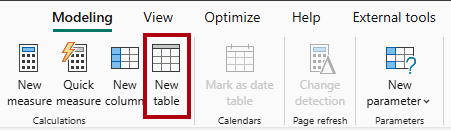

2. In the formula bar (which opens directly beneath the ribbon when you create or edit calculations), type `Salesperson =`, press **Shift+Enter**, type `'Salesperson (Performance)'`, and then press **Enter**.
> Note: For your convenience, all DAX definitions in this lab can be copied from the snippets file, located in the *04-dax-calculations\Snippets.txt* file.

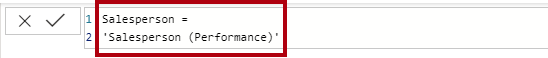

> This table definition creates a copy of the `Salesperson (Performance)` table. It copies the data only, however model properties like visibility, formatting, and others aren’t copied.

3. In the **Data** pane, notice that the icon for the new table has an additional calculator in front of it (denoting a calculated table).

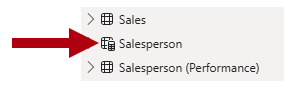

> Note: Calculated tables are defined by using a DAX formula that returns a table. It’s important to understand that calculated tables increase the size of the data model because they materialize and store values. Also, they’re recomputed whenever formula dependencies are refreshed, as will be the case for this data model when new (future) date values are loaded into tables.

> Unlike Power Query-sourced tables, calculated tables can’t be used to load data from external data sources. They can only transform data based on what has already been loaded into the data model.

4. Switch to **Model view**, and notice that the `Salesperson` table is available.
5. Create a relationship from the `Salesperson | EmployeeKey` column to the `Sales | EmployeeKey` column.
> The labs use a shorthand notation to reference a field. It will look like this: `Salesperson | EmployeeKey`. In this example, `Salesperson` is the table name and `EmployeeKey` is the column name.

6. Right-click the inactive relationship (dotted line) between the `Salesperson (Performance)` and `Sales` tables, and then select **Delete**. When prompted to confirm the deletion, select **Yes**.
7. In the `Salesperson` table, multi-select the following columns, and then hide them (set the **Is Hidden** property to **Yes**):
    * `EmployeeID`
    * `EmployeeKey`
    * `UPN`
8. In the model diagram, select the `Salesperson` table.
9. In the **Properties** pane, in the **Description** box, enter: *Salesperson* related to sales
> You may recall that descriptions appear as tooltips in the Data pane whenever the user hovers their cursor over a table or field.

10. For the `Salesperson (Performance)` table, set the description to: *Salesperson related to region(s)*
> The data model now provides two alternatives when analyzing salespeople. The `Salesperson` table allows analyzing sales made by a salesperson, while the `Salesperson (Performance)` table allows analyzing sales made in the sales region(s) assigned to the salesperson.

#### Create the Date table
In this task, you’ll create the `Date` table.
1. Switch to **Table view**. On the **Home** ribbon tab, from inside the **Calculations** group, select **New Table**.

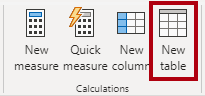

2. In the formula bar, enter the following DAX:

```dax
Date =  
CALENDARAUTO(6)
```
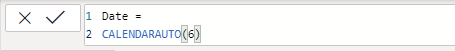

> The `CALENDARAUTO` function returns a single-column table comprising date values. The “auto” behavior scans all data model date columns to determine the earliest and latest date values stored in the data model. It then creates one row for each date within this range, extending the range in either direction to ensure full years of data is stored.

> This function can take a single optional argument that is the last month number of a year. When omitted, the value is 12, meaning that December is the last month of the year. In this case, 6 is entered, meaning that June is the last month of the year.

3. Notice the column of date values which might be formatted using US regional settings (that is, mm/dd/yyyy).

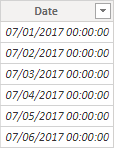

4. At the bottom-left corner, in the status bar, notice the table statistics, confirming that 1826 rows of data have been generated, which represents five full years’ data.



#### Create calculated columns
In this task, you’ll add more columns to enable filtering and grouping by different time periods. You’ll also create a calculated column to control the sort order of other columns.
> Note: For your convenience, all DAX definitions in this lab can be copied from the Snippets.txt file.

1. On the **Table Tools** contextual ribbon, from inside the **Calculations** group, select **New Column**.
> A calculated column is created by first entering the column name, followed by the equals symbol (=), followed by a DAX formula that returns a single-value result. The column name can’t already exist in the table.

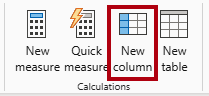

2. In the formula bar, type the following (or copy from the snippets file), and then press **Enter**:
> The formula uses the date’s year value but adds one to the year value when the month is after June. That’s how fiscal years at Adventure Works are calculated.

```dax
Year =
"FY" & YEAR('Date'[Date]) + IF(MONTH('Date'[Date]) > 6, 1)
```
3. Use the snippets file definitions to create the following two calculated columns for the `Date` table:
    * `Quarter`
    * `Month`
4. Verify the new columns have been added.

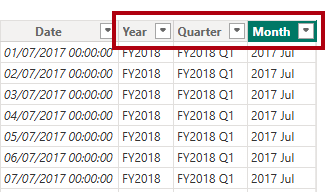

5. To validate the calculations, switch to **Report view**.
6. To create a new report page, select the plus icon next to **Page 1**.

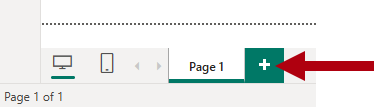

7. To add a matrix visual to the new report page, in the Visualizations pane, select the matrix visual type.
> Tip: You can hover the cursor over each icon to reveal a tooltip describing the visual type.

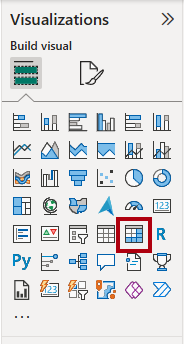

8. In the **Data** pane, from inside the `Date` table, drag the `Year` field into the **Rows** well.

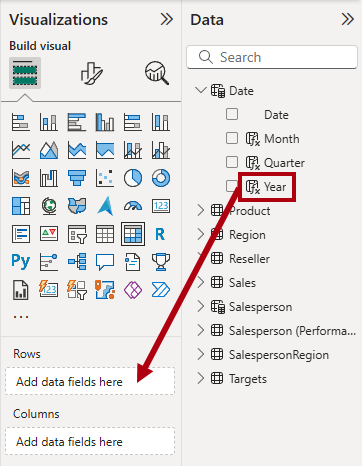

9. Drag the `Month` field into the **Rows** well, directly beneath the `Year` field.
10. At the top-right of the matrix visual (or bottom, depending on the location of the visual), select the forked-double arrow icon (which will expand all years down one level).

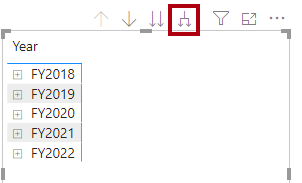

11. Notice that the years expand to months, and that the months are sorted alphabetically rather than chronologically.

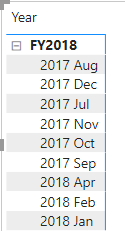

> By default, text values sort alphabetically, numbers sort from smallest to largest, and dates sort from earliest to latest.

12. To customize the `Month` field sort order, switch to **Table view**.
13. Add the `MonthKey` column to the `Date` table.

```dax
MonthKey =
(YEAR('Date'[Date]) * 100) + MONTH('Date'[Date])
```
> This formula computes a numeric value for each year/month combination.

14. In **Table view**, verify that the new column contains numeric values (for example, 201707 for July 2017, and so on).

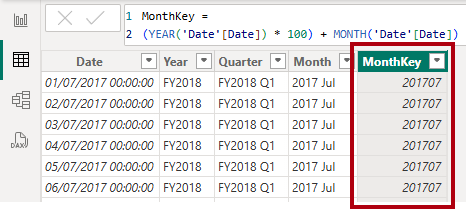

15. Switch back to **Report view**.
16. In the **Data** pane, select the `Month` field.
17. On the **Column Tools** contextual ribbon, from inside the **Sort** group, select **Sort by Column**, and then select **MonthKey**.

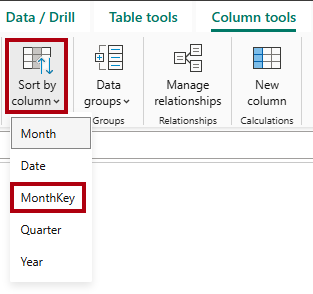

18. In the matrix visual, notice that the months are now chronologically sorted.

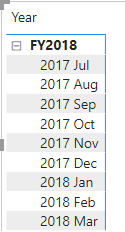

#### Complete the Date table
In this task, you’ll complete the design of the `Date` table by hiding a column and creating a hierarchy. You’ll then create relationships to the `Sales` and `Targets` tables.
1. Switch to **Model view**.
2. In the `Date` table, hide the `MonthKey` column (set **Is Hidden** to *Yes*).
3. In the **Data** pane, select the `Date` table, right-click the `Year` column, and the select **Create hierarchy**.

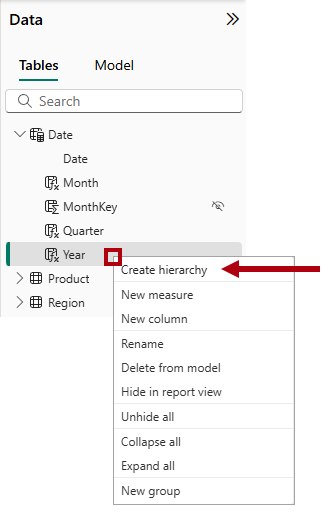

4. In the **Properties** pane, in the **Name** box, replace the value with *Fiscal*.

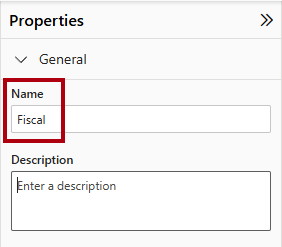

5. Two add levels to the hierarchy, in the **Hierarchy** dropdown list, select **Quarter** and then select **Month**, and then select **Apply Level Changes**.

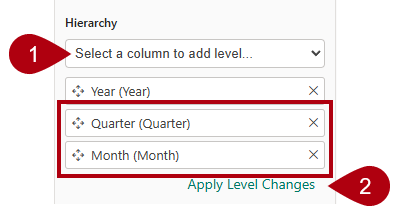

6. Create the following two model relationships:
    * `Date | Date` to `Sales | OrderDate`
    * `Date | Date` to `Targets | TargetMonth`
7. Hide the following two columns:
    * `Sales | OrderDate`
    * `Targets | TargetMonth`
#### Mark the Date table
In this task, you’ll mark the `Date` table as a date table.
1. Switch to **Report view**.
2. In the **Data** pane, select the `Date` table (not the `Date` field).
3. On the **Table Tools** contextual ribbon, from inside the **Calendars** group, select **Mark as Date Table**.

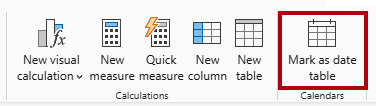

4. In the **Mark as a Date Table** window, slide the **Mark as a Date Table** property to *On*.
5. In the **Choose a date column** dropdown list, select **Date**.

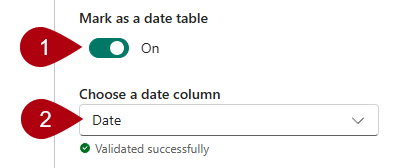

6. Select **Save**.
7. Save the Power BI Desktop file.
> Power BI Desktop now understands that this table defines date (time).

>This design approach for a date table is suitable when you don’t have a date table in your data source. If you have a data warehouse, it would be appropriate to load date data from its date dimension table rather than “redefining” date logic in your data model.

#### Create simple measures
In this task, you’ll create simple measures. Simple measures aggregate values in a single column or count rows of a table.
1. In **Report view**, on **Page 2**, from the **Data** pane, drag the `Sales | Unit Price` field into the matrix visual.

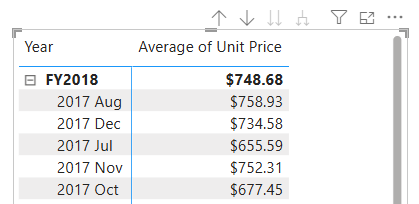

2. In the visual fields pane (located in the **Visualizations** pane), in the **Values** well, notice that `Unit Price` field is configured as **Average of Unit Price**.

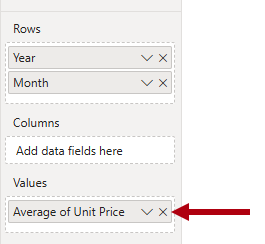

3. Select the down-arrow for **Average of Unit Price**, and then notice the available menu options.
> Visible numeric columns allow report authors at report design time to decide how column values will summarize (or not). However, it can result in inappropriate reporting.

> Some data modelers don’t like leaving things to chance, so they choose to hide these columns and instead expose aggregation logic defined in measures. It’s the approach you’ll now take in this lab.

4. To create a measure, in the **Data** pane, right-click the `Sales` table, and then select **New Measure**.
5. In the formula bar, add the following measure definition:

```dax
Avg Price =  
AVERAGE(Sales[Unit Price])
```
6. Add the `Avg Price` measure to the matrix visual, and notice that it produces the same result as the `Unit Price` column (but with different formatting).
7. In the **Values** well, open the context menu for the `Avg Price` field, and notice that it isn’t possible to change the aggregation technique.

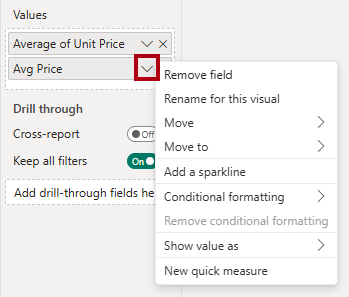

> It’s not possible to modify the aggregation behavior of a measure.

8. Use the snippets file definitions to create the following five measures for the `Sales` table:
    * `Median Price`
    * `Min Price`
    * `Max Price`
    * `Orders`
    * `Order Lines`

> The `DISTINCTCOUNT` function used in the `Orders` measure counts orders only once (ignoring duplicates). The `COUNTROWS` function used in the Order` Lines` measure operates over a table.

> In this case, the number of orders is calculated by counting the distinct `SalesOrderNumber` column values, while the number of order lines is simply the number of table rows (each row is a line of an order).

9. Switch to **Model view**, and then multi-select the four price measures: `Avg Price`, `Max Price`, `Median Price`, and `Min Price`.
10. For the multi-selection of measures, configure the following requirements:
    * Set the format to two decimal places.
    * Assign to a display folder named *Pricing* (use the **Display folder** property in the **Properties** pane).

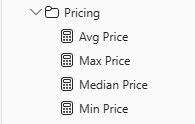

11. Hide the `Unit Price` column.
> The `Unit Price` column is no longer available to report authors. They must use the pricing measures you’ve added to the model. This design approach ensures that report authors won’t inappropriately aggregate prices, for example, by summing them.

12. Multi-select the `Order Lines` and `Orders` measures, and then configure the following requirements:
    * Set the format use the thousands separator.
    * Assign to a display folder named Counts.

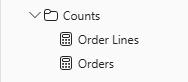

13. In **Report view**, in the **Values** well of the matrix visual, for **Average of Unit Price**, select **X** to remove it.

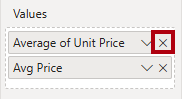

14. Increase the size of the matrix visual to fill the page width and height.
15. Add the following five measures to the matrix visual:
    * `Median Price`
    * `Min Price`
    * `Max Price`
    * `Orders`
    * `Order Lines`
16. Verify that the results look sensible and are correctly formatted.

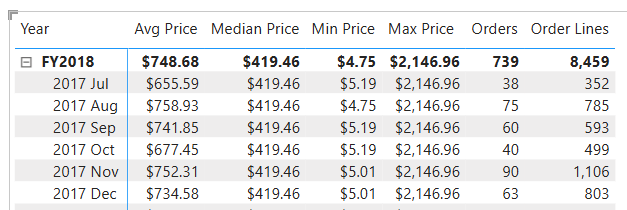

#### Create additional measures
In this task, you’ll create more measures that use more complex formulas.
1. In **Report view**, select **Page 1** and review the table visual of salespeople (on the right), noticing the total for the **Sum of Target** column.

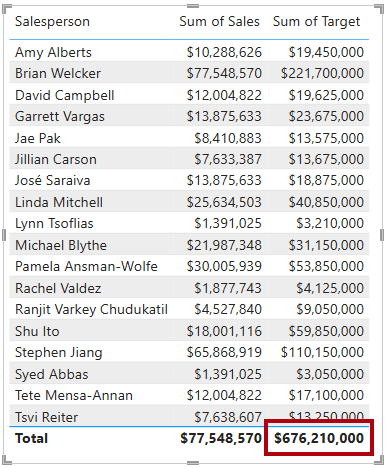

2. Select the table visual, and then in the **Visualizations** pane, remove **Sum of Target**.
3. Rename the `Targets | Target` column as *TargetAmount*.
> Tip: There are several ways to rename the column in Report view: In the Data pane, you can right-click the column, and then select Rename—or, double-click the column, or press F2.

4. Create the following measure on the `Targets` table:

```dax
Target =
IF(
    HASONEVALUE('Salesperson (Performance)'[Salesperson]),
    SUM(Targets[TargetAmount])
)
```
> The `HASONEVALUE` function tests whether a single value in the `Salesperson` column is filtered. When true, the expression returns the sum of target amounts (for just that salesperson). When false, `BLANK` is returned.

5. Format the `Target` measure for zero decimal places.
> Tip: You can use the Measure Tools contextual ribbon.

6. Hide the `TargetAmount` column.
> Tip: You can right-click the column in the Data pane, and then select Hide.

7. Notice that the `Targets` table now appears at the top of the list.

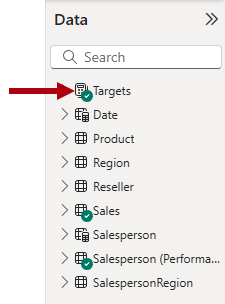

> Tables that comprise only visible measures are automatically listed at the top of the list.

8. Add the `Target` measure to the table visual.
9. Notice that the **Target** column total is now `BLANK`.

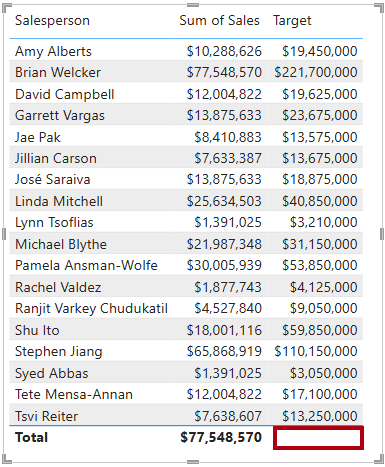

10. Use the snippets file definitions to create the following two measures for the `Targets` table:
    * `Variance`
    * `Variance Margin`
11. Format the `Variance` measure for zero decimal places.
12. Format the `Variance Margin` measure as percentage with two decimal places.
13. Add the `Variance` and `Variance Margin` measures to the table visual.
14. Resize the table visual so all columns and rows can be seen.

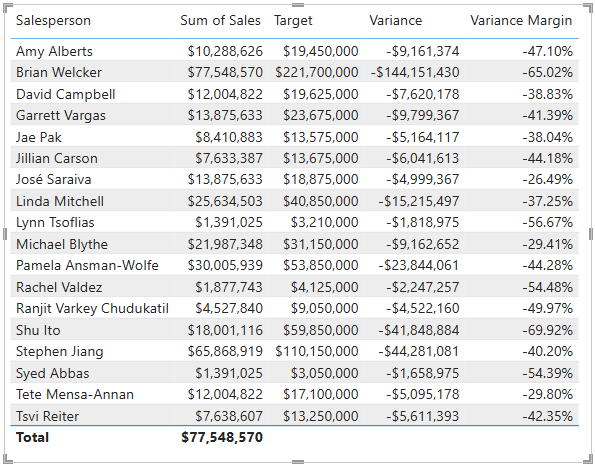

> While it appears all salespeople aren’t meeting target, remember that the table visual isn’t yet filtered by a specific time period. You’ll produce sales performance reports that filter by a user-selected time period in the Design a Report in Power BI Desktop lab.

15. Save the Power BI Desktop file.
#### Lab complete
You may choose to save your Power BI report, though it’s not necessary for this lab. In the next exercise, you’ll work with a pre-made starter file.
1. Navigate to the **File** menu in the top left corner and select **Save As**.
2. Select **Browse this device**.
3. Select the folder where you want to save the file and give it a descriptive name.
4. Select the **Save** button to save your report as a .pbix file.
5. If a dialog box appears prompting you to apply pending query changes, select **Apply**.
6. Close Power BI Desktop.

### **Check your knowledge**

#### 1. Which statement about calculated tables is true?

**A) Calculated tables increase the size of the semantic model.** \
B) Calculated tables are evaluated by using row context. \
C) Calculated tables are created in Power Query. \
D) Calculated tables can't include calculated columns.

#### 2. Which statement about calculated columns is true?

A) Calculated columns are created in the Power Query Editor window. \
**B) Calculated column formulas are evaluated by using row context.** \
C) Calculated column formulas can only reference columns from within their table. \
D) Calculated columns can't be related to noncalculated columns.

#### 3. Which statement about measures is correct?

A) Measures store values in the semantic model. \
B) Measures must be added to the semantic model to achieve summarization. \
C) Measures can reference columns directly. \
**D) Measures can reference other measures directly.**

## **Design semantic models for scale in Microsoft Fabric**

### **Introduction**

#### What is a Semantic Model?
A **Semantic Model** is the analytical layer that sits between raw data and reports.

It defines:

✅ Tables \
✅ Relationships \
✅ Measures \
✅ Calculations \
✅ Business logic \
✅ Security

Used by:
* Power BI Reports
* Dashboards
* Copilot
* Fabric AI Experiences
* External Analysis Tools
#### Why Design for Scale?
A model that works for:
> 10 Users | 100 MB Data

may struggle when it grows to:
> 1000 Users | 100+ GB Data

Challenges include:

❌ Slow queries \
❌ Long refresh times \
❌ Memory pressure \
❌ Complex maintenance \
❌ Poor AI performance
#### Main Design Areas
This module focuses on four major design decisions:
##### 1. Storage Mode
How data is stored and accessed.

Options:
* Import
* DirectQuery
* Direct Lake
* Composite Models
##### 2. Star Schema Design
How tables relate to one another.

Use:
> Fact Tables + Dimension Tables

instead of complex snowflake structures.
##### 3. Scalable Calculations
Choosing:

✅ Efficient measures \
✅ Appropriate DAX patterns \
✅ Minimal calculated columns
##### 4. Model Configuration
Settings that affect:

✅ Performance \
✅ Large datasets \
✅ Concurrency \
✅ External tools \
✅ AI workloads
#### Storage Modes
One of the most important scalability decisions.
##### Import Mode
Data is copied into the semantic model.

**Advantages**

✅ Fastest query performance \
✅ Excellent user experience \
✅ Richest DAX support

**Disadvantages**

❌ Requires refreshes \
❌ Model size limitations

**Best For**

Small and medium datasets.
##### DirectQuery
Queries source data in real time.

**Advantages**

✅ Always current \
✅ Minimal imported data

**Disadvantages**

❌ Slower queries \
❌ Depends on source performance

**Best For**

Very large datasets requiring real-time access.
##### Direct Lake (Fabric)
Fabric's preferred modern option.

**Advantages**

✅ Query lakehouse data directly \
✅ No import needed \
✅ High performance \
✅ Reduced duplication

**Best For**

Microsoft Fabric lakehouse analytics.
##### Composite Models
Mix storage modes.

Example:
> Import + DirectQuery

#### Star Schema Design
##### Recommended Model Structure
```
       DimCustomer
            |
DimDate -- FactSales -- DimProduct
            |
        DimRegion
```
##### Benefits
✅ Simpler design \
✅ Faster filtering \
✅ Better DAX \
✅ Better AI understanding \
✅ Easier maintenance
#### Fact Tables
Store:
* Sales
* Orders
* Revenue
* Quantity

Answer:
* How much?
* How many?

#### Dimension Tables
Store:
* Customer
* Product
* Date
* Region

Answer:
* vWho?
* What?
* When?
* Where?
#### Why Star Schema Helps Scale
##### Better Query Performance
Power BI can navigate relationships efficiently.
##### Better DAX Performance
Measures are simpler.
##### Better AI Experiences
Copilot understands:
> Sales → Customer → Product

relationships more clearly.
#### Scalable Calculation Design
##### Prefer Measures
Use:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
instead of:
```dax
Revenue Column =
...
```
##### Why?
Measures:

✅ Not stored \
✅ Smaller model \
✅ Better memory usage \
✅ Faster refreshes
##### Minimize Calculated Columns
Calculated columns:

❌ Increase model size \
❌ Increase refresh duration \
❌ Consume memory

Use only when required.
#### Calculation Best Practice
##### Good
```dax
Revenue =
SUM(Sales[Sales Amount])

Profit =
[Revenue] - [Cost]
```
##### Less Optimal
Store:
* Revenue Column
* bProfit Column
* Margin Column

for every row.
#### Reusable Measures
Create business measures once.

Examples:
* Revenue
* Profit
* Profit Margin
* YTD Revenue

Benefits:

✅ Consistency \
✅ Easier maintenance \
✅ Better governance
#### Large Model Considerations
As models grow:
##### Monitor
✅ Model size \
✅ Refresh duration \
✅ Query speed \
✅ Memory usage
##### Reduce
❌ Unused columns \
❌ Unused tables \
❌ Excess calculated columns
#### External Tool Access
Scaled semantic models often connect to:
* Power BI
* Excel
* SSMS
* Tabular Editor
* DAX Studio

Design should support multiple consumers without performance degradation.
#### Concurrency
Concurrency means:
> Many users querying simultaneously

Example:
> 100 report users

running queries at the same time.

Scalable models should:

✅ Handle many concurrent queries \
✅ Maintain acceptable response times
#### AI and Semantic Models
Copilot and AI place additional demands on models.

AI performs best when models have:

✅ Current data \
✅ Clear relationships \
✅ Star schema design \
✅ Descriptive names \
✅ Well-written measures
##### Good Example
```
FactSales
DimCustomer
Revenue
Profit Margin
```
##### Poor Example
```
Table1
Column2
Measure3
```
AI struggles to interpret unclear metadata.
#### Typical Enterprise Fabric Architecture
> Lakehouse → Warehouse → Semantic Model → Measures → Power BI → Copilot → Business Users

#### Design Goals
A scalable semantic model should be:

✅ Fast \
✅ Maintainable \
✅ Understandable \
✅ Memory-efficient \
✅ AI-friendly \
✅ Easy to extend
#### Exam Quick Facts
✅ Semantic models power:
* Reports
* Dashboards
* Copilot
* AI experiences

✅ Four major design decisions:
1. Storage Mode
2. Star Schema
3. Calculation Design
4. Model Configuration

✅ Recommended schema:
> Fact + Dimensions

✅ Measures scale better than calculated columns \
✅ Calculated columns increase model size \
✅ Direct Lake is Fabric's preferred large-scale model approach \
✅ Star schemas improve:
* Performance
* Simplicity
* AI understanding

✅ Good semantic models support:
* Large datasets
* Concurrent users
* External tools
* AI workloads
#### Memory Trick
> Scale = Storage + Schema + Calculations + Settings

Or:
> Store Smart → Model Smart → Calculate Smart → Scale Smart ⭐

### **Choose a storage mode**

#### Why Storage Mode Matters
Storage mode determines:

✅ Query performance \
✅ Data freshness \
✅ Model size \
✅ Scalability \
✅ AI/Copilot performance

It is the **first design decision** when creating a semantic model.
#### Storage Modes in Fabric
There are 4 storage modes:
1. Direct Lake ⭐ (Default)
2. Import
3. DirectQuery
4. Composite
#### 1. Direct Lake (Recommended)
##### What is Direct Lake?
Direct Lake reads Delta tables directly from OneLake.

Unlike Import:

❌ No data copy

Unlike DirectQuery:

❌ No SQL translation

Instead:
> OneLake Delta Files → Direct Lake → Semantic Model

##### Major Benefits
**Near Real-Time Data**

Changes in Delta tables become available immediately.

✅ No scheduled refresh required

**High Performance**

Combines:
> Import Speed + DirectQuery Freshness

##### Fabric-Native
Best choice for:
* Lakehouses
* Warehouses
* OneLake
##### Direct Lake Architecture
> Delta Tables → OneLake → Direct Lake → Power BI → Copilot

##### Large Semantic Model Support
Direct Lake automatically enables:

Large Semantic Model Format

Benefits:

✅ Removes 10-GB limit \
✅ Supports Query Scaleout \
✅ Supports XMLA Read/Write
##### Exam Tip
For Direct Lake:

✅ Automatically enabled \
❌ No manual configuration required
#### Direct Lake Connection Options
##### Option 1: OneLake Tables
Connect directly to:
* Lakehouse Tables
* Warehouse Tables

**Best For**

✅ Single data source \
✅ Simpler architecture \
✅ Most scenarios
##### Option 2: SQL Analytics Endpoint
Connect via SQL endpoint.

**Benefits**

✅ Views \
✅ Cross-database queries \
✅ SQL-based security \
✅ Governance requirements
##### Exam Tip
Use SQL Analytics Endpoint when:
* Views
* Cross-Database Queries
* SQL Security

are required.
#### Direct Lake Fallback
Sometimes Direct Lake cannot execute a query.

Examples:

✅ Memory pressure \
✅ Unsupported operations \
✅ Complex DAX

Then Fabric falls back to DirectQuery mode.
#### Fallback Options
##### Allow Fallback
> Direct Lake → If Needed → DirectQuery

User still receives results.

**Benefit**

✅ More reliable \
✅ Better user experience
##### Disallow Fallback
> Direct Lake Only

If unsupported:
> `Error Returned`

**Benefit**

✅ Consistent performance expectations

**Exam Recommendation**

Start with:

✅ Allow Fallback

Monitor:

✅ Which queries trigger it

Optimize later.
#### 2. Import Mode
##### What is Import Mode?
Copies data into the model.
> Source → Imported Data → In-Memory Storage

##### Benefits
**Fastest Query Performance**
* Queries run against memory.
* Extremely fast

**Rich Feature Support**
* Supports almost all Power BI features.

##### Drawbacks
**Data Becomes Stale**
* Requires refresh.
      > Refresh → Updated Data

**Storage Consumption**
* Data is duplicated.
#### Use Import When
✅ External sources \
✅ On-prem databases \
✅ APIs \
✅ Maximum performance needed \
✅ Real-time not required
#### Import Best Practices\
✅ Use views \
✅ Remove unnecessary columns \
✅ Use proper data types \
✅ Reduce model size
#### 3. DirectQuery
##### What is DirectQuery?
Queries source systems in real time.
> Report → Source Database

##### Data Storage
❌ No data stored in model
##### Benefits
**Real-Time Data**
* Always current.

**Handles Very Large Datasets**
* No import needed.
##### Drawbacks
**Slower Performance**

Every interaction:
> Visual Click → Database Query

**Source Dependency**

If database is slow:

✅ Report becomes slow
#### Use DirectQuery When
✅ Real-time reporting is required \
✅ External data is too large \
✅ Governance requires data to remain at source
#### 4. Composite Mode
##### What is Composite Mode?
Combines storage modes.

Example:
> Direct Lake + Import

or
> Import + DirectQuery

##### Benefits
**Hybrid Architecture**
* Each table uses the best storage mode.

Example
> Fact Sales → Direct Lake \
> Reference Table → Import

#### Use Composite When
✅ Fabric + external sources \
✅ Mixed freshness requirements \
✅ Hybrid analytics
#### Storage Mode Comparison
| Mode        | Data Location | Speed             | Freshness      | Best For                 |
| ----------- | ------------- | ----------------- | -------------- | ------------------------ |
| Direct Lake | OneLake       | Fast              | Near Real-Time | Fabric (default)         |
| Import      | Model Memory  | Fastest           | Refresh-based  | External sources         |
| DirectQuery | Source System | Depends on source | Real-Time      | Very large external data |
| Composite   | Mixed         | Mixed             | Mixed          | Hybrid solutions         |

#### Which Storage Mode Should You Choose?
##### Data in Fabric?
✅ Yes → Use Direct Lake

##### Data Outside Fabric?
**Need best performance?**

✅ Yes → Use Import

**Need Real-Time Data?**

✅ Yes → Use DirectQuery

**Need Multiple Sources?**

✅ Yes → Use Composite

#### Storage Modes and AI
Storage mode affects:

✅ Copilot \
✅ Fabric AI \
✅ Data Agents
#### Direct Lake Advantage
Because data stays current:
> Updated Delta Table → Updated Semantic Model → Updated Copilot Answers

No refresh delay.
#### Exam Quick Facts
✅ Direct Lake is the default storage mode in Fabric \
✅ Direct Lake reads Delta tables directly from OneLake \
✅ Direct Lake combines:
* Import performance
* DirectQuery freshness

✅ Direct Lake automatically enables:
* Large Semantic Models
* Query Scaleout
* XMLA Read/Write

✅ Direct Lake connection types:
* OneLake Tables
* SQL Analytics Endpoint

✅ DirectQuery stores no data in the model \
✅ Import mode provides the fastest query performance \
✅ DirectQuery provides the freshest data \
✅ Composite models combine storage modes
#### Memory Trick
> Fabric → Direct Lake First

Think:
* Direct Lake = Default
* Import = Fastest
* DirectQuery = Real-Time
* Composite = Hybrid

⭐ Exam Rule: 
> *If the question asks "What storage mode should you start with in Microsoft Fabric?"* 

→ Direct Lake.

### **Design star schema for semantic models**

#### What is a Star Schema?
A **Star Schema** is the recommended design pattern for semantic models.

It consists of:
> Fact Tables + Dimension Tables

Example:
```
       DimCustomer
            |
DimDate -- FactSales -- DimProduct
            |
        DimRegion
```
#### Why Use a Star Schema?
Benefits:

✅ Simpler relationships \
✅ Faster queries \
✅ Easier DAX \
✅ Better scalability \
✅ Better Copilot and AI performance \
✅ Easier maintenance
#### Fact Tables
#### Purpose
Store measurable business events.

Examples:
* Sales
* Orders
* Inventory
* Shipments
##### ontains
Measures such as:
* Sales Amount
* Quantity
* Cost
* Profit
##### Answers
* How much?
* How many?
#### Dimension Tables
##### Purpose
Provide descriptive context.

Examples:
* Customer
* Product
* Date
* Category
* Region
##### Contains
Attributes such as:
* Customer Name
* Product Category
* City
* Fiscal Year
##### Answers
* Who?
* What?
* When?
* Where?
#### Star Schema and AI
Copilot and AI tools work best when relationships are clear.

Example:
> Revenue → Customer → Region

is easy for AI to understand.
##### Poor Design
* Circular Relationships
* Multiple Ambiguous Paths
* Snowflake Complexity

can confuse:

❌ Users \
❌ DAX \
❌ Copilot
#### Relationships in a Star Schema
The most common relationship is:
##### One-to-Many
> Dimension (One) → Fact (Many)

Example:
> One Product → Thousands of Sales Rows

##### Example
```
DimProduct[ProductKey] → FactSales[ProductKey]
```
##### Best Practice
Configure filtering:
> Dimension → Fact

Only.
##### Exam Memory
✅ One-to-Many is the standard star schema relationship.
#### Filter Direction
##### Single Direction (Recommended)
> Dimension → Fact

Example:
> Product → Sales

Filtering:
> Product Category = Bikes

filters Sales.
##### Benefits
✅ Predictable results \
✅ Better performance \
✅ Easier troubleshooting
##### Bi-Directional Filtering
> Dimension ↔ Fact

Filters flow both ways.
##### Use Sparingly
Only when necessary:

✅ Certain many-to-many scenarios \
✅ Special reporting requirements
##### Risks
❌ Slower queries \
❌ Unexpected results \
❌ Ambiguous filter propagation
##### Exam Tip
Default recommendation:

✅ Single-direction filters
#### Many-to-Many Relationships
##### Problem
Neither side contains unique values.

Example:
> Customer ↔ Account

A customer can have:
> Multiple Accounts

An account can belong to:
> Multiple Customers

##### Solution: Bridge Table
Example:
> Customer → CustomerAccountBridge → Account

##### Relationship Pattern
> One-to-Many + One-to-Many

instead of direct many-to-many.
#### Direct Lake Relationship Design
In Direct Lake, relationships perform best when:
##### 1. Low Cardinality Keys
Example:

✅ `ProductKey` \
✅ `CustomerKey`

Avoid:

❌ Highly unique text columns
##### 2. Referential Integrity Exists
Every fact row should match a dimension row.

Example:
> `CustomerKey` in Fact exists in `Customer` Dimension

**Benefit**

Engine can use:
```
INNER JOIN
```
instead of:
```
LEFT OUTER JOIN
```
for better performance.
##### 3. Indexed Columns
Relationship columns should be optimized in Delta tables.
#### Referential Integrity
##### What Is It?
Every foreign key has a valid matching dimension row.

Example:
```
FactSales.CustomerKey = 100
```
must exist in:
```
DimCustomer.CustomerKey = 100
```
#### Assume Referential Integrity
Available in:

✅ Direct Lake \
✅ DirectQuery
##### Benefit
Allows:
```
INNER JOIN
```
which improves performance.
##### Warning
If integrity is broken:
> Missing Rows

may disappear from results.
##### Exam Tip
Enable only when confident all keys match.
#### Active and Inactive Relationships
A common exam topic.
##### Rule
Only:
> ONE ACTIVE RELATIONSHIP

between two tables.
##### Example
Sales table contains:
* `Order Date`
* `Ship Date`

Both relate to:
* `Date Table`

Only one can be:

✅ Active

The other becomes:

❌ Inactive
#### `USERELATIONSHIP`
Used to activate an inactive relationship in a measure.

Example:
```dax
Shipped Amount =
CALCULATE(
    SUM(Sales[Amount]),
    USERELATIONSHIP(
        Sales[ShipDate],
        'Date'[Date]
    )
)
```
##### Purpose
Analyze data using:
> `Ship Date`

instead of:
> `Order Date`

without changing model relationships.
##### Exam Tip
Remember:
```dax
USERELATIONSHIP()
```
is used with inactive relationships.
#### Snowflake Schema
##### What is Snowflake?
Normalized dimension design.

Example:
> Category → Subcategory → Product → Fact Sales

##### Structure
**Multiple Related Dimensions**

instead of:

**Single Product Dimension**
#### Option 1: Flatten Snowflake (Recommended)
Convert:
* Category
* Subcategory
* Product

into:
```
DimProduct
```
##### Benefits
✅ Fewer tables \
✅ Fewer relationships \
✅ Faster queries \
✅ Easier DAX \
✅ Better AI understanding
##### Exam Recommendation
Most Fabric semantic models should:

✅ Flatten dimensions into a star schema.
#### Option 2: Preserve Snowflake
Keep normalized structure.

Use when:
##### 1. Large Hierarchies
Too many repeated attributes.
##### 2. Shared Subdimensions
Example:
> Category

used by:
* Sales Fact
* Inventory Fact
##### 3. Row-Level Security Requirements
Security managed at hierarchy levels.
#### Snowflake Relationship Rules
If preserved:

Filters should flow:
> Category → Subcategory → Product → Fact

using single-direction filtering.
#### Cross-Source Relationships
Fabric supports:
> Lakehouse + Warehouse + External Sources

inside one model.
#### Composite Models
Used when tables come from different sources.

Example:
> Fact Sales → Direct Lake \
> Reference Table → Import

##### Good Scenarios
✅ Lakehouse + Warehouse \
✅ Direct Lake + Import \
✅ External Reference Data \
✅ Streaming + Historical Data
#### Storage Modes and Relationships
| Storage Mode | Relationship Considerations   |
| ------------ | ----------------------------- |
| Direct Lake  | Best Fabric performance       |
| Import       | Fully cached relationships    |
| DirectQuery  | Depends on source performance |
| Composite    | Cross-source relationships    |

#### Star Schema Best Practices
✅ Fact tables store measurements \
✅ Dimension tables store attributes \
✅ One-to-many relationships \
✅ Single-direction filtering \
✅ Maintain referential integrity \
✅ Use `USERELATIONSHIP` for inactive relationships \
✅ Flatten snowflake dimensions whenever possible \
✅ Use bridge tables for many-to-many relationships
#### Exam Quick Facts
✅ Star schema = Fact + Dimensions \
✅ Fact tables contain measures \
✅ Dimension tables contain descriptive attributes \
✅ Most common relationship:
> One-to-Many

✅ Recommended filter direction:
> Dimension → Fact

✅ Use bridge tables for many-to-many relationships \
✅ Assume Referential Integrity enables `INNER JOIN` behavior \
✅ Only one active relationship allowed between two tables \
✅ Use:
```dax
USERELATIONSHIP()
```
to activate inactive relationships

✅ Flatten snowflake dimensions whenever possible \
✅ Composite models support cross-source relationships
#### Memory Trick
> Star Schema = Facts in the Center, Dimensions Around Them ⭐

And remember the exam rule:
* Dimension → Fact
* One-to-Many
* Single Direction

This is the default and recommended semantic model design in Microsoft Fabric.

### **Design scalable calculations**

#### Why Calculation Design Matters
A model with:
> 10 Measures

can survive poor design.

A model with:
> 200+ Measures \
> 100+ Reports \
> Many Developers

cannot.

Poor calculation design causes:

❌ Duplicate logic \
❌ Slow queries \
❌ Maintenance nightmares \
❌ Inconsistent business metrics \
❌ Confusing Copilot results
#### Three Key Scalability Patterns
This unit focuses on:
1. Calculation Groups
2. DAX Readability & Maintainability
3. Aggregations
#### 1. Calculation Groups
##### What Are Calculation Groups?
A **Calculation Group** allows you to define a calculation pattern once and apply it to many measures.
##### Problem Without Calculation Groups
Assume:
> 50 Measures

Need:
```
YTD
QTD
MTD
```
for each.

Result:
> 50 × 3 = 150 additional measures

Add:
```
Prior Year
Growth %
Variance
```
and you can easily exceed:
> 250+ measures

##### Solution: Calculation Groups
Create one calculation group containing:
* Year-to-Date
* Quarter-to-Date
* Month-to-Date

Then use it for every measure.
##### Example
**YTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESYTD('Date'[Date])
)
```
**QTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESQTD('Date'[Date])
)
```
**MTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESMTD('Date'[Date])
)
```
#### `SELECTEDMEASURE()`
Most important calculation-group concept.
##### Purpose
Returns:
> Current Measure

being evaluated.

Examples:
> Revenue \
> Profit \
> Quantity

The same calculation item can work for all of them.
##### Exam Tip
`SELECTEDMEASURE()`

is heavily associated with:

✅ Calculation Groups
#### Benefits of Calculation Groups
✅ Fewer measures \
✅ Easier maintenance \
✅ Consistent business logic \
✅ Smaller semantic model \
✅ Easier AI interpretation
#### When to Use Calculation Groups
Use when:

✅ 3 or more measures require identical logic

Common scenarios:
##### Time Intelligence
```
YTD
QTD
MTD
```
##### Currency Conversion
```
USD
EUR
GBP
```
##### Variance Analysis
```
Actual
Budget
Variance
Variance %
```
#### Dynamic Format Strings
##### Purpose
Change formatting automatically based on context.

Example:
##### Currency
`$1,250.00`
##### Percentage
`12.5%`
##### Example
`"0.0%"`

used in a:

`YoY %`

calculation item.
##### Benefit
Avoids creating:
```
Revenue %
Profit %
Margin %
```
formatted measures separately.
#### 2. DAX Readability Discipline
##### Why It Matters
In enterprise models:
* Hundreds of Measures
* Multiple Developers
* Years of Maintenance

Readability becomes critical.
#### Variables (VAR)
##### Purpose
Store intermediate calculations.
##### Example
```dax
Profit Margin =
VAR TotalRevenue =
    SUM(Sales[Revenue])

VAR TotalCost =
    SUM(Sales[Cost])

VAR ProfitAmount =
    TotalRevenue - TotalCost

RETURN
    DIVIDE(
        ProfitAmount,
        TotalRevenue
    )
```
#### Benefits of Variables
✅ Easier to read \
✅ Easier debugging \
✅ Reuse calculations \
✅ Better performance
##### Without Variables
You may repeat:
```dax
SUM(Sales[Revenue])
```
multiple times.
##### With Variables
* Calculate once.
* Reuse many times.
##### Exam Tip
```dax
VAR
RETURN
```
is a recommended DAX pattern.
#### Naming Conventions
A very common enterprise design principle.
##### Measure Naming
**Good**
> Total Sales \
> Profit Margin \
> YoY Revenue Growth

**Bad**
> `Measure1` \
> `Sales_Calc_Rev` \
> `Test_v2`

##### Variable Naming
**Good**
```dax
TotalRevenue
ProfitAmount
```
**Bad**
```
x
temp
value1
```
##### Calculation Group Names
**Good**
> Year-to-Date \
> Quarter-to-Date

**Bad**
```
DATESYTD Wrapper
Calc Item 1
```
#### AI & Naming
Good naming improves:

✅ Copilot \
✅ AI-generated insights \
✅ Natural language queries

Example:
> YoY Revenue Growth

is easier for AI to understand than:
```
Calc7_v2
```
#### Aggregation Functions vs Iterator Functions
##### Aggregation Functions
Operate on a single column.

Example:
```dax
SUM(Sales[Amount])
```
##### Benefits
✅ Faster \
✅ More efficient \
✅ Preferred when possible
##### Iterator Functions
Operate row-by-row.

Examples:
```dax
SUMX
AVERAGEX
MAXX
```
##### Example
```dax
SUMX(
    Sales,
    Sales[Quantity]
        *
    Sales[Unit Price]
)
```
##### Benefits
✅ More flexible \
✅ Multiple columns \
✅ Complex logic
##### Drawback
❌ Slower on large tables
##### Exam Rule
**Use: Aggregation Functions**
* when summarizing one column.

**Use Iterator Functions**
* when row-level calculations are required.
#### Information Functions
Useful for defensive DAX.
##### `HASONEVALUE()`
Checks whether exactly one value exists.

Example:
```dax
HASONEVALUE(
    Customer[CustomerID]
)
```
##### `ISBLANK()`
Checks for blank values.

Example:
```dax
IF(
    ISBLANK([Revenue]),
    0
)
```
##### `ISINSCOPE()`
* Checks whether a column is currently being grouped.
* Useful in matrix visuals and hierarchies.
#### Defensive Measure Example
```dax
Sales per Customer =
IF(
    HASONEVALUE(
        Customer[CustomerID]
    ),
    DIVIDE(
        SUM(Sales[Amount]),
        1
    ),
    DIVIDE(
        SUM(Sales[Amount]),
        DISTINCTCOUNT(
            Sales[CustomerID]
        )
    )
)
```
#### Why Use Defensive Patterns?
Protects measures from:

✅ Unexpected filters \
✅ Different reports \ 
✅ AI-generated queries \
✅ New report scenarios
#### 3. Aggregations
##### What Are Aggregations?
Aggregation tables store:
> Precalculated Summaries

at higher levels.
##### Example
Instead of:
> 500 Million Sales Rows

create:
> Monthly Sales by Region

aggregation table.
##### Benefits
Queries can hit:
> Small Summary Table

instead of:
> Massive Fact Table

Result:

✅ Faster queries \
✅ Less resource usage \
✅ Better scalability
#### When to Consider Aggregations
Use when:

✅ Fact table contains millions of rows \
✅ Most reports summarize data \
✅ Query performance becomes an issue
##### Typical Example
Store:
> Monthly Sales

instead of forcing scans over:
> Daily Transactions

every time.
#### Aggregations in Import Mode
Stored as:
> Hidden Aggregation Tables

Query engine automatically uses them.
#### Aggregations in Direct Lake
Direct Lake handles large volumes efficiently already.

Therefore:

✅ Add aggregations only when monitoring proves they're needed.
##### Exam Tip
Direct Lake generally requires fewer aggregation tables than Import models.
#### Scalable Calculation Best Practices
✅ Use Calculation Groups for repetitive logic \
✅ Use `SELECTEDMEASURE()` inside Calculation Groups \
✅ Use `VAR` and `RETURN` \
✅ Create clear naming conventions \
✅ Use aggregation functions when possible \
✅ Minimize iterators on large datasets \
✅ Use `HASONEVALUE` and `ISBLANK` defensively \
✅ Add aggregation tables when fact tables become very large
#### Exam Quick Facts
✅ Calculation Groups reduce measure proliferation \
✅ Calculation Groups rely on:
```dax
SELECTEDMEASURE()
```
✅ Common Calculation Group use cases:
* YTD
* QTD
* MTD
* Currency Conversion
* Variance Analysis

✅ Dynamic Format Strings adjust formatting automatically \
✅ `VAR` improves readability and performance \
✅ Aggregation functions are generally faster than iterators \
✅ Iterator functions:
* `SUMX`
* `AVERAGEX`
* `MAXX`

✅ Information functions:
* `HASONEVALUE`
* `ISBLANK`
* `ISINSCOPE`

✅ Aggregations store precalculated summaries \
✅ Consider aggregations when fact tables reach millions of rows
#### Memory Trick
> Scale Calculations = Reuse + Readability + Aggregations

or
>Calculation Groups → Variables → Aggregations

⭐⭐ Most important exam concept:
> Calculation Group → `SELECTEDMEASURE()`

They almost always appear together in Microsoft Fabric and Power BI semantic model questions.

### **Configure settings for scale**

#### Why These Settings Matter
After designing:

✅ Storage Mode \
✅ Star Schema \
✅ Measures

You must configure settings that support:
* Large datasets
* High concurrency
* External tools
* Direct Lake optimization
* Enterprise deployments

These settings determine whether the model can scale from:
> Small Team → Enterprise Analytics

#### 1. Large Semantic Model Storage Format
##### What Does It Do?
Increases semantic model size capacity.

Without it:
> 10 GB Upload Limit

With it:
> Model Can Grow Beyond 10 GB

(subject to Fabric capacity limits)
##### Why It Matters
Large enterprise models often exceed:
> 10 GB

especially with:
* Large fact tables
* Incremental refresh
* Historical data
##### Direct Lake Behavior
**Important Exam Fact**

Direct Lake models:

✅ Automatically enable Large Semantic Model Storage Format.

No manual setup required.
##### Import Models
Must be enabled manually.
##### Enable It When
✅ Model exceeds 10 GB \
✅ Using XMLA Read/Write \
✅ Using Query Scaleout \
✅ Using Incremental Refresh
##### Exam Memory
Large Semantic Models are required for:
> XMLA \
> Query Scaleout \
> Large Datasets

#### 2. XMLA Endpoint Read/Write
##### What is XMLA?
* XMLA provides external access to semantic models.
* Allows enterprise development tools to connect.
##### Common Tools
**Tabular Editor**

Used for:

✅ Model development \
✅ Calculation groups \
✅ Advanced modeling

**DAX Studio**

Used for:

✅ DAX debugging \
✅ Query tuning \
✅ Performance analysis

**ALM Toolkit**

Used for:

✅ Deployment \
✅ Versioning \
✅ CI/CD
#### Requirements
Must have:

✅ Large Semantic Model Storage Format enabled
#### Benefits
Enables:

✅ Enterprise development workflows \
✅ Source control integration \
✅ Automated deployments
##### Exam Tip
At enterprise scale:
> XMLA Endpoint

becomes extremely important.
#### 3. Query Scaleout
##### What Problem Does It Solve?
Many users running queries simultaneously.

Example:
> 500 Users

connecting to:
> One Semantic Model

##### Without Scaleout
> Single Model Instance → Performance Bottleneck

##### With Scaleout
> Primary Model → Multiple Read Replicas → Shared Query Load

#### How It Works
Creates:
> Read-Only Replicas

of the semantic model.

User queries are distributed across replicas.
#### Benefits
✅ Higher concurrency \
✅ Better response times \
✅ Reduced bottlenecks \
✅ Enterprise scalability
#### Important Behavior
After refresh:
> Primary Model Refreshes → Replicas Synchronize

There may be a small delay before replicas reflect refreshed data.
#### Requirements
Query Scaleout requires:

✅ Large Semantic Model Storage Format
#### Enable Query Scaleout When
✅ Hundreds of users \
✅ Peak-time slowdowns \
✅ Heavy dashboard usage \
✅ Supported Fabric capacity
##### Exam Memory
> Large Semantic Model → Required For → Query Scaleout

#### 4. Direct Lake Fallback
##### Why Does Fallback Exist?
Some Direct Lake queries cannot execute directly.

Examples:

✅ Memory limitations \
✅ Unsupported operations \
✅ Complex queries
##### Allow Fallback (Default)
Behavior:
> Direct Lake → Cannot Execute → DirectQuery

Query still works.
##### Benefits
✅ Better user experience \
✅ More reliable results 
##### Disallow Fallback
Behavior:
> Direct Lake → Cannot Execute → Error

##### Benefits
✅ Predictable performance \
✅ Strict Direct Lake enforcement
#### Recommendation
For most production models:

✅ Allow Fallback

Then:

✅ Identify fallback queries

✅ Optimize them
##### Exam Tip
Default recommendation:
> Allow Fallback

#### 5. OneLake Integration
##### What Does It Do?
Exposes semantic model data to other Fabric services.
##### Consumers
✅ Notebooks \
✅ Pipelines \
✅ Data Engineering \
✅ Data Science \
✅ Fabric Services
##### Benefit
Turns a semantic model into:
> Shared Curated Data Source

instead of only a reporting layer.
##### Example
> Lakehouse → Semantic Model → Notebook Reads Data

without rebuilding the logic.
#### Enable OneLake Integration When
✅ Data scientists need model data \
✅ Data engineers need curated data \
✅ Semantic model becomes a reusable business layer
#### OneLake Integration Limitation
Currently supports:

✅ Import Tables

Does NOT export:

❌ Direct Lake tables \
❌ DirectQuery tables \
❌ Measures \
❌ Calculation Groups
##### Why?
Direct Lake tables already exist in OneLake.
#### Enterprise Configuration Flow
> Large Semantic Model → XMLA Endpoint → Query Scaleout → High-Concurrency Analytics

#### Recommended Configuration Strategy
##### Direct Lake Model
✅ Large Semantic Model (automatic) \
✅ Allow Fallback \
✅ Consider Query Scaleout \
✅ Consider OneLake Integration
##### Enterprise Import Model
✅ Enable Large Semantic Model \
✅ Enable XMLA Read/Write \
✅ Consider Query Scaleout \
✅ Consider OneLake Integration
#### Settings Decision Table
| Setting                             | Default             | Enable When                       |
| ----------------------------------- | ------------------- | --------------------------------- |
| Large Semantic Model Storage Format | Off (Import models) | Model >10GB, XMLA, Query Scaleout |
| XMLA Read/Write                     | Read-only           | External tool development         |
| Query Scaleout                      | Off                 | High concurrency                  |
| Direct Lake Fallback                | Allowed             | Keep allowed for most workloads   |
| OneLake Integration                 | Off                 | Downstream Fabric reuse           |

#### Dependency Relationships (Exam Favorite)
> Large Semantic Model Storage Format → Required For: → XMLA Endpoint/Query Scaleout

#### Exam Quick Facts
✅ Direct Lake automatically enables Large Semantic Model Storage Format \
✅ Large Semantic Model removes the 10 GB upload limitation \
✅ XMLA Endpoint enables:
* Tabular Editor
* DAX Studio
* ALM Toolkit

✅ Query Scaleout uses read-only replicas \
✅ Query Scaleout requires Large Semantic Model Storage Format \
✅ Direct Lake fallback options:
* Allow
* Disallow

✅ Recommended fallback setting:
* Allow

✅ OneLake Integration enables semantic model reuse across Fabric \
✅ OneLake Integration currently works only with Import tables
#### Memory Trick
##### Scale Settings Pyramid
> Large Semantic Model → XMLA → Query Scaleout → Enterprise Scale

##### Most Tested Dependency
⭐ Large Semantic Model Storage Format is required before enabling XMLA Read/Write and Query Scaleout.

### **Exercise: Design a semantic model for scale in Fabric**

#### Before you start
> Note: You need Power BI Desktop (November 2025 or newer) installed to complete this exercise.

1. Download the [Sales Analysis starter file](https://github.com/MicrosoftLearning/mslearn-fabric/raw/main/Allfiles/Labs/15/15-scalable-semantic-models.zip) and save it locally.
2. Extract the folder to the** C:\Users\Student\Downloads\15-scalable-semantic-models** folder.
3. Open the **15-Starter-Sales Analysis.pbix** file.
> Ignore and close any warnings asking to apply changes - don’t select Discard changes.

#### Work with relationships
In this task, you will open a pre-developed Power BI Desktop solution to learn about the data model. You will then explore the behavior of active model relationships.
1. In Power BI Desktop, at the left, switch to **Model** view.

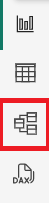

2. Use the model diagram to review the model design.

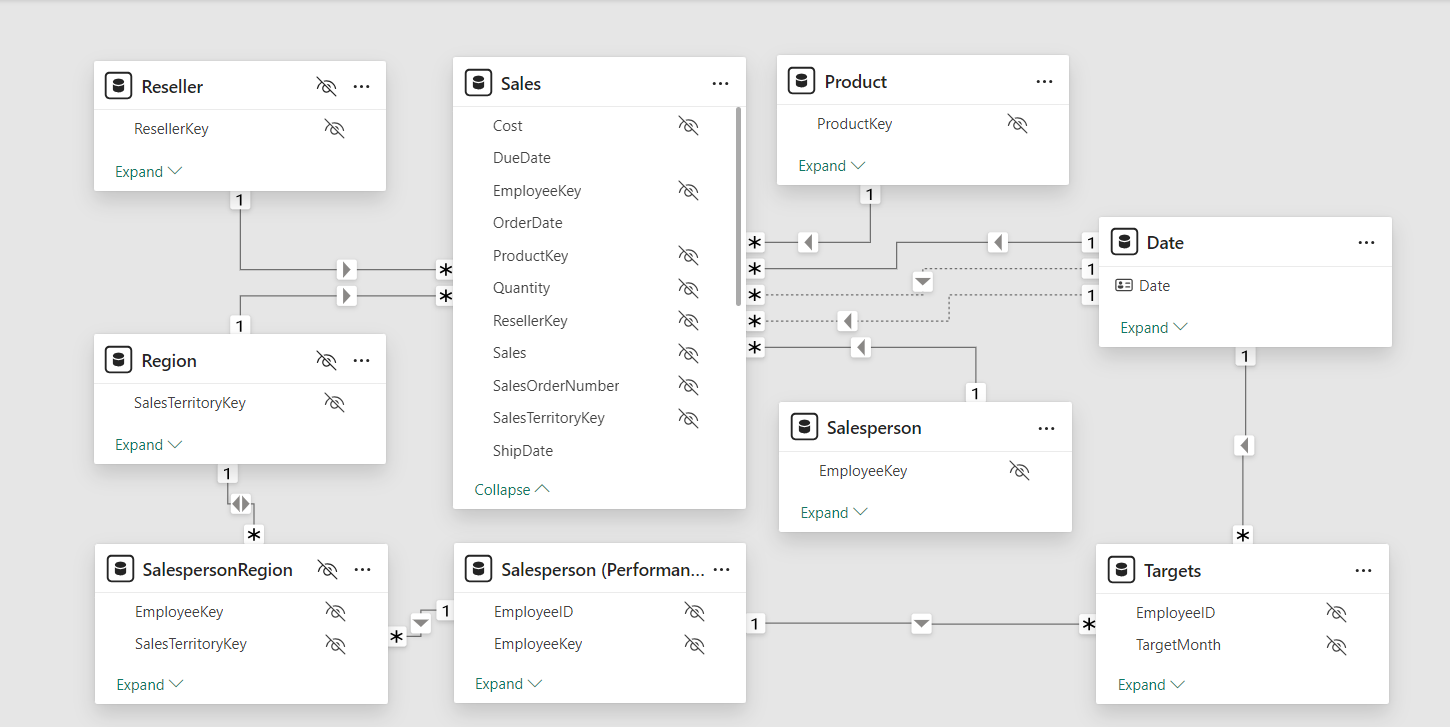

3. Notice that there are three relationships between the **Date** and **Sales** tables.

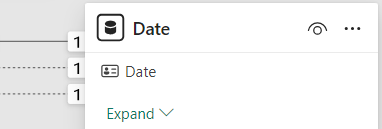

> The Date column in the Date table is a unique column representing the “one” side of the relationships. Filters applied to any column of the Date table propagate to the Sales table using one of the relationships.*

4. Hover the cursor over each of the three relationships to highlight the “many” side column in the **Sales** table.
5. Notice that the relationship between **Date** and **OrderDate** is active. The current model design indicates that the **Date** table is a role-playing dimension. This dimension could play the role of order date, due date, or ship date. Which role depends on the analytical requirements of the report.
> We’ll use DAX later to use these inactive relationships without creating another table just to get two active relationships for different date columns.

##### Visualize sales data by date
In this task, you will visualize the total sales by year and use inactive relationships.
1. Switch to Report view.

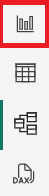

2. To add a table visual, in the **Visualizations** pane, select the **Table** visual icon.

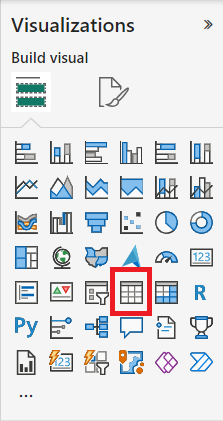

3. To add columns to the table visual, in the **Data** pane (located at the right), first expand the **Date** table.
4. Drag the **Year** column and drop it into the table visual.
5. Expand open the **Sales** table, and then drag and drop the **Total Sales** column into the table visual.
6. Review the table visual.

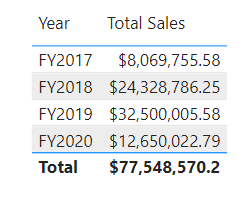

> The table visual shows the sum of the Total Sales column grouped by year. But what does Year mean? Because there’s an active relationship between the Date and Sales tables to the OrderDate column, Year means the fiscal year in which the orders were made.

##### Use inactive relationships
In this task, you will use the `USERELATIONSHIP` function to make an inactive relationship active.
1. In the **Data** pane, right-click the **Sales** table, and then select **New measure**.

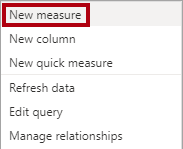

2. In the formula bar (located beneath the ribbon), replace the text with the following measure definition, and then press **Enter**.

```dax
Sales Shipped =
CALCULATE (
SUM ('Sales'[Sales]),
USERELATIONSHIP('Date'[Date], 'Sales'[ShipDate])
)
```
> This formula uses the `CALCULATE` function to modify the filter context. It’s the `USERELATIONSHIP` function that makes the `ShipDate` relationship active, only for this measure.

3. Add the **Sales Shipped** measure to the table visual.
4. Widen the table visual so all columns are fully visible. Observe that the **Total** row is the same but the sales amount for each year in **Total Sales** and **Sales Shipped** is different. That difference is due to orders being received in a given year while being shipped only in the following year or that are not even shipped yet.

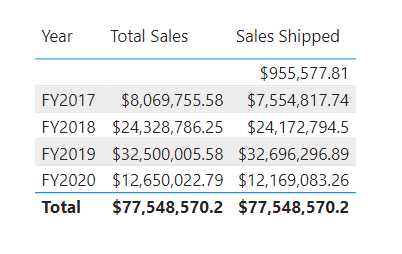

> Creating measures that temporarily set relationships as active is one way to work with role-playing dimensions. However, it can become tedious when there’s a need to create role-playing versions for many measures. For example, if there were 10 sales-related measures and three role-playing dates, it could mean creating 30 measures. Creating them with calculation groups makes the process easier.

#### Create calculation groups
In this task, you will create a calculation group for Time Intelligence analysis.
1. Switch to **Model** view.
2. In the Model view, select **Calculation Group** to create a new calculation group table, group column, and item. If a warning window pops up, select **Yes** to confirm the creation of the calculation group.

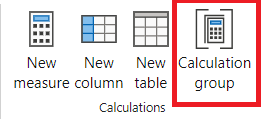

> Note: An implicit measure occurs when, in the Report view, you use a data column from the Data pane directly in a visual. The visual allows you to aggregate it as a `SUM`, `AVERAGE`, `MIN`, `MAX`, or some other basic aggregation, which becomes an implicit measure. Once you create a calculation group, Power BI Desktop won’t create implicit measures anymore, meaning you must create measures explicitly to aggregate data columns.

3. Rename the calculation group to *Time Calculations* and the calculation column to *Yearly Calculations*.
4. In the **Model** tab of the **Data** pane, select the calculation item automatically created with your calculation group.
5. Replace and commit the item’s formula with the following:

```dax
Year-to-Date (YTD) = CALCULATE(SELECTEDMEASURE(), DATESYTD('Date'[Date]))
```
6. Right-click on the **Calculation items** field and select **New calculation item**.
7. Use the following DAX formula for the new item:

```dax
Previous Year (PY) = CALCULATE(SELECTEDMEASURE(), PREVIOUSYEAR('Date'[Date]))
```
8. Create a third item with the following DAX formula:

```dax
Year-over-Year (YoY) Growth = 
VAR MeasurePriorYear =
CALCULATE(
    SELECTEDMEASURE(),
    SAMEPERIODLASTYEAR('Date'[Date])
)
RETURN
DIVIDE(
    (SELECTEDMEASURE() - MeasurePriorYear),
    MeasurePriorYear
)
```
The last calculation item should return values in percentage only, so it needs a dynamic format string to change the format of the measures it affects.
1. In the **Properties** pane of the YoY item, enable the **Dynamic format string** feature.
2. In the DAX formula bar, verify that the field to its left is set as **Format**, and write the following format string: `"0.##%"`
3. Confirm that your calculation group looks as follows:

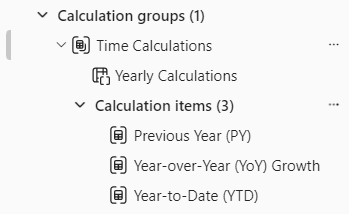

##### Apply a calculation group to measures
In this task, you will visualize how the calculation items affect measures in a visual.
1. Switch to **Report** view.
2. At the bottom of the canvas, select the **Overview** tab.
3. Select the matrix visual already created in the canvas and drag the **Yearly Calculations** calculation column from the **Data** pane to the **Columns** field in the **Visualizations** pane.

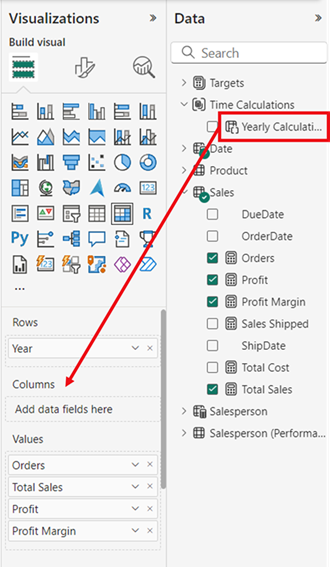

4. Observe that now the matrix has a set of sales figures for each calculation item.

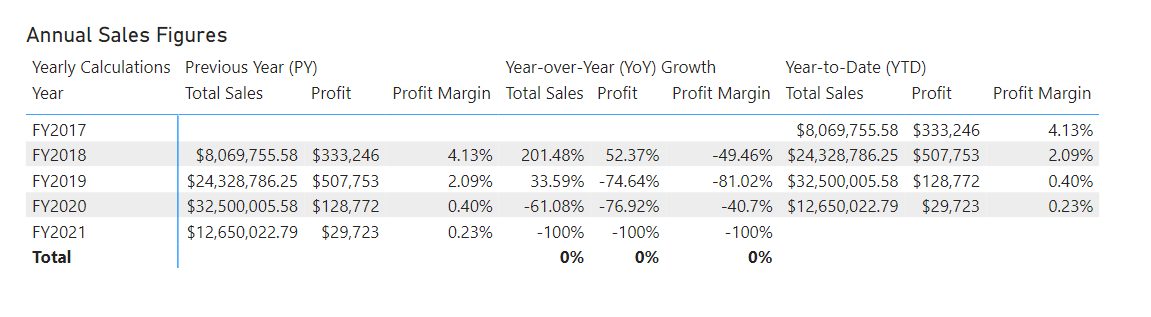

> Having all this information in one visual at once can be hard to read and therefore, it would be convenient to limit the visual to one sales figure at a time. In order to do that, we can use a field parameter.

#### Create field parameters
In this task, you will create field parameters to change visuals.
1. Select the **Modeling** tab in the top ribbon, then expand the **New parameter** button and select **Fields**.

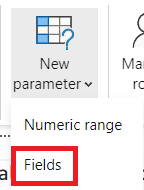

2. In the Parameters window, rename the parameter to **Sales Figures**, verify that the option Add slicer to this page is checked, and add the following fields from the Sales table:
    * Total Sales
    * Profit
    * Profit Margin
    * Orders

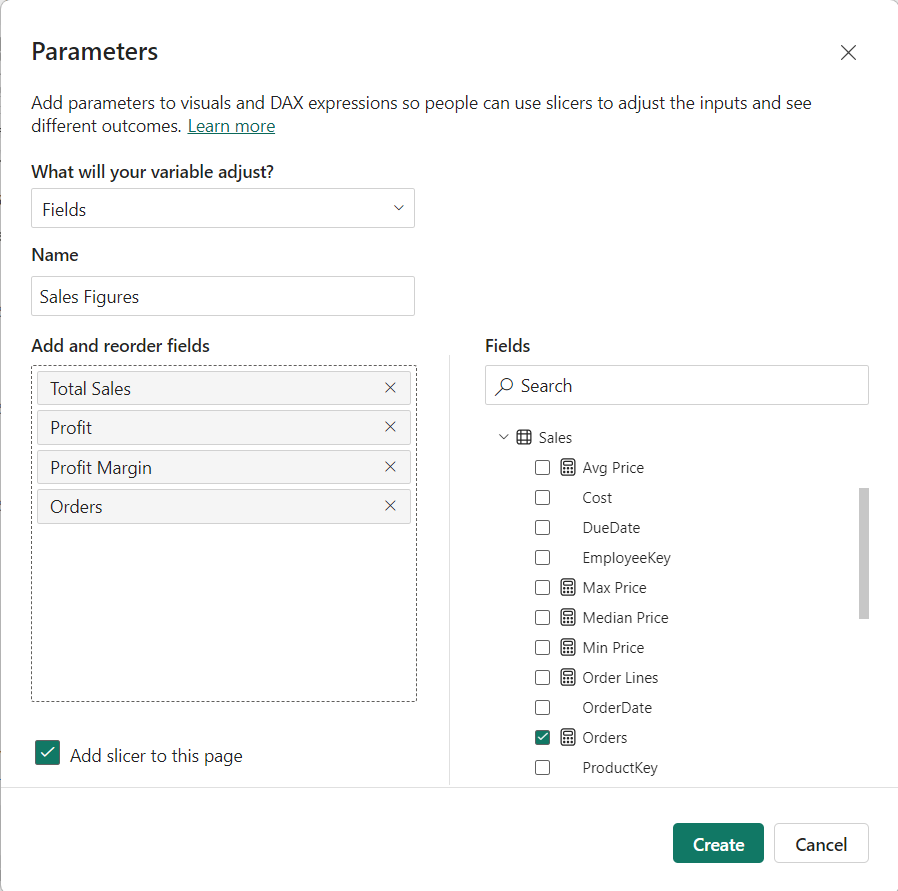

3. Select **Create**.
4. Once the slicer is created, you can select the matrix and remove all fields from **Values** in the Visualizations pane and add instead the Sales Figures field parameter.

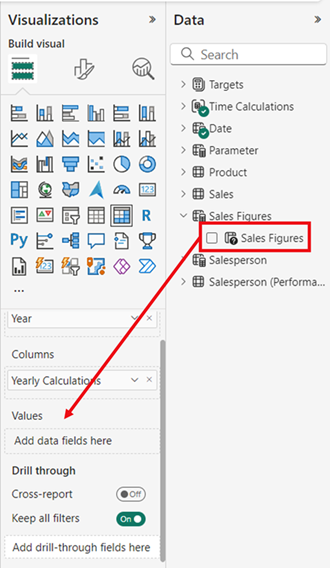

5. Check the different sales figures in the slicer and how the matrix changes when each of them is selected.
6. See how the Profit field is selected using the slicer for the Sales Figures field parameter. This is the same matrix from above, so you can see the three calculation items (PY, YoY, YTD) but only applied to Profit because of the slicer.

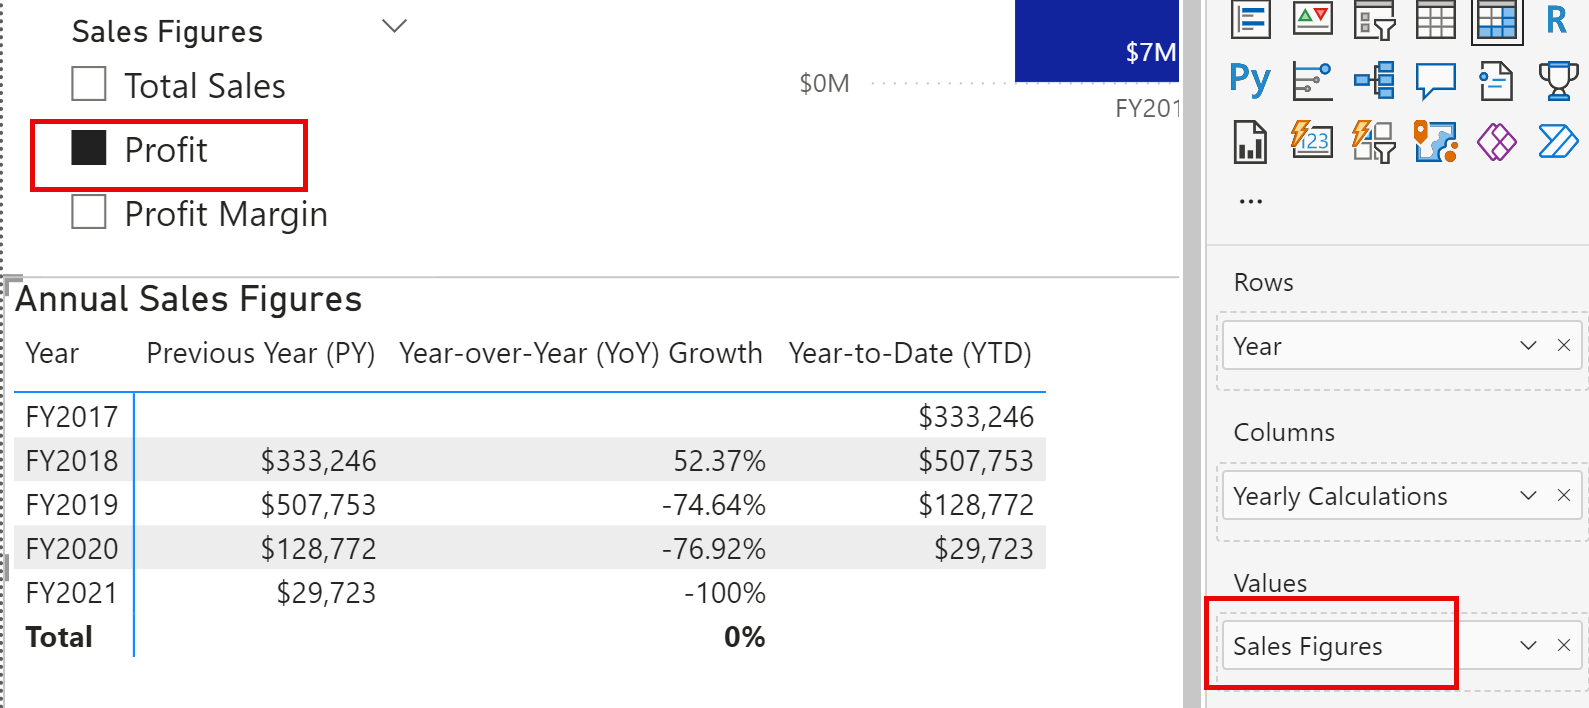

##### Edit field parameters
In this task, you will edit the **Sales Figures** field parameter by directly modifying its DAX expression.
1. Select the **Salesperson Performance** tab at the bottom of the canvas. Notice the clustered bar chart to switch the chart between Sales by Month and Target by Month.
> While creating the bookmark buttons allows you to change the visual type with each option, if you need to switch between many measures, you will have to create a bookmark button for each of them and that can be very time consuming. Instead, we can use a field parameter with all the measures we want to analyze and quickly switch between them.

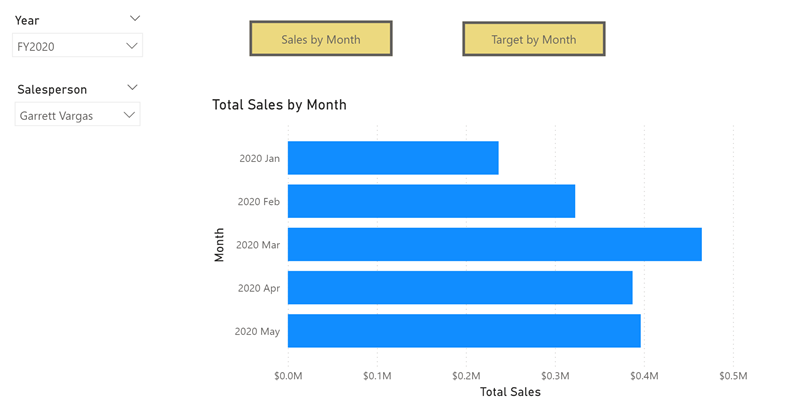

2. Select the bar chart visual and replace the **Total Sales** field in **X-axis** with the **Sales Figures** field parameter.
3. Create a **Slicer** visual and drag the **Sales Figures** parameter to the **Field** area.

For this visual you still need to evaluate the Target by Month, which is not in the field parameter.
1. Select the **Sales Figures** parameter in the Data pane and add the Target field in the parameter’s DAX expression as below:

```dax
Sales Figures = {
 ("Total Sales", NAMEOF('Sales'[Total Sales]), 0),
 ("Profit", NAMEOF('Sales'[Profit]), 1),
 ("Profit Margin", NAMEOF('Sales'[Profit Margin]), 2),
 ("Orders", NAMEOF('Sales'[Orders]), 3),
 ("Target", NAMEOF('Targets'[Target]), 4)
}
```
2. Commit the changes and verify that the visual changes as you select the different Sales figures.
3. Delete the bookmark buttons, and observe the final state of the report page.

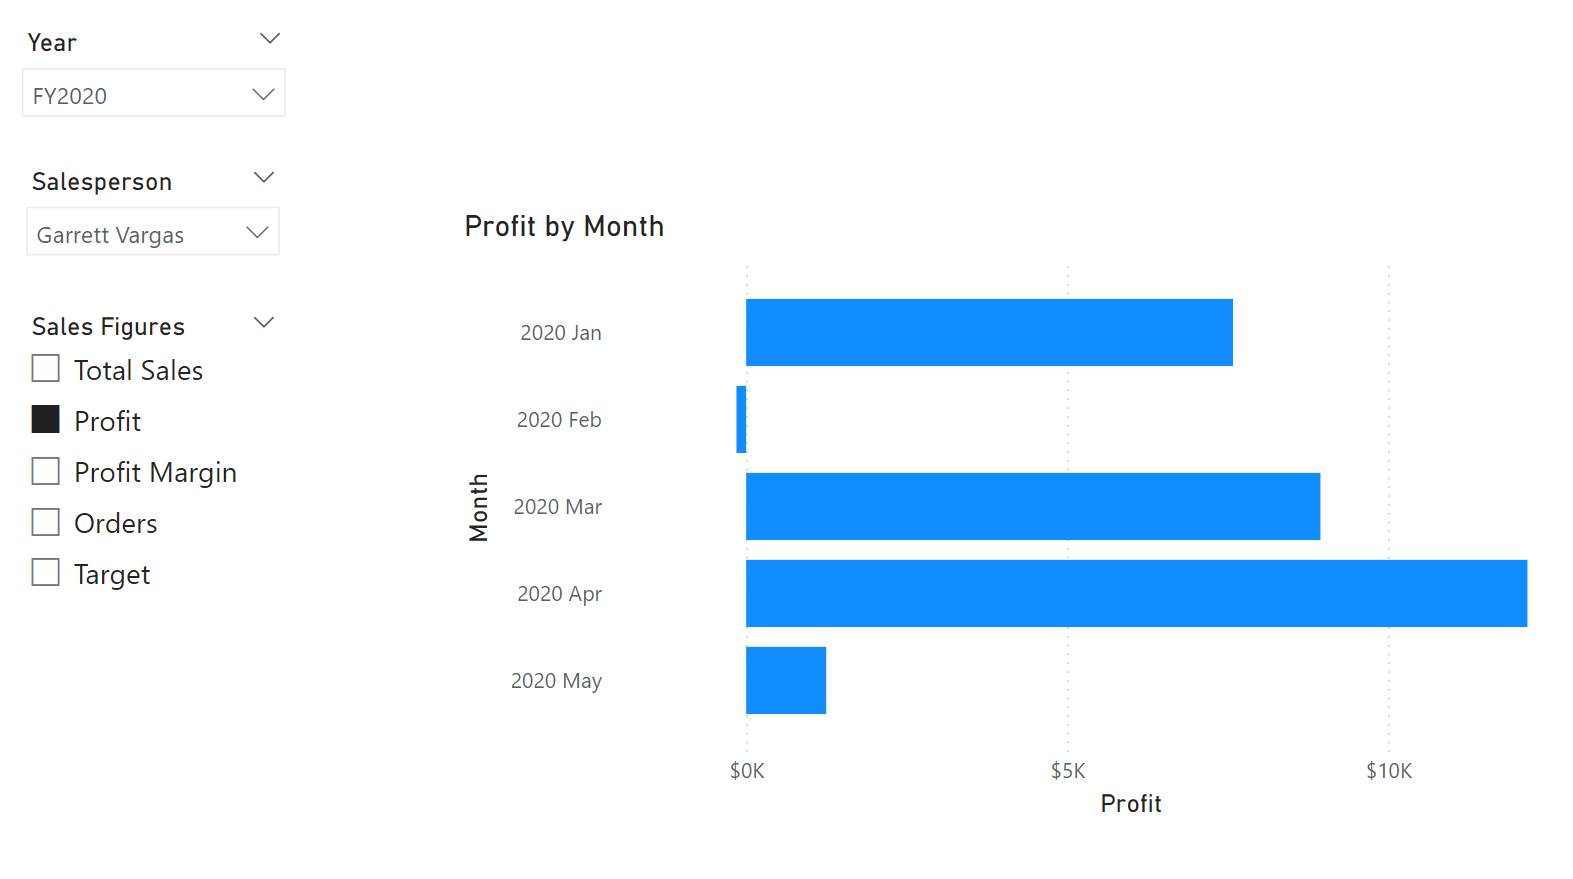

#### Lab complete
To finish the exercise, close Power BI Desktop - no need to save the file.

### **Module assessment**

#### 1. An analytics team builds a new semantic model in Microsoft Fabric with all data stored in a lakehouse. Which storage mode should they choose as the default for this model?

A) Import mode, because it provides the fastest query performance. \
**B) Direct Lake mode, because it reads Delta tables directly from OneLake without importing data.** \
C) DirectQuery mode, because it queries the source in real time.

#### 2. A company has 60 base measures in a semantic model and needs Year-to-Date, Quarter-to-Date, and Month-to-Date versions of each. What should a model designer implement to avoid creating 180 additional measures?

**A) A calculation group with time intelligence calculation items that use `SELECTEDMEASURE()`.** \
B) DAX variables to store intermediate results and reduce repeated calculations. \
C) Aggregations with pre-summarized tables at the monthly, quarterly, and yearly grain.

#### 3. A model designer needs to use Tabular Editor for external model development and deploy through CI/CD pipelines. Which setting is a prerequisite for XMLA endpoint read/write access?

**A) Large semantic model storage format.** \
B) OneLake integration. \
C) Query scaleout.

#### 4. A model designer enables the Assume referential integrity setting on a relationship between a fact table and a dimension table in a Direct Lake model. What is the performance benefit of this setting?

**A) The engine uses `INNER` joins instead of `LEFT OUTER` joins, which reduces the number of rows processed.** \
B) The engine caches relationship metadata so that subsequent queries skip relationship evaluation. \
C) The engine creates an index on the foreign key column to speed up relationship lookups.

#### 5. A semantic model has a fact table with 150 million rows. Report users primarily view monthly and quarterly summaries by region. Which design pattern improves query performance for these summary-level visuals?

**A) Aggregation tables that store precalculated totals at the monthly and quarterly grain.** \
B) Calculation groups with time intelligence calculation items. \
C) Bi-directional filtering between the fact and dimension tables.

## **Optimize semantic model performance**

### **Introduction**

#### Why Semantic Model Performance Matters
Semantic models power:

✅ Power BI Reports \
✅ Dashboards \
✅ Copilot \
✅ AI Experiences \
✅ Data Agents

When performance is good:
* Reports load quickly
* Users trust the data
* Copilot responds faster
* AI experiences work reliably

When performance is poor:

❌ Slow dashboards \
❌ Long report rendering times \
❌ Query timeouts \
❌ Poor user experience \
❌ AI response failures
#### Common Causes of Poor Performance
Performance problems can originate from:
##### DAX Calculations
Examples:
```
Complex `SUMX`
Nested `FILTER`
Expensive `LOOKUPVALUE`
```
##### Data Model Design
Examples:
* High-cardinality columns
* Too many calculated columns
* Poor relationships
##### Report Design
Examples:
* Too many visuals
* Too much data on one page
* Unoptimized filters
##### Large Fact Tables
Examples:
* Millions of rows
* Billions of transactions

without aggregations.
#### Performance Optimization Goals
The objective is not simply to know:
> The report is slow

but rather:
* What is slow?
* Why is it slow?
* How do we fix it?
#### Typical Troubleshooting Workflow
> Slow Report → Performance Analyzer → Identify Bottleneck → Optimize DAX → Optimize Model → Add Aggregations → Retest

#### Three Major Optimization Areas
This module focuses on:
##### 1. Diagnose Performance Problems
Using:
> Performance Analyzer

##### 2. Optimize DAX
Improve:
* Measures
* Calculations
* Iterator usage
##### 3. Optimize Data Model
Reduce:
* Cardinality
* Memory usage
* Query complexity
#### Performance Analyzer
##### Purpose
Performance Analyzer helps identify:

✅ Slow visuals \
✅ Query duration \
✅ Rendering time \
✅ DAX execution time
##### Questions it Answers
> Which visual is slow? \
> How long does each visual take? \
> Is the problem DAX or rendering?

#### DAX Optimization
Many performance problems originate from poorly designed calculations.
##### Prefer Aggregations
Use:
```dax
SUM()
```
instead of:
```dax
SUMX()
```
when possible.
##### Why?
Aggregation functions are faster because:
> Column-Based

rather than:
> Row-by-Row

processing.
##### Use Variables
Example:
```dax
VAR Revenue =
    SUM(Sales[Amount])

RETURN
Revenue
```
Benefits:

✅ Better readability \
✅ Reduced repeated calculations \
✅ Better maintainability
##### Avoid Expensive Functions
Examples:
```dax
LOOKUPVALUE()
SEARCH()
```
can be slow on large datasets.

Prefer:
```dax
RELATED()
```
when relationships exist.
#### Cardinality Optimization
##### What is Cardinality?
Number of unique values in a column.
##### Low Cardinality
**Region**
> East \
> West \
> North \
> South

4 unique values.

✅ Efficient
##### High Cardinality
> Customer Email

millions of unique values.

❌ Expensive
#### Why Cardinality Matters
High cardinality:

✅ Uses more memory \
✅ Increases model size \
✅ Slows queries
##### Reduce Cardinality
Examples:

Remove:
> GUIDs \
> Transaction IDs \
> Unused Keys

if not needed for reporting.
#### Aggregations
##### What Are Aggregations?
Pre-calculated summary tables.
##### Example
Instead of reading:
> 500 Million Transactions

query:
> Monthly Sales by Region

aggregation table.
##### Benefits
✅ Faster queries \
✅ Less data scanning \
✅ Better scalability
##### Example
Instead of:
> Daily Sales Detail

for every query,

store:
> Monthly Totals

for common reporting needs.
#### Enterprise Retail Example
Suppose:
> Executive Dashboard

requires:
> Monthly Revenue

not:
> Individual Sales Transactions

Use aggregations.
#### AI and Performance
Copilot and AI rely on the same semantic model.

Slow models affect:

✅ Reports \
✅ Dashboards \
✅ AI Queries \
✅ Copilot Responses
##### Faster Model = Better AI
Optimization improves:
> User Experience + Copilot Experience

at the same time.
#### Most Common Optimization Targets
##### DAX
✅ Simplify calculations \
✅ Use measures instead of calculated columns \
✅ Use variables
##### Model
✅ Reduce cardinality \
✅ Remove unused columns \
✅ Use star schema
##### Query Performance
✅ Aggregations \
✅ Efficient relationships \
✅ Better storage mode choices
#### Performance Diagnosis Checklist
##### Step 1
Use:
> Performance Analyzer

##### Step 2
Find:
> Slow Visuals

##### Step 3
Review:
> DAX Queries

##### Step 4
Evaluate:
> Data Model Design

##### Step 5
Implement:
> Aggregations

if necessary.
#### Exam Quick Facts
✅ Semantic model performance impacts:
* Reports
* Dashboards
* Copilot
* AI experiences

✅ Performance Analyzer is the primary diagnostic tool \
✅ Common bottlenecks:
* DAX calculations
* High cardinality
* Large datasets
* Poor model design

✅ Aggregation functions are generally faster than iterator functions \
✅ High-cardinality columns increase:
* Memory usage
* Query duration
* Model size

✅ Aggregations improve performance for large fact tables \
✅ Performance optimization should focus on:
* DAX
* Cardinality
* Aggregations
#### Memory Trick
> Diagnose → Optimize → Aggregate

or
> Performance = DAX + Model + Aggregations

⭐ Most exam-focused takeaway:

Use Performance Analyzer first to identify the bottleneck before attempting optimization.

### **Use Performance analyzer to diagnose issues**

#### What is Performance Analyzer?
**Performance Analyzer** is Power BI's primary tool for finding performance bottlenecks in reports.

It helps answer:

✅ Which visual is slow? \
✅ Why is it slow? \
✅ Is the issue DAX, rendering, or DirectQuery? \
✅ Which visual should be optimized first?
#### Why Use Performance Analyzer?
Without it:
> Report is slow

But you don't know why.

With Performance Analyzer:
> Slow Report → Find Slow Visual → Find Slow Component → Optimize Correctly

#### Where to Find It
##### In Power BI Desktop
> Optimize Ribbon → Performance Analyzer

##### In Power BI Service
> Edit Report → View → Performance Analyzer

#### How to Use Performance Analyzer
##### Step 1
Open:
> Performance Analyzer

##### Step 2
Click:
> Start Recording

##### Step 3
Interact with report:

✅ Refresh page \
✅ Change slicers \
✅ Navigate pages \
✅ Filter visuals
##### Step 4
Review timing results.
##### Step 5
Click:
> Stop

when enough data is collected.
#### Best Practice
Before testing:

✅ Clear visual cache
##### Why?
Cached results can make visuals appear faster than they really are.

A clean cache gives:

✅ Realistic measurements \
✅ Accurate diagnostics
#### Analyze a Single Visual
While recording:

Click:
> Analyze This Visual

on the visual.
##### Benefit
Measure one visual without refreshing the entire page.
#### Performance Metrics
Performance Analyzer breaks load time into categories.
##### 1. DAX Query
**Measures**

Time spent:
> Sending Query → Semantic Model → Receiving Results

**Most Common Bottleneck**
* Expensive measures
* Slow calculations
* Large scans

**If DAX Time Is High**

Look for:

✅ Complex DAX \
✅ Large fact tables \
✅ Inefficient calculations \
✅ Missing aggregations
##### 2. Visual Display
**Measures**

Time spent rendering the visual.

Examples:

✅ Charts \
✅ Maps \
✅ Images \
✅ Geocoding

**If Display Time Is High**

Look for:

✅ Too much data shown \
✅ Complex visuals \
✅ Maps and custom visuals
##### 3. DirectQuery
**Measures**
* Time spent querying external sources.
* Applicable only when using:
    > DirectQuery

##### If DirectQuery Time Is High
Investigate:

✅ Source database \
✅ Query folding \
✅ External performance
##### 4. Other
**Measures**

Background processing.

Examples:

✅ Waiting on other visuals \
✅ Network delays \
✅ Query preparation \
✅ Internal processing
#### Timing Categories Summary
| Metric         | Meaning                  |
| -------------- | ------------------------ |
| DAX Query      | Semantic model execution |
| Visual Display | Rendering visual         |
| DirectQuery    | Source database queries  |
| Other          | Background processing    |

#### Understanding Total Duration
> Duration (ms)

represents:
> Start → Finish

for the visual.
##### Exam Tip
Total Duration may include:

✅ Waiting time \
✅ Queued operations \
✅ Background overhead

Not only pure execution time.
#### Diagnosing the Bottleneck
Focus first on the largest contributor.
##### Scenario 1
> DAX = 4800 ms \
> Display = 200 ms

Problem:

✅ Semantic model \
✅ Measures \
✅ Data model
##### Scenario 2
> DAX = 200 ms \
> Display = 4500 ms

Problem:

✅ Visual rendering \
✅ Too much displayed data
##### Scenario 3
> DirectQuery = 6000 ms

Problem:

✅ Source database \
✅ Query performance
#### Exporting DAX Queries
Performance Analyzer can capture the actual DAX query.
##### Run in DAX Query View
Automatically opens:
> DAX Query View

with the query loaded.
##### Copy Query
Copies DAX to clipboard.
#### Why Export DAX?
Allows you to:

✅ Inspect query structure \
✅ Test optimizations \
✅ Analyze logic \
✅ Use external tools
#### DAX Query View
Use it to:

✅ Run queries \
✅ Examine results \
✅ Simplify logic \
✅ Debug measures
##### Copilot Tip
Copilot can help simplify queries.

Example prompt:
> Remove VARs and TOPN and simplify this query.

#### DAX Studio
##### What is DAX Studio?
A free external performance-analysis tool.
##### Why Use It?
Provides deeper diagnostics than Performance Analyzer.
##### Feature 1: Server Timings
Separates execution into:

**Formula Engine (FE)**

Handles:
> DAX Logic \
> Calculations

**Storage Engine (SE)**

Handles:
> Data Retrieval \
> Storage Access

**Benefit**

Shows exactly where time is spent.
##### Feature 2: Query Plan
Displays:

✅ Logical plan \
✅ Physical plan \
✅ Expensive operations

Useful for:

✅ Complex DAX measures \
✅ Iterator analysis \
✅ Optimization work
##### Feature 3: Model Metrics
Shows:

✅ Table Sizes \
✅ Column Sizes \
✅ Cardinality \
✅ Compression

Useful for finding:

✅ Large tables \
✅ High-cardinality columns \
✅ Memory issues
#### Typical Workflow
> Performance Analyzer → Find Slow Visual → Copy DAX Query → DAX Query View → DAX Studio → Optimize

#### Example Analysis
Suppose you find:
| Visual               | Total Time |
| -------------------- | ---------- |
| KPI                  | 80 ms      |
| Revenue Chart        | 200 ms     |
| Trend Chart          | 240 ms     |
| Customer Table       | 290 ms     |
| Product Detail Table | 4800 ms    |

##### Which Visual Needs Attention?
✅ Product Detail Table
##### Why?
> 4800 ms

is dramatically larger than the rest.
#### Exam Scenario
##### Product Detail Table
| Metric         | Value   |
| -------------- | ------- |
| DAX Query      | 4500 ms |
| Visual Display | 300 ms  |

Conclusion:

✅ DAX issue \
❌ Rendering issue \
❌ Visual issue

Next Step:
* Export DAX Query and analyze.
#### Performance Testing Best Practices
##### 1. Clear Cache
Before every test.
##### 2. Change One Variable
Only modify:
> One Measure \
> One Visual \
> One Filter

at a time.
##### 3. Use Real Data
Don't test using:
> 1,000 rows

if production contains:
> 10 million rows
##### 4. Repeat Tests
* Performance varies.
* Run multiple measurements.
##### 5. Measure Before and After
Document:
> Original Time \
> Optimized Time

to verify improvement.
#### Troubleshooting Process
> Slow Report → Performance Analyzer → Find Slow Visual → Identify Category → Export DAX Query → Analyze in DAX Studio → Optimize Model

#### Exam Quick Facts
✅ Performance Analyzer is the primary diagnostic tool \
✅ Found on the Optimize ribbon \
✅ Must click:
* Start Recording to begin measurement

✅ Clear visual cache before testing \
✅ Main timing categories:
* DAX Query
* Visual Display
* DirectQuery
* Other

✅ DAX Query is the most common bottleneck \
✅ Queries can be exported using:
* Run in DAX Query View
* Copy Query

✅ DAX Studio provides:
* Server Timings
* Query Plans
* Model Metrics

✅ Compare visuals relative to each other \
✅ Focus on the largest bottleneck first
#### Memory Trick
##### Performance Analyzer Workflow
> Record → Measure → Identify → Optimize

##### Exam Rule ⭐
If a visual is slow, first use Performance Analyzer to determine whether the bottleneck is:
* DAX Query
* Visual Display
* DirectQuery
* Other

Only after identifying the bottleneck should you begin optimization.

### **Optimize DAX calculations**

#### Why Optimize DAX?
After using **Performance Analyzer** and identifying a slow DAX query, the next step is DAX optimization.

Poor DAX can cause:

❌ Slow reports \
❌ Long refreshes \
❌ Copilot timeouts \
❌ Slow AI responses \
❌ Poor user experience
#### Key DAX Optimization Techniques
This unit focuses on:
* Variables (`VAR`)
* `FILTER` vs Column Filters
* `KEEPFILTERS`
* Iterator Function Costs
* Avoiding Expensive Patterns
* Moving Logic to the Data Layer
#### 1. Use Variables (VAR)
##### Why Variables Matter
Variables store a calculation once and reuse it.

Without variables:
```dax
Sales YoY Growth % =
DIVIDE(
    (
        [Sales]
        -
        CALCULATE(
            [Sales],
            PARALLELPERIOD(
                'Date'[Date],
                -12,
                MONTH
            )
        )
    ),
    CALCULATE(
        [Sales],
        PARALLELPERIOD(
            'Date'[Date],
            -12,
            MONTH
        )
    )
)
```
The same calculation runs twice.
##### Optimized Version
```dax
Sales YoY Growth % =
VAR SalesPriorYear =
    CALCULATE(
        [Sales],
        PARALLELPERIOD(
            'Date'[Date],
            -12,
            MONTH
        )
    )
RETURN
    DIVIDE(
        [Sales] - SalesPriorYear,
        SalesPriorYear
    )
```
##### Benefits
✅ Expression evaluated once \
✅ Faster execution \
✅ Easier debugging \
✅ Better readability
##### Exam Tip
```dax
VAR
RETURN
```
is one of the most important DAX optimization techniques.
#### Variable Debugging Trick
During troubleshooting:
```dax
RETURN SalesPriorYear
```
instead of the full expression.

This helps inspect intermediate values.
#### 2. `FILTER` vs Column Filters
A major exam topic.
##### Expensive Version
```dax
High Value Sales =
CALCULATE(
    [Total Sales],
    FILTER(
        Sales,
        Sales[Amount] > 1000
    )
)
```
##### Why Expensive?
```dax
FILTER()
```
iterates:
> Every Row

in the Sales table.

Large tables:

❌ Slow \
❌ Memory intensive
##### Better Version
```dax
High Value Sales =
CALCULATE(
    [Total Sales],
    Sales[Amount] > 1000
)
```
##### Why Better?
Column predicates are optimized internally.

✅ Faster \
✅ Less iteration \
✅ Better scalability
##### Exam Rule
If the condition involves:
> One Column

prefer:
```dax
Sales[Amount] > 1000
```
instead of:
```dax
FILTER()
```
#### 3. `KEEPFILTERS`
##### Purpose
Adds filters without replacing existing filters.
##### Example
```dax
Online Sales =
CALCULATE(
    [Total Sales],
    KEEPFILTERS(
        Sales[Channel] = "Online"
    )
)
```
##### What Happens?
If a slicer already filters:
> Channel

`KEEPFILTERS` preserves that context.
##### Exam Difference
| Function    | Behavior                   |
| ----------- | -------------------------- |
| FILTER      | Creates table iteration    |
| KEEPFILTERS | Preserves existing filters |

#### 4. Manage Iterator Costs
Iterator functions:
```dax
SUMX
AVERAGEX
COUNTX
MAXX
```
evaluate:
> Row by Row

##### Example
```dax
Weighted Avg Price =
SUMX(
    Sales,
    Sales[Quantity]
        *
    Sales[UnitPrice]
)
/
SUM(
    Sales[Quantity]
)
```
##### Cost
For:
> 1,000 rows

Fine ✅

For:
> 100 million rows

Potential bottleneck ❌
#### Prefer Aggregation Functions
##### Better
```dax
Total Revenue =
SUM(
    Sales[LineTotal]
)
```
##### Why?
Aggregation functions use storage engine optimizations.

✅ Faster \
✅ Less CPU \
✅ Better scalability
#### Iterator vs Aggregation
| Function Type | Example | Performance |
| ------------- | ------- | ----------- |
| Aggregation   | `SUM()`   | Faster      |
| Iterator      | `SUMX()`  | Slower      |

##### Exam Rule
Use:
```dax
SUM()
AVG()
MAX()
MIN()
```
whenever possible.

Use:
```dax
SUMX()
AVERAGEX()
```
only when row-level logic is needed.
#### 5. Avoid Expensive DAX Patterns
##### Pattern #1
**Bad**
```dax
COUNTROWS(
    FILTER(
        Sales,
        Sales[Amount] > 1000
    )
)
```
**Better**
```dax
CALCULATE(
    COUNTROWS(Sales),
    Sales[Amount] > 1000
)
```
**Why?**

Avoids iterating the full table.
##### Pattern #2
Nested `CALCULATE`

**Bad**
```dax
CALCULATE(
    CALCULATE(
        CALCULATE(...)
    )
)
```
**Problems**

❌ Multiple context transitions \
❌ Harder optimization \
❌ Difficult maintenance

**Better**

Break logic into:
> Measure A \
> Measure B \
> Measure C

and reuse them.
##### Pattern #3
Mixing Aggregation Grains

Example:
> Detail-Level Values + Grand Totals

inside one calculation.

**Better**

Use variables.
```dax
Pct of Total =
VAR TotalSales =
    CALCULATE(
        [Total Sales],
        REMOVEFILTERS()
    )
RETURN
    DIVIDE(
        [Total Sales],
        TotalSales
    )
```
**Why?**

Calculates:
```
TotalSales
```
once.

Reuses result.
#### 6. Move Calculations to the Data Layer
##### Principle
Not every calculation belongs in DAX.
##### Better Locations
* Option 1: Power Query

Example:
> First Name + Last Name

Create during loading.
* Option 2: SQL Source

Example:
```sql
SELECT
    FirstName + ' ' + LastName
```
**Benefits**

✅ Faster queries \
✅ Smaller models \
✅ Better refresh performance
#### DAX Calculated Columns
Use only when you need:

✅ DAX-specific functions \
✅ Relationship-dependent logic \
✅ Time intelligence dependencies
##### Exam Tip

Prefer:
> Source → Power Query → DAX

for transformation logic.
#### `RELATED` vs `LOOKUPVALUE`
Another common optimization rule.
##### Faster
```dax
RELATED()
```
Uses relationships.
##### Slower
```dax
LOOKUPVALUE()
```
Performs lookups.
##### Exam Rule
If a relationship exists:

✅ `RELATED()` \
❌ `LOOKUPVALUE()`
#### DAX and AI
Copilot generates DAX behind the scenes.

Slow DAX affects:

✅ Reports \
✅ Dashboards \
✅ Copilot \
✅ AI Agents
##### Example
A measure taking:
> 5 Seconds

for users also takes:
> 5 Seconds

for Copilot.
##### Result
Poor DAX can cause:

❌ AI query timeouts \
❌ Slow natural-language responses \
❌ Reduced Copilot effectiveness
#### Optimization Priority Checklist
##### First
Use:
> Performance Analyzer

Then

Optimize:
1. Repeated calculations
2. `FILTER` scans
3. Iterator overuse
4. Nested `CALCULATE`
5. High grain mismatches
##### Finally
Move static calculations upstream.
#### Exam Quick Facts
✅ Use:
* `VAR`
* `RETURN`

to eliminate repeated calculations

✅ Variables improve:
* Performance
* Readability
* Debugging

✅ Prefer:
    ```dax
    Sales[Amount] > 1000
    ```
    over:
    ```dax
    FILTER(...)
    ```
when possible \
✅ `KEEPFILTERS` preserves existing filter context \
✅ Iterator functions:
* `SUMX`
* `AVERAGEX`
* `COUNTX`

can be expensive on large tables

✅ Aggregation functions:
* `SUM`
* `AVG`
* `MAX`

are usually faster \
✅ Prefer `RELATED` over `LOOKUPVALUE` \
✅ Avoid:
* `COUNTROWS(FILTER(...))`
* Deeply nested `CALCULATE`
* Unnecessary iterators

✅ Move static transformations to:
* Power Query
* Source SQL
#### Memory Trick
##### DAX Optimization Pyramid
> `VAR` → Avoid `FILTER` → Minimize Iterators → Use `RELATED` → Move Logic Upstream

⭐ Most tested rule:

**Use VAR to calculate once and reuse many times**. This improves both performance and readability.

### **Reduce cardinality for better performance**

#### What is Cardinality?
**Cardinality** = Number of unique values in a column.

Examples:
##### Low Cardinality
Region
* East
* West
* North
* South

Only 4 unique values.

✅ Good compression \
✅ Faster queries
##### High Cardinality
* CustomerID
* TransactionID
* GUID
* Email Address

Millions of unique values.

❌ Poor compression \
❌ Larger model \
❌ Slower queries
#### Why Cardinality Matters
Power BI uses the:
##### VertiPaq Engine
VertiPaq compresses data:
> Column by Column

Columns with fewer unique values:

✅ Compress better \
✅ Use less memory \
✅ Query faster
#### Impact of High Cardinality
##### 1. Larger Model Size
More distinct values require:

✅ More storage \
✅ More memory

**Example**
| Column     | Unique Values |
| ---------- | ------------- |
| Region     | 4             |
| CustomerID | 5,000,000     |

`CustomerID` consumes significantly more memory.
##### 2. Slower Queries
The engine must process:
> More Distinct Values

during:

✅ Filtering \
✅ Grouping \
✅ Sorting \
✅ Aggregation
##### Exam Tip

High cardinality impacts:
* Memory
* Refresh Speed
* Query Performance
#### Common High-Cardinality Columns
##### GUIDs
Example:
```
5F6A-9E3D-8C11...
```
Millions of unique values.

**Usually Remove If**

❌ Not used in reports \
❌ Not used in relationships
##### Timestamps
Example:
```
2025-08-22 10:15:23.764
```
Every row may be unique.

**Better**

Convert to:

`2025-08-22`

(Date only)

**Benefits**

✅ Massive cardinality reduction \
✅ Better compression
#### Free-Text Columns
Examples:
* Comments
* Descriptions
* Notes

Often unique per row.

**Compression**

Poor ❌ \
Memory usage High ❌
##### Unique Identifiers
Examples:
* Invoice Number
* Order Number
* Session ID

Often have:
> One Unique Value Per Row

**Remove If Not Needed**

✅ Smaller model \
✅ Better performance
#### Identifying High Cardinality
Look for:

✅ Large text columns \
✅ GUIDs \
✅ High precision timestamps \
✅ Unique IDs \
✅ Description fields
#### Tools to Identify Them
##### Model View
Review:
* Tables
* Columns
* Statistics
##### Power Query Preview
Review:
* Distinct Values

during transformation.
#### Cardinality Reduction Strategies
##### Strategy 1: Remove Unused Columns
Most important technique.

**Question**

Does the column participate in:

✅ Reports \
✅ Measures \
✅ Relationships \
✅ Security \
?

If not:
> Delete It

**Example**

Remove:
> GUID \
> Audit Columns \
> Internal IDs

that aren't used.

**Exam Term**

Known as:
> Vertical Filtering

#### Vertical Filtering
##### Definition
Removing unnecessary columns.
##### Effect
> Fewer Columns → Smaller Model → Faster Queries

##### Strategy 2: Reduce Time Precision
Convert:

`DateTime`

to

`Date`

when time isn't required.

**Example**

Before:
```
2025-01-01 10:15:23
2025-01-01 10:15:24
2025-01-01 10:15:25
```
Many unique values.

After:
```
2025-01-01
2025-01-01
2025-01-01
```
Only one unique value.

**Benefit**

Huge cardinality reduction.
##### Strategy 3: Bucket Continuous Values
Convert:
> Exact Values

into ranges.

**Example**

Age

Before:
```
18
19
20
21
22
...
```
After:
```
18-25
26-35
36-45
```
**Benefits**

✅ Fewer distinct values \
✅ Better compression \
✅ Easier reporting
##### Strategy 4: Remove Unnecessary Rows
If users only need:
> Last 2 Years

Don't load:
> Last 10 Years

**Exam Term**

Known as:
> Horizontal Filtering

#### Horizontal Filtering
##### Definition
Reducing row counts.
##### Example
> 100M Rows → 20M Rows

Benefits:

✅ Faster refresh \
✅ Smaller model \
✅ Better performance
#### Vertical vs Horizontal Filtering
| Technique            | Removes |
| -------------------- | ------- |
| Vertical Filtering   | Columns |
| Horizontal Filtering | Rows    |

##### Exam Favorite
Remember:
* Vertical = Columns
* Horizontal = Rows
##### Strategy 5: Optimize Data Types
**Numeric > Text**

VertiPaq compresses numeric values better.

**Example**

Instead of:
```
SO123456
```
store:
```
123456
```
when possible.

**Benefits**

✅ Better compression \
✅ Smaller model \
✅ Faster processing
#### Value Encoding vs Hash Encoding
##### Numeric Columns
Use:
> Value Encoding

✅ More efficient
##### Text Columns
Use:
> Hash Encoding

✅ Less efficient
##### Exam Tip
Numeric data compresses better than text.
#### Power Query vs DAX Columns
##### Preferred
Power Query Computed Column

✅ Better compression \
✅ Processed before load
##### Less Preferred
DAX Calculated Column

✅ Evaluated after load \
✅ Usually less efficient
##### Exam Rule
Use:
> Power Query

before:
> DAX Calculated Columns

for transformations.
#### Cardinality Trade-Offs
Reducing cardinality can reduce detail.

Example:
##### Before
> Exact Timestamp

##### After
> Date Only

Benefit:

✅ Faster

Cost:

❌ No hourly analysis
#### Questions Before Reducing Cardinality
Ask:
1. Does any report need this detail?
2. Does any measure depend on it?
3. Is it used in Row-Level Security (RLS)?

If yes:

Be cautious.
#### Composite Model Approach
Sometimes users need:

✅ Fast summaries \
AND \
✅ Detailed drillthrough
##### Solution
Use:
> Import + DirectQuery

##### Example
Summary reports:
> Import Mode

Drillthrough detail:
> DirectQuery

#### Performance Impact Summary
##### Low Cardinality
✅ Better compression \
✅ Smaller models \
✅ Faster refreshes \
✅ Faster queries
##### High Cardinality
❌ Larger models \
❌ More memory \
❌ Slower refreshes \
❌ Slower queries
#### Exam Quick Facts
✅ Cardinality = Number of unique values \
✅ VertiPaq compresses low-cardinality columns better \
✅ High cardinality increases:
* Memory usage
* Model size
* Query time

✅ Common high-cardinality columns:
* GUIDs
* Timestamps
* Free text
* IDs

✅ Vertical Filtering = Remove columns \
✅ Horizontal Filtering = Remove rows \
✅ Truncate datetime to date when time isn't needed \
✅ Bucket continuous values into ranges \
✅ Numeric columns compress better than text \
✅ Prefer Power Query columns over DAX calculated columns \
✅ Composite models can balance performance and detail access
#### Memory Trick
##### Cardinality Optimization Formula
> Remove Columns + Reduce Precision + Remove Rows + Use Better Data Types → **Faster Semantic Model**

##### Exam Favorite ⭐
* Vertical Filtering = Remove Columns
* Horizontal Filtering = Remove Rows

This distinction is frequently tested in Power BI and Fabric exams.

### **Implement aggregations**

#### What are Aggregations?
**Aggregations** are pre-calculated summary tables that store data at a higher level (grain).

Instead of querying:
> 1 Billion Transaction Rows

the model queries:
> Monthly Sales by Region

and returns results much faster.
#### Why Aggregations Matter
Even if you have:

✅ Optimized DAX \
✅ Star Schema \
✅ Reduced Cardinality

large fact tables can still be slow.

Aggregations help by reducing how much detailed data must be scanned.
#### How Aggregations Work
Without Aggregations:
> Report → Fact Table (500 Million Rows) → Result

With Aggregations:
> Report → Aggregation Table (Thousands of Rows) → Result

Only if needed:
> Aggregation Miss → Detail Table

#### When Aggregations Help
Use aggregations when all three conditions exist:
##### 1. Large Fact Tables
Examples:
> Hundreds of Millions \
> Billions of Rows

##### 2. Common Summary Queries
Users usually ask:
* Sales by Month
* Sales by Region
* Sales by Category

rather than:
> Single Transaction Details

##### 3. DirectQuery or Composite Models
DirectQuery can be slow because every query hits the source.

Aggregations provide:

✅ In-memory performance
##### Exam Memory
Aggregations are best when:
> Large Fact Tables + Summary Queries + DirectQuery

#### Executive Summary Analogy
Think of:
> Aggregation Table

as:
> Executive Summary

A user usually reads:
> Monthly Totals

instead of:
> Every Transaction

#### User-Defined Aggregations
##### What Are They?
Manual aggregations designed by the model developer.

You choose:

✅ Grain \
✅ Measures \
✅ Columns \
✅ Storage Mode
#### Implementation Steps
##### Step 1: Create Aggregation Table
**Example**:

Instead of:
> Transaction Level Sales

create:
> Daily Sales by Region

**Typical Aggregation**
* Date
* Region
* Category
* Total Sales
##### Step 2: Configure Aggregation Mapping
In Power BI Desktop:
> Model View → Manage Aggregations

Map aggregation columns to detail table columns.

**Common Aggregation Functions**

✅ Sum \
✅ Count \
✅ Min \
✅ Max \
✅ GroupBy
##### Step 3: Hide Aggregation Table
Users should not see:
```
Agg_Sales
```
**Why?**
* The query engine uses it automatically.
* Report authors don't need to know it exists.
##### Step 4: Configure Storage Modes
Aggregation Table:
> Import Mode

Detail Table:
> DirectQuery

**Result**
> Fast Aggregation Queries + Detailed Drillthrough

**Exam Tip**

User-defined aggregations require:

✅ Composite Model

Because:
* Aggregation = Import
* Detail Table = DirectQuery
#### Query Resolution Logic
##### Query Matches Aggregation
> Aggregation Table → Fast Response

##### Query Doesn't Match
> Aggregation Miss → DirectQuery Detail Table

#### Automatic Aggregations
##### What Are They?
Power BI automatically creates aggregation tables using:
* Machine Learning
* Query History
##### Advantage
* No manual aggregation design.
* Power BI learns usage patterns automatically.
#### How Automatic Aggregations Work
Power BI analyzes:
> Last 7 Days

of query activity.

Then:

✅ Creates aggregations \
✅ Updates aggregations \
✅ Removes unused aggregations
#### Enable Automatic Aggregations
##### Step 1
Open:
* Semantic Model Settings
##### Step 2
Enable:
* Automatic Aggregations Training
##### Step 3
* Run Refresh

Power BI evaluates query history and builds aggregation caches.
#### Requirements for Automatic Aggregations
✅ Premium Capacity \
✅ Premium Per User (PPU) \
✅ Fabric Capacity
##### Storage Requirement
Typically:
> DirectQuery

tables requiring acceleration.
##### Supported Sources
Examples:

✅ Azure SQL \
✅ Synapse \
✅ Databricks \
✅ Snowflake
#### User-Defined vs Automatic Aggregations
| Feature                | User-Defined | Automatic |
| ---------------------- | ------------ | --------- |
| Creator                | Developer    | Power BI  |
| Control                | Full         | Limited   |
| Flexibility            | High         | Adaptive  |
| Maintenance            | Manual       | Automatic |
| Based on Query History | No           | Yes       |

#### Combination Strategy
Many enterprise solutions use both.
##### User-Defined
For known workloads.

Example:
> Monthly Revenue

##### Automatic
For emerging workloads.

Example:
> Unexpected User Queries

#### Monitoring Aggregations
After implementation:

Verify they are being used.
##### Method 1: Refresh History
Shows:

✅ Aggregation memory usage \
✅ Aggregation activity
##### Method 2: Azure Log Analytics
Provides:

✅ Query hit rate \
✅ Aggregation usage \
✅ Missed aggregation analysis
#### Aggregation Hit
Query answered from:
> Aggregation Table

#### Aggregation Miss
Query falls back to:
> DirectQuery Detail Table

##### If Misses Are Frequent
Review:

✅ Aggregation grain \
✅ Query patterns \
✅ Dimensions used
#### Aggregations and Direct Lake
A common exam topic.
#### Direct Lake Already Fast
Direct Lake:
> OneLake → Delta Tables → Query Engine

avoids DirectQuery overhead.
##### Result
Many Direct Lake models don't need aggregations initially.
#### Add Aggregations to Direct Lake When
✅ Delta tables become very large \
✅ Summary-level queries dominate \
✅ Measurements prove a bottleneck exists
#### Exam Recommendation
For Direct Lake:
> Measure First

then:
> Add Aggregations Only If Needed

#### Aggregation Architecture Example
> Fact Sales (1 Billion Rows) → Aggregation Table (Monthly Sales) → Power BI Query → Fast Result

#### Best Practices
✅ Aggregate common query patterns \
✅ Hide aggregation tables \
✅ Use Import for aggregation tables \
✅ Use DirectQuery for detail tables \
✅ Monitor hit rates \
✅ Verify aggregation coverage \
✅ Start without aggregations in Direct Lake \
✅ Add only when performance measurements justify them
#### Exam Quick Facts
✅ Aggregations store precomputed summaries \
✅ Best suited for very large fact tables \
✅ Improve performance by avoiding detail-level scans \
✅ User-defined aggregations are configured manually \
✅ Automatic aggregations use machine learning \
✅ Automatic aggregations analyze query logs \
✅ User-defined aggregations require:
* Composite Models
* Import Aggregation Table
* DirectQuery Detail Table

✅ Common aggregation mappings:
* Sum
* Count
* Min
* Max
* GroupBy

✅ Aggregation tables should be hidden \
✅ Monitor effectiveness using:
* Refresh History
* Azure Log Analytics

✅ Direct Lake often performs well without aggregations \
✅ Add Direct Lake aggregations only after performance testing
#### Memory Trick
##### Aggregation Formula
> Large Fact Table + Summary Queries → Aggregation Table → Faster Reports

##### Most Tested Rule ⭐
User-Defined Aggregations = Import Aggregation Table + DirectQuery Detail Table (Composite Model).

### **Troubleshoot common performance issues**

#### Why Troubleshooting Matters
Real-world performance issues usually involve multiple problems:

❌ Slow DAX \
❌ High cardinality \
❌ Bad relationships \
❌ Too many visuals \
❌ DirectQuery bottlenecks

A systematic process helps find the true root cause quickly.
#### Performance Troubleshooting Workflow
##### Step 1: Identify the Bottleneck
Use:
> Performance Analyzer

Ask:

Is the problem:
- Visual?
- DAX?
- Data model?
- DirectQuery?
##### Step 2: Isolate the Root Cause
If DAX is slow:

✅ Run query in DAX Query View \
✅ Analyze in DAX Studio

If DAX is fast but visual is slow:

✅ Rendering issue \
✅ Too much data \
✅ Too many visuals
##### Step 3: Fix and Verify
Implement optimization.

Then:
> Measure Again

Never assume performance improved.
#### Core Troubleshooting Formula
> Symptom → Diagnosis → Fix → Verify

⭐ Very important exam concept.
#### Best Practice Analyzer (BPA)
##### What is BPA?
Best Practice Analyzer scans the semantic model and identifies:

✅ Performance issues \
✅ Design problems \
✅ DAX issues \
✅ Maintenance concerns
##### What BPA Can Detect
Examples:

✅ Unused columns \
✅ High-cardinality columns \
✅ Missing descriptions \
✅ Poor DAX patterns \
✅ Modeling issues
##### Memory Analyzer
Companion tool that shows:

✅ Table size \
✅ Column size \
✅ Relationship storage \
✅ Memory usage
##### When to Use BPA
Use:

✅ After building a model \
✅ After large changes \
✅ Before publishing \
✅ During optimization reviews
##### Exam Tip
* BPA is proactive.
* It finds issues before users complain.
#### Visual Performance Problems
A very common source of slow reports.
##### Problem 1: Too Many Measures
Example:
* Table Visual
* 20 Measures

**Result**
* Large DAX query.
* Slower rendering.

**Fix**

✅ Reduce measure count \
✅ Split into multiple visuals
##### Problem 2: Too Many Data Points
Examples:
* 50,000 row table
* 100,000-point scatter chart

**Result**
* Slow rendering.

**Fix**

Use:

✅ Top N filters \
✅ Drillthrough \
✅ Aggregated visuals
##### Problem 3: Too Many Visuals
Every visual generates its own queries.

**Example**
* 30 visuals

May generate:
* 30 separate query requests

**Recommendation**

Aim for:
```
≤ 8 visuals
```
per page.
##### Exam Tip
More visuals = More queries = Slower reports.
#### Relationship Problems
Poor relationship design is a major performance killer.
##### Problem 1: Ambiguous Paths
Example:
* Multiple active routes between tables

**Issues**

✅ Slower evaluation \
✅ Unexpected results \
✅ Difficult DAX

**Solution**

Use:

✅ Single active relationship \
✅ `USERELATIONSHIP` when needed
##### Problem 2: Bidirectional Filtering
Example:
> Table A ↔ Table B

**Issues**

❌ More filter propagation \
❌ More complexity \
❌ Poor scalability

**Recommendation**

Use:

✅ Single-direction filtering

whenever possible.
##### Problem 3: High Cardinality Keys
Examples:
* GUID
* UUID
* Complex text identifiers

**Issues**

✅ Bigger model \
✅ Slower relationships \
✅ More memory

**Solution**

Use:
> Integer Surrogate Keys

instead.
#### Filter Context Problems
Some DAX functions force the engine to process far more data.
##### Problem 1: `REMOVEFILTERS` / `ALL`
Example:
```dax
REMOVEFILTERS()
ALL()
```
**Effect**

Removes filters.

Engine evaluates:
> Entire Table

instead of filtered subsets.

**Recommendation**
* Use only when necessary.
* Limit scope.
##### Problem 2: Large Many-to-Many Relationships
Example:
> Customer → Bridge Table → Account

with millions of rows.

**Issues**

Every query must:

✅ Resolve relationships \
✅ Traverse large bridge tables

**Fix**

Consider:

✅ Alternative modeling \
✅ Consolidated dimensions \
✅ Role-playing dimensions
#### DirectQuery Troubleshooting
Sometimes DAX is not the problem. **The source system is.**
##### Problem 1: Query Folding Failure
**What is Query Folding?**

Power Query pushes transformations back to the source.

**Good**
> Transformation → SQL Server Executes

**Bad**
> SQL Sends Raw Data → Power BI Processes Locally

**Result**

Much slower.

**Fix**

Verify:

✅ Query Folding \
✅ Native Query
##### Problem 2: Slow Source Queries
Even when folding works:

Database might still be slow.

**Causes**

✅ Missing indexes \
✅ Full scans \
✅ Resource contention \
✅ Poor SQL design

**Fix**
* Work with DBAs.
* Optimize source system.
##### Problem 3: Network Latency
Every DirectQuery visual:
> Visual → Query → Database → Response

**Many Visuals**

Means:
> Many Round Trips

**Fix**

Consider:

✅ Composite Models \
✅ Import summaries \
✅ DirectQuery detail tables
#### DAX Studio Diagnostics
When Performance Analyzer isn't enough:

Use:
> DAX Studio

#### Server Timings
Shows:

✅ Formula Engine (FE) \
✅ Storage Engine (SE)
##### Helps Answer
Where is time spent?
#### Query Plan
Shows:

✅ Logical plan \
✅ Physical plan \
✅ Expensive operations
#### SQL Server Profiler
Advanced option.

Captures:

✅ DAX queries \
✅ DirectQuery SQL \
✅ Entire analytical session
##### Exam Tip
Most troubleshooting starts with:
> Performance Analyzer

then:
> DAX Studio

#### Complete Troubleshooting Checklist
##### Step 1
Clear Cache
##### Step 2
Run:
* Performance Analyzer
##### Step 3
Find:
* Slowest Visual
##### Step 4
Determine bottleneck:
* DAX?
* Display?
* DirectQuery?
##### Step 5
If DAX is slow:

✅ Analyze query \
✅ Check iterators \
✅ Check FILTER usage \
✅ Check repeated expressions
##### Step 6
If Display is slow:

✅ Reduce visuals \
✅ Reduce measures \
✅ Reduce rows displayed
##### Step 7
Check:
* Cardinality

and remove unnecessary columns.
##### Step 8
For DirectQuery:

✅ Verify folding \
✅ Check source performance \
✅ Review network latency
##### Step 9
Measure again.
#### Common Issues and Fixes
| Problem                 | Fix                             |
| ----------------------- | ------------------------------- |
| Slow DAX                | Variables, simpler calculations |
| Too many visuals        | Reduce page complexity          |
| Too many measures       | Split visuals                   |
| High cardinality        | Remove or reduce columns        |
| Bidirectional filters   | Use single direction            |
| Ambiguous relationships | Use one active path             |
| DirectQuery latency     | Composite model                 |
| Query folding failure   | Restore folding                 |

#### Exam Quick Facts
✅ Follow:
> Symptom → Diagnosis → Fix → Verify

✅ Start with Performance Analyzer \
✅ BPA finds:
* Unused columns
* High cardinality
* DAX issues

✅ Aim for approximately:
> 8 visuals or fewer

per page \
✅ Use `USERELATIONSHIP` for alternate relationship paths \
✅ Prefer single-direction filtering \
✅ High-cardinality keys slow relationships \
✅ Verify Query Folding in DirectQuery models \
✅ DAX Studio provides:
* Server Timings
* Query Plans

✅ Always retest after making changes
#### Memory Trick
##### Troubleshooting Pyramid
> Performance Analyzer → Find Bottleneck → Fix Root Cause → Measure Again

⭐ Most important exam takeaway:

Never optimize blindly. Use Performance Analyzer first, identify the bottleneck, then measure again after every change.

### **Exercise: Diagnose and fix a slow report**

#### Before you start
You need Power BI Desktop (November 2025 or newer) installed to complete this exercise. Note: UI elements may vary slightly depending on your version.
1. Open a web browser and enter the following URL to download the [16-optimize-performance](https://github.com/MicrosoftLearning/mslearn-fabric/raw/refs/heads/main/Allfiles/Labs/16/16-optimize-performance.zip) zip folder
2. Save the file in **Downloads** and extract the zip file to the **16-optimize-performance** folder.
3. Open the **16-Starter-Sales Analysis.pbix** file from the folder you extracted.
> Note: Ignore and close any warnings asking to apply changes, but don’t select Discard changes.

This file contains an AdventureWorks sales model with a report page that includes several visuals. Some measures in this model use intentionally inefficient DAX patterns that you identify and fix.
#### Capture a performance baseline
In this task, you use Performance analyzer to measure how long each visual takes to load. These timings serve as your baseline so you can compare them after you apply an optimization.
1. In Power BI Desktop, navigate to the **Sales Overview** report page.
2. On the **Optimize** ribbon, select **Performance analyzer**.

The Performance analyzer pane opens on the right side of the report canvas.
3. In the Performance analyzer pane, select **Start recording**.
4. Select **Refresh visuals** to reload all visuals on the current page.
5. Wait for all visuals to finish loading, then select **Stop recording**.
6. In the Performance analyzer results, expand the entry for the **Table** visual. This table displays Year, Total Sales, and Sales YoY Growth.
7. Take note of the **DAX query** time (in milliseconds) for this visual. This is your baseline.
> Note: With the AdventureWorks dataset, query times may be small (under 500 ms). That’s expected — this dataset isn’t large. The goal is to learn the diagnostic process. Even a change from 80 ms to 30 ms demonstrates that the optimization worked. If all timings appear identical, select Clear, then select Refresh visuals again to get uncached measurements.

#### Analyze the slow DAX query
In this task, you export the DAX query for the Table visual and examine its structure. Then you look at the underlying measure formula to find the inefficient pattern.
1. In the Performance analyzer pane, expand the entry for the **Table** visual if it isn’t already expanded.
2. Select **Run in DAX query view**. Power BI Desktop opens DAX query view with the visual’s generated query.
3. Select **Run** to execute the query. The result grid shows values for each fiscal year: `Total_Sales` and `Sales_YoY_Growth`.
4. Review the generated query. It looks something like this:

```dax
DEFINE
    VAR __DS0Core = 
        SUMMARIZECOLUMNS(
            ROLLUPADDISSUBTOTAL('Date'[Year], "IsGrandTotalRowTotal"),
            "Total_Sales", 'Sales'[Total Sales],
            "Sales_YoY_Growth", 'Sales'[Sales YoY Growth]
        )

    VAR __DS0PrimaryWindowed = 
        TOPN(502, __DS0Core, [IsGrandTotalRowTotal], 0, 'Date'[Year], 1)

EVALUATE
    __DS0PrimaryWindowed

ORDER BY
    [IsGrandTotalRowTotal] DESC, 'Date'[Year]
```
> This query is not the measure definition itself. Power BI generates this query to populate the visual. `SUMMARIZECOLUMNS` groups the data by year, `ROLLUPADDISSUBTOTAL` adds the grand total row, and `TOPN` caps the row count. The measures ([`Total Sales`] and [`Sales YoY Growth`]) are referenced by name, but their formulas aren’t shown here because they live in the model. To see the actual measure logic, you need to look in the formula bar.

5. Switch back to **Report view**. In the **Data** pane, expand the **Sales** table and select the **Sales YoY Growth** measure. The formula bar shows the measure definition:

```dax
Sales YoY Growth =
DIVIDE(
    [Total Sales] - CALCULATE([Total Sales], SAMEPERIODLASTYEAR('Date'[Date])),
    CALCULATE([Total Sales], SAMEPERIODLASTYEAR('Date'[Date]))
)
```
6. Look at the formula. The `CALCULATE([Total Sales], SAMEPERIODLASTYEAR('Date'[Date]))` expression appears twice, in the numerator and the denominator, but it calculates the same value both times. This means the engine evaluates the prior-year sales calculation twice per row in the query, which is wasteful.

Common inefficient patterns like this include:
* **Repeated subexpressions**: The same `CALCULATE` evaluated multiple times without storing it in a `VAR`.
* **FILTER on a full table**: `FILTER(Sales, ...)` iterating every row instead of using a column predicate in `CALCULATE`.
* **`COUNTROWS(FILTER(…))`**: Counting rows by iterating a filtered table instead of using `CALCULATE(COUNTROWS(...), ...)`.

The **Sales YoY Growth** measure has a repeated subexpression — the prior-year calculation is evaluated twice. In the next task, you fix this by storing it in a variable.
#### Optimize the DAX measure
In this task, you rewrite the **Sales YoY Growth** measure using a variable so the prior-year calculation is evaluated only once.
1. In **Report view**, select the **Sales YoY Growth** measure in the **Data** pane so its formula appears in the formula bar.
2. Select all the text in the formula bar and replace it with the following optimized version:

```dax
Sales YoY Growth =
VAR SalesPriorYear =
    CALCULATE([Total Sales], SAMEPERIODLASTYEAR('Date'[Date]))
RETURN
    DIVIDE([Total Sales] - SalesPriorYear, SalesPriorYear)
```
The `VAR` stores the prior-year result once. The `RETURN` expression references `SalesPriorYear` twice without recalculating it.
3. Press **Enter** to confirm the formula change.
4. To verify the measure still returns the correct values, switch to **DAX query view**, open a new query tab, and run the following query:

```dax
EVALUATE
SUMMARIZECOLUMNS(
    'Date'[Year],
    "YoY Growth", [Sales YoY Growth]
)
```
Compare the results to what you saw earlier. The values should be the same — for example, FY2019 should still show approximately 0.7 and FY2020 approximately 0.18. The optimization changes speed, not results.

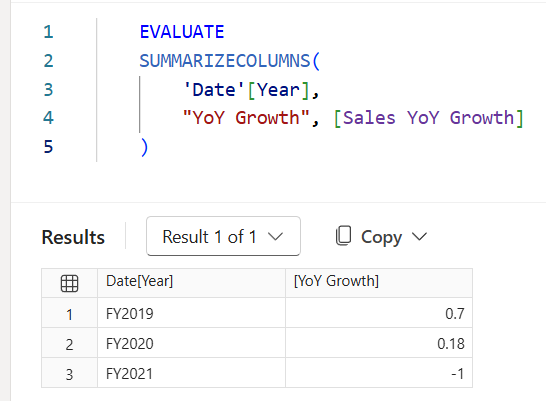

#### Examine column cardinality
In this task, you use the `COLUMNSTATISTICS()` DAX function to see how many distinct values each column contains. Columns with high cardinality compress less efficiently and consume more memory. Understanding where cardinality is highest helps you make informed decisions about model design.
1. Switch to **DAX query view** in Power BI Desktop.
2. In a new query tab, enter the following query and select **Run**:

```dax
DEFINE
    VAR _stats = COLUMNSTATISTICS()
EVALUATE
    FILTER(_stats, NOT CONTAINSSTRING([Column Name], "RowNumber-"))
ORDER BY [Cardinality] DESC
```
> The result grid returns one row per column in the model, sorted by the number of distinct values. The `FILTER` excludes internal system columns that aren’t part of your model. The columns with the highest cardinality appear at the top.

3. Review the results and notice where the highest cardinality columns come from:
* **SalesOrderNumber** in the **Sales** table has the highest cardinality (3,616) — nearly one distinct value per row. This is typical for transaction identifiers in fact tables.
* **Date** in the **Date** table is second (1,826). The calendar table covers a wider date range than the actual sales data, so it has more distinct values than OrderDate (990) in the Sales table.
* **Cost** (1,430) and **Sales** (1,411) have high cardinality for numeric columns — many distinct decimal values. Rounding to fewer decimal places is one way to reduce cardinality for numeric columns.
* **ResellerKey** (701) and **Reseller** (699) are nearly 1:1, which is expected for a dimension key and its label.
4. Notice that fact table columns (**Sales**) dominate the top of the list. In a star schema, dimension tables stay small while fact tables drive memory consumption. This is why fact table optimization has the biggest impact.
#### Verify the improvements
In this task, you re-run Performance analyzer to compare against your baseline now that you’ve optimized the Sales YoY Growth measure.
1. Switch to **Report view** and open the Performance analyzer pane if it isn’t already open.
2. Select **Clear**, then select **Start recording**.
3. Select **Refresh visuals** and wait for all visuals to finish loading.
4. Select **Stop recording**.
5. Expand the **Table** visual entry and compare its **DAX query** time to the baseline you recorded earlier.
> Note: The absolute difference may be small with this dataset. The important takeaway is the process: measure → diagnose → fix → verify.

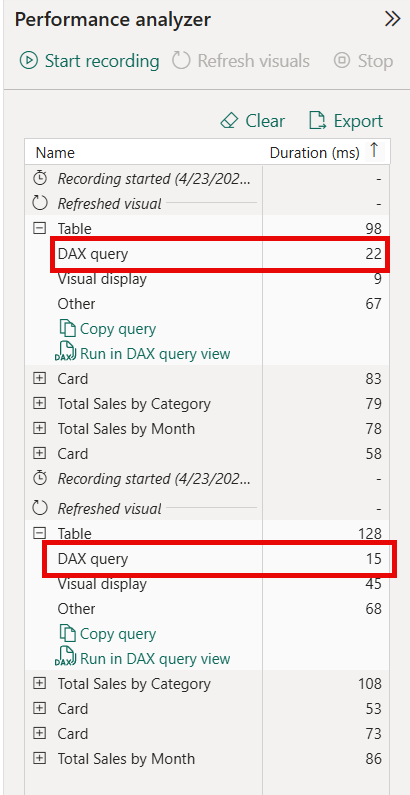

#### Try it with Copilot (Optional)
In this task, you use Copilot in DAX query view to get AI-powered suggestions for simplifying and optimizing your DAX queries.

If Copilot is available in your Power BI Desktop environment, try these additional steps:
1. In Performance analyzer, select **Copy query** for any visual.
2. Switch to DAX query view. Paste the query and ask Copilot:
    > `Simplify this DAX query and suggest performance improvements.`

3. Review Copilot’s suggestions. Compare them to the manual optimization you applied.
4. Ask Copilot:
    > `Explain why evaluating the same CALCULATE expression twice is slower than using a variable.`

5. Optionally, ask Copilot to generate a new measure using best practices from the start:
    > `Write a measure that calculates profit margin percentage using variables for Sales and Cost.`

> Note: Copilot generates new insights and suggestions without changing the measures you already optimized.

#### Clean up resources
Close Power BI Desktop. There’s no need to save the file.

### **Knowledge check**

#### 1. A report author notices that a table visual takes longer to load than other visuals on the same page. In Performance analyzer, the DAX query time is 4,200 ms while the visual display time is 150 ms. What should the report author investigate first?

A) The rendering performance of the table visual \
**B) The measures or filter patterns used by the visual's DAX query** \
C) The network connection between the client and the Power BI service

#### 2. A measure calculates the same `CALCULATE` expression three times within its formula. What DAX optimization technique most directly addresses this inefficiency?

A) Replace iterator functions with aggregation functions \
**B) Use a `VAR` to store the `CALCULATE` result and reference it in the `RETURN` expression** \
C) Move the calculation to a Power Query computed column

#### 3. A semantic model contains a column that stores order timestamps to the millisecond, but reports only group data by date. Which cardinality reduction technique is most appropriate?

A) Remove the column entirely from the model \
B) Convert the column data type from datetime to text \
**C) Truncate the column to date precision in Power Query before loading**

#### 4. An organization has a DirectQuery model with a large fact table containing billions of rows. Reports frequently query the data at the monthly and regional level. What approach helps accelerate these summary-level queries?

**A) Implement aggregations that store summarized data at the monthly and regional level** \
B) Add `FILTER` expressions to each measure to limit the data scanned \
C) Convert all dimension tables to DirectQuery storage mode

#### 5. A report page with 25 visuals loads slowly. Performance analyzer shows that individual DAX query times are under 200 ms per visual, but the total page load exceeds 10 seconds. What is the most likely cause?

A) The individual measures need DAX optimization \
**B) The sheer number of visuals is generating too many sequential queries** \
C) The semantic model has high-cardinality columns that need to be reduced

## **Enforce semantic model security**

### **Introduction**

#### Why Semantic Model Security Matters
By default, users with access to a semantic model can potentially access all data inside it.

Security ensures users only see:

✅ Data they're authorized to view \
✅ Appropriate rows \
✅ Appropriate columns \
✅ Appropriate tables

This protection applies to:
* Power BI Reports
* Dashboards
* Excel
* Copilot
* AI Experiences
* Semantic Model Queries
#### Two Main Security Types
This module focuses on:
##### 1. Row-Level Security (RLS)
Controls:
* Which Rows Users Can See

**Example**

Sales table:
| Region | Sales   |
| ------ | ------- |
| East   | 100,000 |
| West   | 200,000 |

East Region Manager sees:
> East Only

West Region Manager sees:
> West Only

**Rows Are Filtered**
* The table remains the same.
* Only visibility changes.
##### 2. Object-Level Security (OLS)
Controls:
* Which Tables, Which Columns Users Can See

**Example**

Employee table:
| Employee | Salary |
| -------- | ------ |
| John     | 50000  |

Payroll Team:

✅ Employee \
✅ Salary

Sales Team:

✅ Employee \
❌ Salary

**OLS Hides Objects Entirely**

Users don't even know the protected column exists.
#### Real-World Example
##### Regional Sales Security
Manager:
> North Region

should only see:
> North Region Data

**Solution**

✅ Row-Level Security (RLS)
##### HR Salary Security
Most employees should not access:
* Salary
* Bonus
* Compensation

Solution

✅ Object-Level Security (OLS)
#### Why Security Matters for Copilot
Copilot queries semantic models just like human users.

Without security:

❌ Unauthorized data exposure \
❌ Sensitive information leakage

With RLS and OLS:

✅ Copilot only sees authorized data \
✅ Security boundaries remain enforced \
✅ Natural-language queries respect permissions
#### Row-Level Security (RLS)
##### Purpose
Filters rows dynamically.

Example:
> User = East Manager

Result:
> Only East Rows

##### Implemented With
DAX filter expressions.

Example:
```DAX
[Region] = "East"
```
#### Dynamic RLS
Most common enterprise approach.

Instead of:
> One Role Per User

use:
> One Dynamic Role

##### Benefits
✅ Easier maintenance \
✅ Scales to thousands of users \
✅ Automatic filtering
#### Object-Level Security (OLS)
##### Purpose
Protect sensitive schema objects.

Can restrict:

✅ Columns \
✅ Tables
##### Examples
Hide:
* Salary
* Profit Margin
* SSN
* Bonus
##### Difference From RLS
| Security Type | Controls         |
| ------------- | ---------------- |
| RLS           | Rows             |
| OLS           | Tables & Columns |

#### Security Layers
A secure model often uses both.

Example:
> Sales Manager

Can see:

✅ Sales in their region \
❌ Salary data

Implemented with:

✅ RLS + OLS
#### Testing Security
After configuration, always test.

Questions:
1. What does Region Manager see?
2. What does HR see?
3. What does Copilot see?
##### Security Testing Goals
✅ Verify filters work \
✅ Verify restricted objects are hidden \
✅ Validate role behavior \
✅ Prevent accidental data exposure
#### Role Management
Users gain permissions through:
##### Roles
Examples:
* Regional Manager
* HR
* Finance
* Executive

Each role defines:

✅ Allowed rows \
✅ Allowed objects

Users become members of roles.
#### Security Architecture
> Users → Roles → RLS Filters → OLS Restrictions → Semantic Model → Reports / Copilot

#### Security and AI
Modern Fabric environments require security across all access methods.

Security must apply to:

✅ Power BI Reports \
✅ Excel \
✅ DAX Queries \
✅ Copilot \
✅ AI Agents
##### Key Principle
* Same User
* Same Security
* Regardless of Tool
#### Exam Quick Facts
✅ Semantic model security controls data access \
✅ Two primary security types:
* Row-Level Security (RLS)
* Object-Level Security (OLS)

✅ RLS restricts rows \
✅ OLS restricts columns and tables \
✅ RLS uses DAX filter expressions \
✅ Dynamic RLS is preferred for large organizations \
✅ OLS is commonly used for sensitive fields such as:
* Salary
* Compensation
* Financial metrics

✅ Copilot respects semantic model security \
✅ Security applies across:
* Reports
* Dashboards
* AI experiences

✅ Users are assigned to security roles
#### Memory Trick
* RLS = Rows 📋
* OLS = Objects 🔒

Or:
> RLS → Which Records? \
> OLS → Which Columns/Tables?

⭐ Most common exam question:
* Regional data filtering = RLS
* Hide salary column = OLS

### **Implement row-level security**

#### What is Row-Level Security (RLS)?
**Row-Level Security (RLS)** controls **which rows of data users can see** in a semantic model.

Without RLS:
> All Users → See All Rows

With RLS:
> User → Only Authorized Rows

#### Why Use RLS?
Examples:
##### Sales Organization
> East Manager \
> sees: \
> East Sales Only

> West Manager \
> sees: \
> West Sales Only

##### HR Scenario
> Payroll Staff

see:
> All Employees

while others may see only limited employee records.
#### Important Exam Fact
RLS applies to:

✅ Power BI Reports \
✅ Dashboards \
✅ Paginated Reports \
✅ Copilot \
✅ Data Agents \
✅ Semantic Model Queries

Security is enforced regardless of access method.
#### How RLS Works
RLS uses:
```
TRUE / FALSE
```
filter expressions.

Rows returning:
```
TRUE
```
are visible.

Rows returning:
```
FALSE
```
are hidden.
##### Example
```dax
[Region] = "Midwest"
```
Only Midwest rows remain visible.
#### RLS and Star Schema
##### Best Practice
Apply security to:

✅ Dimension Tables

Not:

❌ Fact Tables
##### Example
> `DimRegion` → `FactSales`

Security filter:
```dax
[Region] = "Midwest"
```
applied to:

`DimRegion`
##### Result
Power BI automatically propagates the filter through relationships.
##### Filter Flow
> Region Table → State Table → Sales Fact Table

Only Midwest sales become visible.
##### Exam Rule
✅ Filter dimensions \
❌ Avoid filtering large fact tables directly
#### Create Security Roles
Roles contain RLS rules.
##### Create a Role
Power BI Desktop:
> Modeling → Manage Roles → New

Steps:
1. Create role
2. Name role
3. Choose table
4. Add DAX filter
5. Save
#### Role Examples
##### Regional Sales Role
```dax
[Region] = "Midwest"
```
##### No Restriction Role
No rule defined.

Result:
> All Data Visible

Used for administrators.
##### No Access Role
```
FALSE()
```
Result:
> No Rows Returned

##### Exam Tip
```dax
FALSE()
```
can intentionally block access to all rows.
#### Dynamic Security
Most Important RLS Concept
> Instead of:
> Role per User

we create:
> One Dynamic Role

#### `USERPRINCIPALNAME()`
Returns:
```
user@domain.com
```
for the signed-in user.
##### Example
```dax
[SalesPersonEmail] = USERPRINCIPALNAME()
```
##### Result
Current user sees only rows matching their email.
##### Example
Table:
| Email              | Sales |
| ------------------ | ----- |
| <john@contoso.com> | 1000  |
| <mary@contoso.com> | 2000  |

John signs in.

Result:
> John's Rows Only

#### Why Dynamic Security Is Better
Without dynamic security:
> 50 Sales People

may require:
> 50 Roles

With dynamic security:
> 1 Role

works for everyone.
##### Benefits
✅ Easier maintenance \
✅ Better scalability \
✅ No model republishing \
✅ Data-driven access
#### Security Table Pattern (AppUser Pattern)
##### Purpose
Manage complex authorizations.
##### Example Table
| User | Region |
| ---- | ------ |
| John | East   |
| John | North  |
| Mary | West   |

John can access:
* East
* North

Mary can access:
* West
##### Example DAX
```dax
CONTAINS(
    AppUser,
    AppUser[UserName],
    USERPRINCIPALNAME(),
    AppUser[Region],
    [Region]
)
```
#### Benefits of Security Tables
##### Centralized Security
> One Table

controls access.
##### Multi-Region Access
Users can access:
> Multiple Regions

without multiple roles.
##### Data-Driven Security
Update access by:
> Changing Table Data

instead of modifying the model.
#### Static RLS
##### What is Static Security?
Uses fixed values.
##### Example:
```dax
[Region] = "Midwest"
```
##### Benefits
✅ Simple \
✅ Easy to understand
##### Drawbacks
❌ Doesn't scale \
❌ Requires model updates \
❌ New roles required for new regions
##### Dynamic vs Static RLS
| Feature                   | Static | Dynamic |
| ------------------------- | ------ | ------- |
| Fixed Value               | ✅      | ❌       |
| Uses User Identity        | ❌      | ✅       |
| Scalable                  | ❌      | ✅       |
| Production Recommendation | ❌      | ✅       |

##### Exam Rule
Use:

✅ Dynamic Security

for production models.
#### `USERNAME()` vs `USERPRINCIPALNAME()`
Important exam question.
##### `USERNAME()`
Desktop:
```
DOMAIN\username
```
Service:
```
user@domain.com
```
**Problem**

Different formats.
##### `USERPRINCIPALNAME()`
Desktop:
```
user@domain.com
```
Service:
```
user@domain.com
```
**Benefit**

Consistent everywhere.
##### Exam Rule
✅ Prefer `USERPRINCIPALNAME()`
#### DirectQuery and Single Sign-On (SSO)
When DirectQuery supports:
> Single Sign-On

the source system may enforce security.

Flow:
> User → Database → Database Applies Security

##### Result
RLS may be handled at the source instead of Power BI.
#### RLS Performance Best Practices
##### 1. Filter Dimensions
Best:
> Dimension Table → Fact Table

##### 2. Avoid LOOKUPVALUE
Prefer:
> Relationships

for filter propagation.
##### 3. Test with Real Data
Security can behave differently at scale.
##### 4. Measure Performance
Use:
> Performance Analyzer

to verify effects of RLS.
#### Common RLS Patterns
##### Static Region Security
```dax
[Region] = "West"
```
##### Dynamic User Security
```dax
[Email] = USERPRINCIPALNAME()
```
##### No Access Rule
```
FALSE()
```
##### Security Table Pattern
```dax
CONTAINS(...)
```
with AppUser table.
#### Typical Enterprise Architecture
> Users → Security Role → `USERPRINCIPALNAME()` → Dimension Table → Fact Table → Visible Data

#### Exam Quick Facts
✅ RLS controls rows \
✅ Defined through roles \
✅ Uses DAX filter expressions \
✅ Applies to:
* Reports
* Dashboards
* Copilot
* Data Agents

✅ Best practice:
* Filter dimension tables

✅ Dynamic security uses:
```dax
USERPRINCIPALNAME()
```
✅ Static security uses:
```dax
[Region] = "West"
```
✅ AppUser security tables support:
* Centralized security
* Multiple assignments
* Data-driven access

✅ `USERPRINCIPALNAME()` is preferred over `USERNAME()` \
✅ `FALSE()` blocks access to all rows \
✅ Dynamic RLS is recommended for production
#### Memory Trick
##### RLS Formula
> Role → DAX Filter → Visible Rows

##### Most Tested Concepts ⭐
* `USERPRINCIPALNAME()` = Dynamic Security
* `[Region] = "West"` = Static Security

And remember:

**RLS filters ROWS, not columns.**

### **Apply object-level security**

#### What is Object-Level Security (OLS)?
**Object-Level Security (OLS)** controls access to:

✅ Tables \
✅ Columns

Unlike RLS:
* LS controls rows
* OLS controls objects (tables and columns)
#### RLS vs OLS
| Security Type | Controls                           |
| ------------- | ---------------------------------- |
| RLS           | Which rows users see               |
| OLS           | Which tables and columns users see |

##### Example
Employee table:
| Employee | Department | Salary |
| -------- | ---------- | ------ |
| John     | Sales      | 50,000 |

**General Manager**

Can see:

✅ Employee \
✅ Department \
❌ Salary

**Payroll Team**

Can see:

✅ Employee \
✅ Department \
✅ Salary
#### Why Use OLS?
OLS is designed for sensitive data.
#### Common Use Cases
##### Personally Identifiable Information (PII)
Examples:
* SSN
* Phone Number
* Home Address
##### Financial Data
Examples:
* Salary
* Profit Margin
* Cost Data
* Bonus Amount
##### Development Objects
Examples:
* Staging Tables
* Intermediate Tables
* Helper Tables
##### Exam Tip
OLS is commonly used for:
* Salary Data
* PII Data
* Sensitive Financial Data
#### Key OLS Behavior
When OLS hides an object:

✅ Data is hidden \
✅ Metadata is hidden \
✅ Users cannot query it \
✅ Copilot cannot access it
##### Important Difference
Hidden column:
* User cannot even see it exists.

This is stronger than simply hiding a column in Power BI.
#### Configure OLS
##### Tool Required
OLS cannot be configured directly in:
* Power BI Desktop

Use

✅ Tabular Editor
#### Configuration Process
##### Step 1
Create roles in:
* Power BI Desktop

via:
> Modeling → Manage Roles

##### Step 2
Open:
* Tabular Editor

from:
* External Tools
##### Step 3
Navigate:
* Roles
##### Step 4
Choose role

Example:
* Payroll
* Manager
* HR
##### Step 5
Configure permissions.

Options:
* Read
    > Object Visible
* None
    > Object Hidden
##### Step 6
Save changes.
##### Step 7
Publish model.
##### Step 8
Assign role members in Power BI Service.
#### OLS Permissions
##### Read
The user can:

✅ See object \
✅ Query object \
✅ Use object
##### None
The user:

❌ Cannot see it \
❌ Cannot query it \
❌ Cannot discover it
##### Exam Memory
* Read = Visible
* None = Hidden
#### Hiding Entire Tables
Set table permission:
```
None
```
##### Example
`SalaryBand Table`

used only by payroll.

General users:
* Cannot See Table

Payroll users:
* Can See Table
#### Hiding Columns
Most common OLS scenario.
##### Example
Employee table:
* Employee Name
* Department
* Salary

Hide:
* Salary

for non-HR users.
##### Result
User sees:
* Employee Name
* Department

Only.
#### OLS and Measures
Important exam topic.
##### Can OLS Hide Measures?
❌ No

Measures cannot be directly secured via OLS.
##### However
If a measure references:
* Secured Table

or
* Secured Column

the measure becomes unavailable.
##### Example
```dax
Salary Cost =
SUM(Employee[Salary])
```
If:
* Salary Column

is secured:
* Salary Cost

also becomes inaccessible.
#### Workspace Role Limitation
OLS applies only to:

✅ Viewers

Users with:
* Admin
* Member
* Contributor

can bypass OLS.
##### Exam Tip
OLS does NOT protect against users who have edit permissions.
#### Relationship Limitation
OLS cannot break relationship paths.
##### Example
> A → B → C

You cannot hide:
* Table B

if doing so breaks:
> A → C

filter propagation.
##### Instead
Hide:
> Specific Columns inside B.

#### OLS Feature Limitations
Semantic models with OLS do NOT support:

❌ Quick Insights \
❌ Smart Narrative Visuals \
❌ Excel Data Types Gallery
##### Exam Fact
OLS can limit certain Power BI intelligence features.
#### Error Behavior
If a report attempts to access:
* Hidden Column

Power BI typically returns:
* `Field Not Found`

errors.
##### User Impact
Can confuse users if report design doesn't account for security.
#### Alternative Approach
Instead of OLS:

Sometimes better to create:

✅ Separate reports \
✅ Separate semantic models

for different audiences.
#### Combining OLS and RLS
Very common enterprise design.
##### RLS
Controls:
* Which Rows?
##### OLS
Controls:
* Which Columns?
* Which Tables?
##### Example
Regional Sales Manager

**RLS**
> Only West Region Rows

**OLS**
> Salary Column Hidden

##### Result
User sees:
* West Region Data

but not:
* Salary Information
#### Security Layers
> User → RLS (Row Filtering) → OLS (Column/Table Protection) → Visible Data

#### OLS and Copilot
Very important for modern Fabric exams.

If a column is protected by OLS:

✅ Copilot cannot access it \
✅ AI Data Agents cannot access it \
✅ Natural-language queries cannot return it
##### Example
Hidden:
* Salary

Question to Copilot:
> Show employee salaries.

Result:
> `Access denied through OLS.`

#### RLS vs OLS Examples
| Requirement                   | Solution |
| ----------------------------- | -------- |
| Manager only sees West Region | RLS      |
| Hide Salary column            | OLS      |
| Hide Payroll table            | OLS      |
| Restrict Customer records     | RLS      |
| Hide SSN field                | OLS      |

#### OLS Best Practices
✅ Protect sensitive columns \
✅ Protect sensitive lookup tables \
✅ Use OLS together with RLS \
✅ Test report behavior carefully \
✅ Keep Viewer permissions for consumers \
✅ Avoid breaking relationship chains
#### Exam Quick Facts
✅ OLS = Object-Level Security \
✅ OLS secures:
* Tables
* Columns

✅ OLS configured through:
* Tabular Editor

✅ Permission options:
* Read
* None

✅ None hides object and metadata \
✅ Measures cannot be directly secured \
✅ Measures referencing secured columns become unavailable \
✅ OLS only applies to Viewer users \
✅ Admin, Member, Contributor can bypass OLS \
✅ OLS can hide:
* Salary
* SSN
* Financial data
* Staging tables

✅ OLS and RLS can work together \
✅ Copilot respects OLS restrictions
#### Memory Trick
##### Security Rule
* RLS = Rows
* OLS = Objects
##### Exam Favorite ⭐
* Hide Salary Column → OLS
* Show Only West Region → RLS

And remember:
* RLS filters data you can see.
* OLS hides data that exists at all.

### **Test security and manage roles**

#### Why Testing Security Matters
After configuring:

✅ Row-Level Security (RLS) \
✅ Object-Level Security (OLS)

you must verify they work correctly before production deployment.

Testing prevents:

❌ Unauthorized data access \
❌ Incorrect filtering \
❌ Security gaps \
❌ Copilot data exposure
#### Security Lifecycle
> Create Roles → Configure RLS / OLS → Test → Publish → Test Again → Assign Users → Monitor

#### Testing Roles in Power BI Desktop
##### View As Feature
Power BI Desktop provides:
> View As

to simulate user access.
#### Steps
##### Step 1
Open:
> Modeling → View As

##### Step 2
Choose a role.

Example:
* Regional Sales
##### Step 3
For Dynamic RLS:

Enter a test user in:
> Other User

field.

**Example**
* `john@contoso.com`
##### Step 4
Validate results.
##### Step 5
Select:
> Stop Viewing

to return to normal mode.
#### What to Validate
##### 1. Correct Data Visible
Example:
> West Manager

should see:
> ✅ West data

##### 2. Restricted Data Hidden
Should NOT see:

❌ East data \
❌ North data
##### 3. Totals Are Correct
Totals must reflect:
* Filtered Data Only

not all rows.
##### 4. OLS Behavior
Verify:

✅ Hidden columns remain hidden \
✅ Hidden tables remain inaccessible \
✅ Expected errors appear if needed
#### Dynamic RLS Testing
Test multiple users.

Example:
```
john@contoso.com
mary@contoso.com
admin@contoso.com
```
Also test:
> User Not In Security Table

to verify:

✅ No data returned
#### Testing in Power BI Service
Very important exam topic.
##### Why Test Again?
Power BI Desktop and Service can behave differently.
Especially for:

✅ DirectQuery \
✅ Single Sign-On (SSO) \
✅ Live connections \
✅ Security propagation
#### Steps
##### Step 1
Open Semantic Model.
##### Step 2
Choose:
```
...
↓
Security
```
##### Step 3
Select role.
##### Step 4
Click:
> Test As Role

##### Step 5
Validate data visibility.
#### Exam Rule
Always test:

✅ Before publishing \
✅ After publishing
#### Assigning Role Membership
After testing:
* Assign users to roles.
#### Steps
##### Step 1
Open:
> Semantic Model → Security

##### Step 2
Choose role.

**Example**:
* Regional Managers
##### Step 3
Add members.
##### Step 4
Save.
#### What Can Be Assigned?
##### Individual Users
Example:
```
john@contoso.com
```
##### Microsoft Entra Security Groups
Recommended ✅
##### Distribution Groups
Supported ✅
##### Mail-Enabled Groups
Supported ✅
##### Service Principals
Supported ✅
#### Important Exam Fact
❌ Microsoft 365 Groups

are NOT supported for role membership.
#### Security Groups (Best Practice)
Use:
* Microsoft Entra Security Groups

instead of individual users.
#### Why?
##### Easier Management
Instead of:
> 50 Individual Users

assign:
> 1 Security Group

##### Delegated Administration
* IT manages membership.
* Power BI admins don't need to.
##### Consistency
User added to group:

✅ Automatically receives access.

User removed:

✅ Automatically loses access.
##### Example
Instead of:
> 50 Regional Managers

assigned individually,

assign:
> `RegionalManagers Security Group`

once.
#### Workspace Roles vs RLS
A frequent exam topic.
##### Workspace Roles
Control:
* Who Can Access Content

Examples:
* Viewer
* Contributor
* Member
* Admin
##### RLS
Controls:
* What Data Users See
#### Interaction Rules
##### Viewer
✅ Subject to RLS \
✅ Subject to OLS
##### Contributor
❌ Bypasses RLS \
❌ Bypasses OLS
##### Member
❌ Bypasses RLS \
❌ Bypasses OLS
##### Admin
❌ Bypasses RLS \
❌ Bypasses OLS
#### Exam Rule
To enforce security:

✅ Use Viewer

Avoid:

❌ Contributor \
❌ Member \
❌ Admin

for secured consumers.
#### Common Security Mistakes
##### Mistake 1
User Not Assigned to Role

Result:
* Potential access problem.
* Always verify role assignments.
##### Mistake 2
Bidirectional Relationships

Can create:

✅ Unexpected security paths \
✅ Data leakage

**Recommendation**

Use:
* Apply Security Filter in Both Directions

only when absolutely required.
##### Mistake 3
Broken Relationships

Example:
> Region X Sales

relationship broken.

**Result**:

RLS fails to propagate.

Users may see:

❌ Unfiltered data

**Exam Rule**

Verify:

✅ Relationships are active \
✅ Filter paths are valid
##### Mistake 4
* Testing Only in Desktop
* Desktop ≠ Service
* Always test both.
##### Mistake 5
* Multiple Role Membership
* Very important.
##### How RLS Works
RLS roles are:
> Additive

Example:

Role A:
> West Region

Role B:
> East Region

Assigned to both:

User sees:
> West + East

##### Exam Tip
Multiple roles return:

✅ Union of allowed rows

not intersection.
#### Security and AI
Modern Fabric security applies to AI too.
##### Copilot
Copilot respects:

✅ RLS \
✅ OLS
##### Example
User only has:
> West Region

access.

Question:
* Show company sales.

Result:
> West Region Only

#### Fabric Data Agents
Also respect:

✅ RLS \
✅ OLS
#### User Identity Flow
> User → Copilot → Semantic Model → RLS/OLS Applied → Response Generated

#### OLS and AI
If column hidden by OLS:
* Salary

Copilot cannot expose it.
##### Example
Question:
* Show employee salaries.

Result:

❌ No access

because:
> OLS blocks column access

#### Security Validation Checklist
Before Production:

✅ Test every role \
✅ Test dynamic users \
✅ Test users not in security tables \
✅ Test OLS objects \
✅ Test in Desktop \
✅ Test in Service \
✅ Verify relationships \
✅ Verify role memberships \
✅ Verify Copilot behavior
#### Complete Security Process
> Create Role → Configure RLS → Configure OLS → View As Testing → Publish → Test As Role → Assign Security Group → Validate

#### Exam Quick Facts
✅ Use:
> View As

in Desktop to test RLS

✅ Use:
> Test As Role

in Power BI Service

✅ Dynamic RLS testing uses:
> Other User

field

✅ Verify:
* Visible data
* Hidden data
* Totals
* OLS behavior

✅ Supported role members:
* Users
* Entra Security Groups
* Distribution Groups
* Service Principals

✅ Not supported:
* Microsoft 365 Groups

✅ Microsoft Entra Security Groups are recommended \
✅ Viewer users are subject to RLS and OLS \
✅ Admin, Member, Contributor bypass security \
✅ Multiple roles are additive (union of permissions) \
✅ Copilot respects both RLS and OLS
#### Memory Trick
> Test → Publish → Test Again → Assign Users

And remember the most tested rule:
* Viewer = RLS Applies
* Admin/Member/Contributor = RLS Bypassed

Also:
* Multiple RLS roles = Union of visible rows, not Intersection.

### **Exercise: Implement RLS for a semantic model**

#### Set up the environment
You need Power BI Desktop (November 2025 or newer) installed to complete this exercise. Note: UI elements might vary slightly depending on your version.
1. Open a web browser and enter the following URL to download the [17-enforce-security zip folder](https://github.com/MicrosoftLearning/mslearn-fabric/raw/refs/heads/main/Allfiles/Labs/17/17-enforce-security.zip)
2. Save the file in **Downloads** and extract the zip file to the **17-enforce-security** folder.
3. Open **17-Starter-Sales Analysis.pbix** from the extracted folder.
> Note: If a security warning asks you to apply changes, select Ignore or Close. Don’t select Discard changes. If prompted about a data source connection, dismiss the warning — you won’t need to refresh data in this lab.

#### Review the data model
In this task, you review the semantic model structure to understand how the tables relate and where security filters must be applied.
1. In Power BI Desktop, at the left, switch to **Model** view.

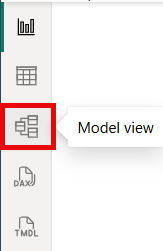

2. Review the model diagram to see the table relationships.
> The model comprises six dimension tables and one fact table in a star schema. The `Sales` fact table stores sales order details.

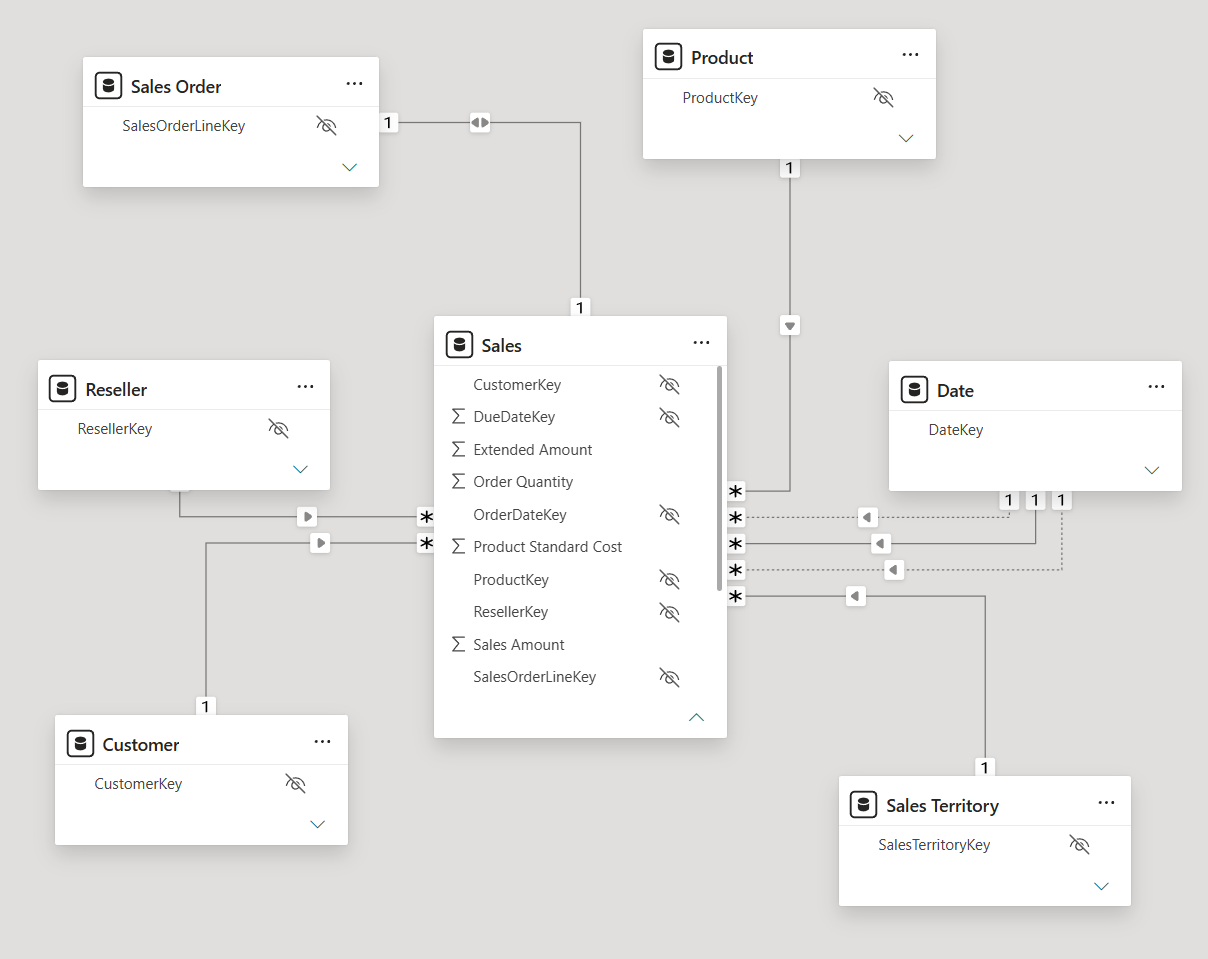

3. Expand the `Sales Territory` table to view its columns.
4. Locate the `Region` column in the table. The `Region` column stores the Adventure Works sales regions.

At this organization, salespeople are only allowed to see data related to their assigned sales region.
#### Create static roles
The simplest form of RLS is a static role, where a DAX filter hardcodes a field value. Static roles are useful for understanding the RLS mechanics before moving to a data-driven approach. In this section, you create two static roles—one per region—and validate that each one filters correctly.

In this task, you define a static filter on the `Sales Territory` table for two regions.
1. Switch to **Report** view.
2. Notice the stacked column chart shows data for all regions. That changes once RLS is applied.

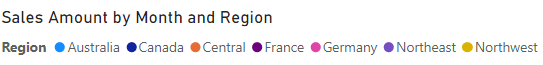

3. On the **Modeling** ribbon, in the **Security** group, select **Manage roles**.

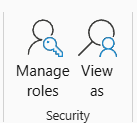

4. Select **+ New**, name the role `Australia`, and select the `Sales Territory` table.
5. In the **Rules** section, select **+ New** and configure the filter:
    * Column = `Region`
    * Condition = `Equals`
    * Value = `Australia`

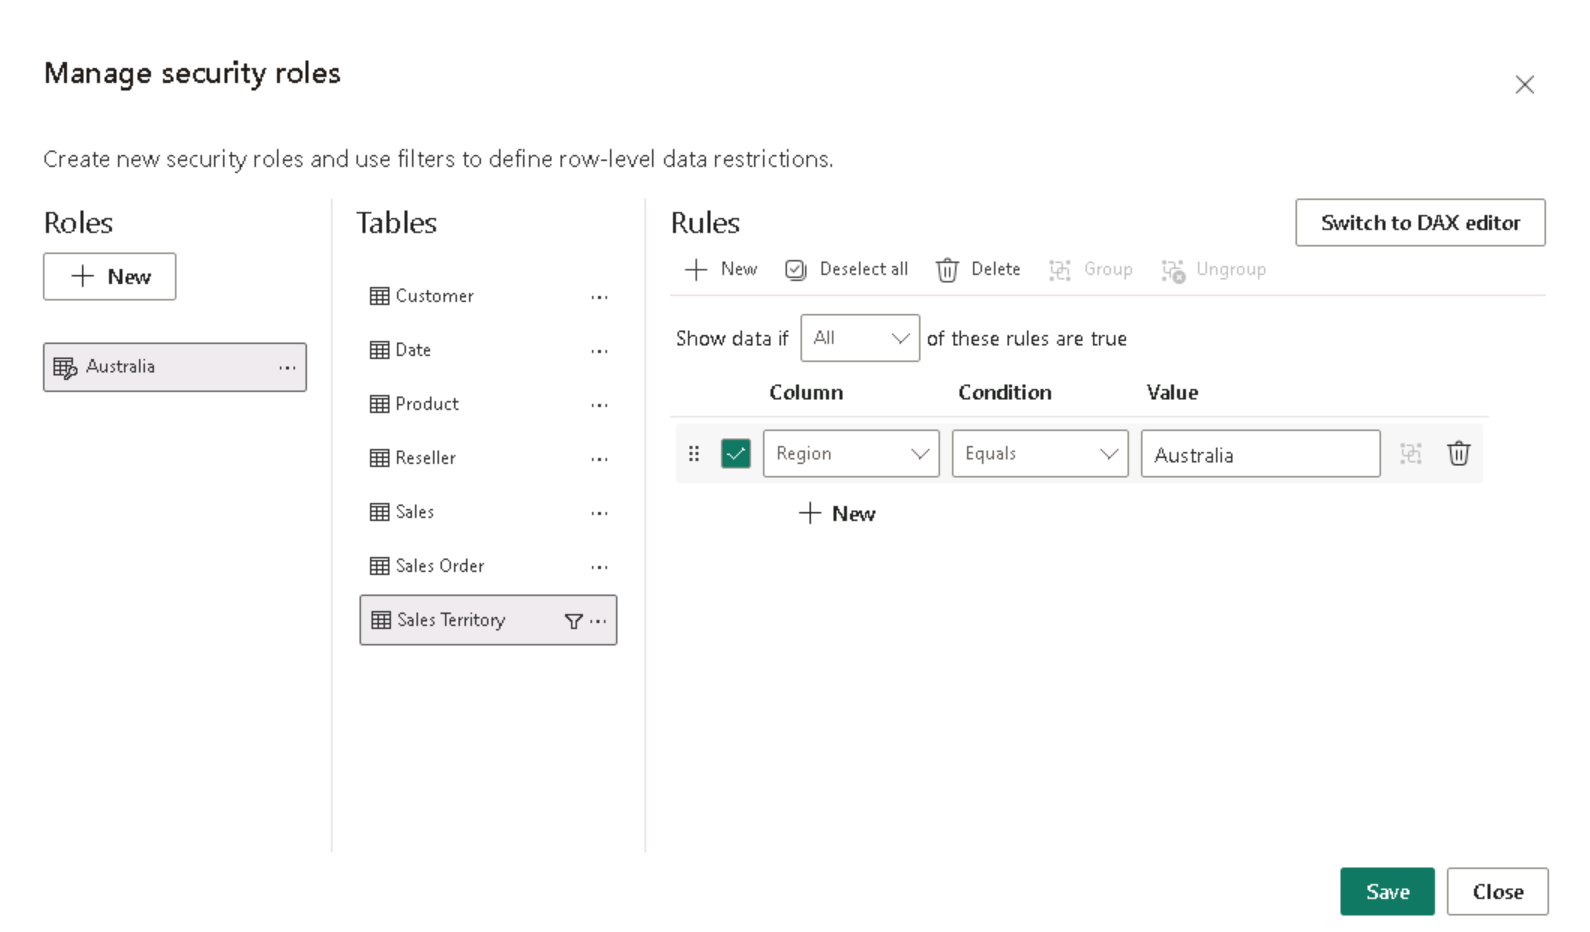

6. Select **+ New** again in the **Roles** section to add a second role named `Canada`, applying the same filter for `Canada` and **Save**.
##### Validate the static roles
In this task, you confirm that each role restricts the report to its assigned region.
1. On the **Modeling** ribbon, select **View as**, select the `Australia` role, and select **OK**.
2. Verify the chart shows only Australia data, then select **Stop viewing**.
3. Repeat for the `Canada` role and confirm it shows only Canada data, then select **Stop viewing**.

Static roles work, but they don’t scale. Every new region requires a new role definition, and any change means updating and republishing the semantic model. For 11 Adventure Works regions, that’s 11 roles to create and maintain—and the number grows with the business.
#### Clean up resources
Delete the static roles `Australia` and `Canada` created in this lab before proceeding to the next step.
#### Add the Salesperson table
Dynamic RLS requires a mapping table that links each user identity to a sales territory. In this section, you import the `Salesperson` table from a CSV file, prepare it in Power Query, and configure the relationship so security filters propagate correctly.
##### Import the CSV
In this task, you use Power Query to import `Salesperson` data from the CSV file included in the extracted zip folder.
1. On the **Home** ribbon, select **Get data > Text/CSV**.
2. Navigate to the extracted **17-enforce-security** folder and select `Salesperson.csv`, then select **Open**.
3. In the preview window, verify you see three columns: `EmployeeKey`, `SalesTerritoryKey`, and `EmailAddress`.
4. Select **Transform Data** to open Power Query Editor.
> Note: Selecting Transform Data instead of Load lets you rename the column before loading it into the model.

##### Rename the column
In this task, you rename the `EmailAddress` column to `UPN` (User Principal Name) to clarify its purpose as the identity field for dynamic RLS.
1. In Power Query Editor, right-click the `EmailAddress` column header and select **Rename**.
2. Replace the text with `UPN` and press **Enter**.
> UPN stands for User Principal Name. The values in this column match Microsoft Entra account names, which is what the `USERPRINCIPALNAME()` DAX function returns.

3. On the **Home** ribbon, select **Close & Apply** to load the table into the model.
##### Create and configure the relationship
In this task, you create a relationship between the `Salesperson` table and the `Sales Territory` table, then configure it so security filters propagate in both directions.
1. Switch to **Model** view.
2. Drag the `SalesTerritoryKey` field from the `Salesperson` table to the `SalesTerritoryKey` field on the `Sales Territory` table to create a relationship.
> Note: If the relationship was created automatically when you loaded the table, you can skip the drag step and proceed to configuring its properties.

3. Right-click the relationship line between `Salesperson` and `Sales Territory`, then select **Properties**.
4. In the **Edit relationship** window, set **Cross filter direction** to **Both**.
5. Check the **Apply security filter in both directions** checkbox and **OK**.

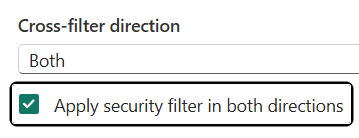

The `Sales Territory` table has a one-to-many relationship to the `Salesperson` table. By default, filters only flow from the “one” side (`Sales Territory`) to the “many” side (`Salesperson`).

To make a security filter on `Salesperson` propagate back to `Sales Territory` — and then down to `Sales` — you must enable bi-directional cross-filtering with the security filter option.
##### Hide the Salesperson table
In this task, you hide the `Salesperson` table so it doesn’t appear in report authoring tools or Q&A.
1. In Model view, select the `Salesperson` table header.
2. Right-click and select **Hide in report view** (or select the eye icon at the top-right of the table).
> The `Salesperson` table exists solely to enforce data permissions. Hiding it prevents report authors from accidentally using it in visuals or exposing UPN data.

#### Create the dynamic role
Dynamic RLS avoids creating and maintaining one role per region. A single role can serve all users by filtering rows to the signed-in identity.

In this section, you create one dynamic role that filters the `Salesperson` table by user principal name.
1. On the **Modeling** ribbon, in the **Security** group, select **Manage roles**.

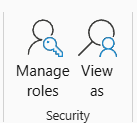

2. Select **+ New**, name the role `Salespeople`, select the `Salesperson` table, and then select **Switch to DAX editor**.

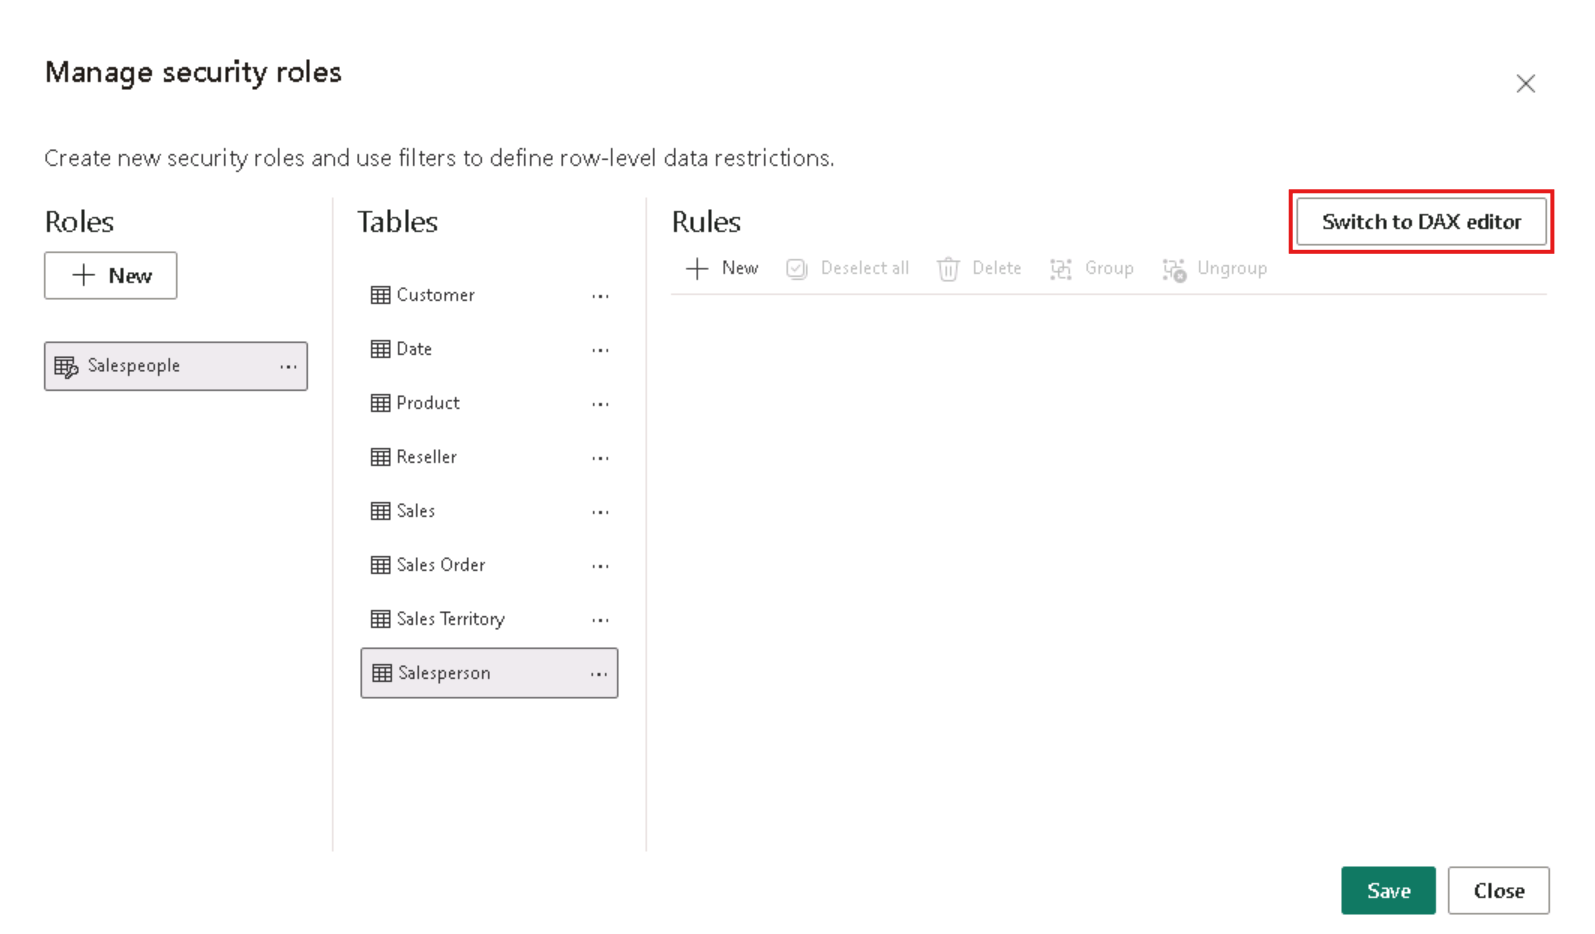

3. Enter the following expression:
```dax
[UPN] = USERPRINCIPALNAME()
```
4. Select **Save**.

This expression keeps only rows where the `UPN` value matches the authenticated user’s identity. Because of the bi-directional security filter you configured earlier, this filter propagates from `Salesperson` -> `Sales Territory` -> `Sales`, restricting the user to only their assigned region’s data.
#### Validate the dynamic role
In this section, you test the dynamic role for a mapped user and an unmapped user to demonstrate how a single role returns different results based on user identity.
##### Test the role as another model user
In this task, you confirm that the same role returns a different filtered result when evaluated for another identity.
1. On the **Modeling** ribbon, select **View as**.
2. Select **Other user** and enter `michael9@adventure-works.com`.
3. Check the `Salespeople` role, then select **OK**.

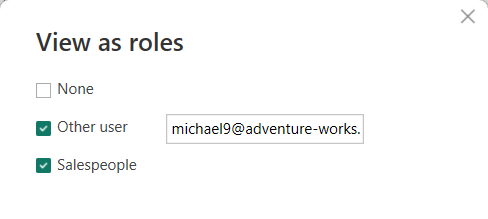

4. Verify the report now shows data for only the `Northeast` region (michael9’s assigned territory).
5. Select **Stop viewing**.
##### Test as an unmapped user
In this task, you confirm that dynamic RLS denies data when no matching UPN row exists.
1. Select **View as** > **Other user**.
2. Enter `nomatch@adventure-works.com`, check `Salespeople`, and select **OK**.
3. Verify the report shows no data.

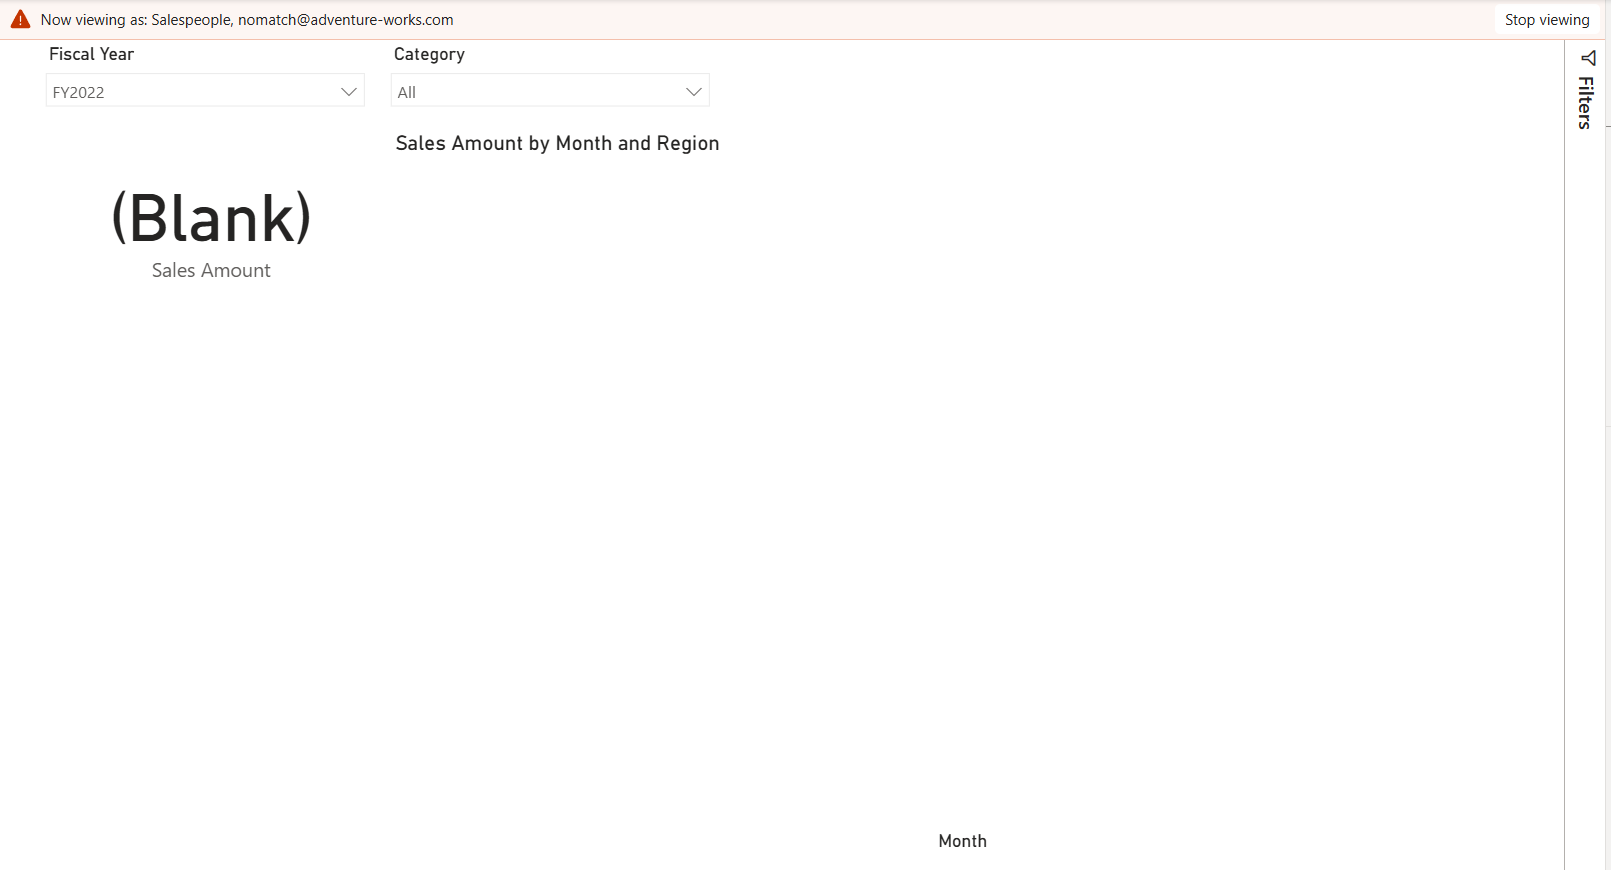

4. Select **Stop viewing**.
#### Clean up resources
Close Power BI Desktop without saving.

### **Module assessment**

#### 1. A data modeler needs to ensure that sales managers see only the sales data for their assigned region. The modeler wants a scalable solution that doesn't require model changes when managers change regions. Which approach should the data modeler use?

A) Create a static RLS rule for each region and assign managers to the appropriate role. \
**B) Create a dynamic RLS rule using `USERPRINCIPALNAME()` with a security table that maps managers to regions.** \
C) Use object-level security to hide regions that each manager shouldn't access.

#### 2. An organization's semantic model contains an Employee table with a Salary column. General managers need access to the Employee table for contact information, but only HR staff should see salary values. Which security feature should the data modeler configure?

A) Row-level security to filter salary rows. \
**B) Object-level security to restrict the Salary column.** \
C) Remove the Salary column from the semantic model and create a separate model for HR.

#### 3. A data modeler configured RLS on a semantic model and published it to the Power BI service. A Viewer reports that they can see all data instead of just their region's data. What is the most likely cause?

A) The RLS filter expression contains a syntax error. \
**B) The user hasn't been assigned to an RLS role in the Power BI service.** \
C) The semantic model uses DirectQuery instead of import mode.

#### 4. A data modeler needs to test whether RLS correctly filters data before publishing the semantic model to the Power BI service. How should the data modeler verify the security configuration?

**A) Use the View as feature on the Modeling tab in Power BI Desktop to preview data as a specific role.** \
B) Publish the model and ask each user to verify their data access. \
C) Review the DAX filter expressions for syntax errors in the formula bar.

#### 5. A data modeler is deciding how to assign users to RLS roles for a semantic model used by 200 sales representatives across five regions. What is the recommended approach for managing role membership?

A) Add each sales representative individually to the appropriate regional role. \
**B) Map Microsoft Entra security groups to roles, with one security group per region.** \
C) Create a Microsoft 365 group for each region and assign the groups to roles.

## **Manage the semantic model development lifecycle**

### **Introduction**

#### Why Lifecycle Management Matters
As organizations grow, they create:

✅ More Semantic Models \
✅ More Reports \
✅ More Developers \
✅ More Shared Assets

Without a lifecycle process:

❌ No version control \
❌ Accidental production changes \
❌ Lost change history \
❌ Duplicate work \
❌ Deployment errors \
❌ Difficult troubleshooting
#### Real-World Problem
Imagine analysts:
> Build Model → Publish Directly To Production

Problems:
* Who changed this measure?
* When was it changed?
* Why did the report break?

Nobody knows.
#### Solution
Implement a formal:
#### Content Lifecycle Management Process
> Develop → Validate → Deploy → Monitor

This is the core lifecycle model for Fabric semantic models.
#### Lifecycle Stages
##### 1. Develop
Create and maintain semantic models.

Activities:

✅ Create reusable assets \
✅ Develop measures \
✅ Create relationships \
✅ Design security \
✅ Build semantic models

**Goal**

Build a reliable model before deployment.
##### 2. Validate
Test before publishing.

Activities:

✅ Validate relationships \
✅ Test measures \
✅ Test RLS and OLS \
✅ Run Best Practice Analyzer \
✅ Verify performance \
✅ Review model quality

**Goal**

Catch problems before production.
##### 3. Deploy
Move content to production safely.

Activities:

✅ Deployment Pipelines \
✅ Git-based deployment \
✅ Release management \
✅ Environment promotion

**Goal**

Consistent production releases.
##### 4. Monitor
Maintain operational health.

Activities:

✅ Refresh monitoring \
✅ Usage monitoring \
✅ Performance monitoring \
✅ Capacity monitoring \
✅ Security monitoring

**Goal**

Ensure models continue working correctly.
#### Major Topics in This Module
This module focuses on:
##### Reusable Assets
Create standardized:

✅ Semantic Models \
✅ Templates \
✅ Shared Connections \
✅ Shared Components
##### Version Control
Track changes over time.

Benefits:

✅ Change history \
✅ Rollback capability \
✅ Collaboration \
✅ Auditing
##### Example Questions Answered
* Who changed a measure?
* When did the change occur?
#### Git Integration
Important enterprise feature.

Provides:

✅ Source Control \
✅ Branching \
✅ Merge Management \
✅ Collaboration \
✅ Recovery
##### Exam Tip
Git integration is one of the primary lifecycle-management capabilities in Fabric.
#### XMLA Endpoint Validation
Used for:

✅ Model validation \
✅ External tools \
✅ Automated testing \
✅ Enterprise development
##### Common Tools
* Tabular Editor
* DAX Studio
* ALM Toolkit
#### Deployment Pipelines
Used to move content through environments.

Typical pipeline:
> Development → Test → Production

##### Benefits
✅ Controlled releases \
✅ Reduced risk \
✅ Environment consistency \
✅ Easier governance
#### Refresh Management
Production models require:

✅ Scheduled Refresh \
✅ Monitoring \
✅ Failure Detection \
✅ Alerting
#### Monitoring
Monitor:
##### Performance
* Slow Queries
* High Resource Usage
##### Refreshes
* Failures
* Duration
* Frequency
##### Usage
* Who Uses Reports
* Which Models Are Active
#### Lifecycle Architecture
> Develop → Git → Validate → Deployment Pipeline → Production → Monitoring

#### Benefits of Lifecycle Management
✅ Better governance \
✅ Faster troubleshooting \
✅ Safer deployments \
✅ Improved collaboration \
✅ Change tracking \
✅ Higher quality models \
✅ Better AI readiness
#### Lifecycle and AI
Copilot and Fabric AI depend on:

✅ Reliable semantic models \
✅ Stable deployments \
✅ Consistent metadata \
✅ Controlled production changes

Lifecycle management helps maintain:
* Trustworthy AI Experiences
#### Exam Quick Facts
✅ Content lifecycle stages:
* Develop
* Validate
* Deploy
* Monitor

✅ Git integration provides version control \
✅ XMLA enables validation and external tooling \
✅ Deployment Pipelines support:
* Development
* Test
* Production

✅ Monitoring includes:
* Refreshes
* Performance
* Usage

✅ Reusable assets reduce duplicate work \
✅ Lifecycle management improves governance and reliability
#### Memory Trick
##### Lifecycle Flow
> Develop → Validate → Deploy → Monitor

##### Exam Favorite ⭐
If asked:
> What is the standard semantic model lifecycle process?

Answer:
> ✅ Develop → Validate → Deploy → Monitor.

### **Create reusable Power BI assets**

#### Why Reusable Assets Matter
Without reusable assets:

❌ Duplicate measures \
❌ Different definitions of KPIs \
❌ Inconsistent report design \
❌ Repeated development effort \
❌ Multiple versions of the truth
##### Example Problem
Team A:
* Revenue = Sales - Returns

Team B:
* Revenue = Sales

Now reports disagree.
##### Solution
Use reusable Power BI assets.
##### Benefits:
✅ Consistency \
✅ Governance \
✅ Faster development \
✅ Single source of truth \
✅ Better AI and Copilot results
#### Two Main Reusable Assets
1. Shared Semantic Models
2. Power BI Templates (.pbit)
#### Shared Semantic Models
##### What is a Shared Semantic Model?
A centralized semantic model used by multiple reports.
#### Architecture
```Shared Semantic Model
          ↓
    Report A
    Report B
    Report C
```
The semantic model contains:

✅ Measures \
✅ Relationships \
✅ Calculations \
✅ Business logic

Reports contain:

✅ Visuals \
✅ Filters \
✅ Layouts \
✅ User experience
#### Single Source of Truth
The shared semantic model defines:
* Revenue
* Cost
* Margin
* Profit

once.
##### Example
```dax
Revenue = SUM(Sales[Revenue])
```
used by:
* Executive Report
* Sales Report
* Regional Report

If Revenue changes:
> Update One Model

Every report automatically uses the new definition.
#### Core + Specialized Pattern
Common enterprise design.
##### Core Model
Contains:
* Revenue
* Cost
* Profit
* Customer
* Product
* Date
##### Specialized Reports
Add:
* Visuals
* Filters
* Specific KPIs

without duplicating core logic.
##### Benefits
✅ Centralized governance \
✅ Reduced duplication \
✅ Easier maintenance \
✅ Better scalability
##### Exam Tip
Shared semantic models create a:

**Single Source of Truth**

for business metrics.
#### How Reports Connect
In Power BI Desktop:
> Get Data → Power BI Semantic Models → Choose Published Model

Reports then use:
> DirectQuery to Semantic Model

##### Effect
* Report queries the semantic model at runtime.
* No duplicated logic.
#### Shared Models and AI
Important Fabric concept.

Copilot and Fabric AI prefer:

✅ Endorsed Shared Semantic Models

because they contain:

✅ Trusted metrics \
✅ Consistent definitions \
✅ Validated calculations
#### Power BI Templates (.pbit)
##### What is a Template?
A Power BI report structure saved without data.

File type:
```
.pbit
```
Contains:

✅ Report pages \
✅ Visuals \
✅ Queries \
✅ Model definitions \
✅ Parameters

Does NOT contain:

❌ Actual data
##### Example
Create:
* Monthly Sales Report Template

Every regional team creates:
* North Sales Report
* South Sales Report
* West Sales Report

using the same template.
#### Template Benefits
✅ Consistent report design \
✅ Standard KPIs \
✅ Faster onboarding \
✅ Reduced report development
#### Creating a Template
In Power BI Desktop:
> File → Export → Power BI Template

Creates:
```
.pbit
```
file.
#### What Happens When Opened?
User opens:
```
.pbit
```
Power BI asks for:

✅ Parameters \
✅ Data source \
✅ Credentials

Then generates a new report.
#### Parameters in Templates
Templates support:
##### Text Parameters
Examples:
* Server Name
* Database Name
##### Boolean Parameters
Examples:
* `True` / `False` Settings
##### Date Parameters
Examples:
* Start Date
* End Date
##### Benefit
One template becomes reusable across many scenarios.
#### `PBIDS` Files
Another reusable asset.

File type:
```
.pbids
```
##### Purpose
Stores only:
* Connection Information
##### Example
Opens Power BI Desktop with:
* Lakehouse Connection
* Warehouse Connection

already configured.
##### Benefit
Users don't recreate connection settings manually.
#### Asset Type Comparison
##### Shared Semantic Model
Use when:
* Multiple Reports
* Need Same Metrics
##### Benefit
Single Source of Truth
#### Power BI Template (`.pbit`)
Use when:
* Multiple Teams need Same Report Design
##### Benefit
Standardized Layout
##### Summary Table
| Asset                     | Use Case                          | Benefit                        |
| ------------------------- | --------------------------------- | ------------------------------ |
| Shared Semantic Model     | Shared metrics and business logic | Single Source of Truth         |
| Power BI Template (.pbit) | Standard report design            | Consistent layouts and queries |
| PBIDS                     | Standardized data connections     | Easier connectivity            |

#### Enterprise Pattern
Often use both together.
> Shared Semantic Model → Power BI Template → Regional Reports

##### Result
✅ Centralized business logic \
✅ Standardized visuals \
✅ Faster report creation \
✅ Easier governance
#### Lifecycle Position
Reusable assets belong to the:
* Develop

stage of the lifecycle.

Lifecycle:
> Develop → Validate → Deploy → Monitor

#### Exam Quick Facts
✅ Shared semantic models provide centralized metrics \
✅ Reports connect using:
* DirectQuery to Semantic Model

✅ Shared semantic models create a:
* Single Source of Truth

✅ Power BI Templates use:
* `.pbit`

✅ Templates contain:
* Visuals
* Queries
* Models
* Parameters

✅ Templates do NOT contain data \
✅ `PBIDS` files contain connection information only \
✅ Shared models support consistency at the consumption layer \
✅ Templates support consistency at the development layer \
✅ Many organizations use:
* Shared Semantic Models
* Templates Together
#### Memory Trick
##### Reusable Asset Rule
> Shared Semantic Model → Same Metrics

> Template (`.pbit`) → Same Reports

> `PBIDS` → Same Connections

⭐ Most Tested Concept:
* Shared Semantic Model = Single Source of Truth for business metrics.

### Manage Power BI content in version control

#### Why Version Control Matters
Without version control:

❌ No change history \
❌ No rollback capability \
❌ Can't identify who changed a measure \
❌ Difficult team collaboration \
❌ Risky production deployments
##### Example Problem
Someone changes:
```dax
Revenue = SUM(Sales[Amount])
```
to:
```dax
Revenue = SUM(Sales[Amount]) - SUM(Sales[Returns])
```
Report results change.

Without version control:
* Who changed it?
* When?
* Why?

Unknown.
##### Solution
Use:

✅ Power BI Desktop Projects (`.pbip`) \
✅ Git Integration \
✅ Azure DevOps / GitHub
#### Power BI Desktop Projects (`.pbip`)
##### What is `.pbip`?
A Power BI Project format that stores report and model definitions as:
* Readable Text Files

instead of:
* Binary `PBIX` File
##### Traditional Format
`.pbix`

Characteristics:

❌ Binary \
❌ Hard to compare \
❌ Poor for Git
##### Project Format
`.pbip`

Characteristics:

✅ Text-based \
✅ Git-friendly \
✅ Version-control friendly \
✅ Supports code reviews
#### PBIP Folder Structure
##### Semantic Model Folder
`<Name>.SemanticModel`

Contains:

✅ Tables \
✅ Relationships \
✅ Measures \
✅ Metadata

Stored as:
* TMDL Files (Tabular Model Definition Language)
##### Report Folder
`<Name>.Report`

Contains:

✅ Pages \
✅ Visuals \
✅ Layout \
✅ Formatting

Stored as:

`.pbir`

Power BI Report format.
#### TMDL
##### What is TMDL?
Tabular Model Definition Language.

Stores semantic-model components as text.
##### Includes
✅ Tables \
✅ Columns \
✅ Measures \
✅ Relationships \
✅ Security
##### Benefit
Git can easily track changes.
#### PBIR
##### What is PBIR?
Power BI Report definition format.

Stored as:

`JSON`
##### Contains
✅ Report Pages \
✅ Visuals \
✅ Layout \
✅ Report Structure
#### Why PBIP Matters
Suppose you rename:
* Revenue

to:
* Total Revenue

In `PBIX`:
* Binary Difference

Hard to understand.

In `PBIP`:
* Text Difference

Easy to review.
##### Exam Tip
`PBIP` enables:

✅ Source Control \
✅ Diffs \
✅ Pull Requests \
✅ Code Reviews
#### Creating a PBIP Project
In Power BI Desktop:
> File → Save As → Power BI Project (`.pbip`)

Power BI generates:

✅ Project folders \
✅ TMDL files \
✅ PBIR files \
✅ `.gitignore`
#### Git Ignore
Automatically created.
##### Purpose:
✅ Exclude cache files \
✅ Exclude local settings \
✅ Keep repository clean
#### Programmatic Editing
Because files are text:

You can automate updates.
##### Example
Add descriptions to:
> 100 Measures

using scripts.
##### Benefit
Bulk management becomes possible.
#### Exam Memory
* `PBIX` = Binary
* `PBIP` = Text
#### Git Integration
##### What is Git Integration?
Links a Fabric workspace to:

✅ Azure DevOps

or

✅ GitHub
##### Purpose
Synchronize workspace content with source control.
#### Git Integration Benefits
✅ Version history \
✅ Branching \
✅ Collaboration \
✅ Recovery \
✅ Auditing \
✅ Deployment readiness
#### Supported Platforms
##### Azure DevOps
✅ Supported
##### GitHub
✅ Supported
#### Configure Git Integration
##### Step 1
Open Workspace Settings
##### Step 2
Select Git Integration
##### Step 3
Connect Azure DevOps or GitHub
##### Step 4
Choose:

✅ Repository \
✅ Branch \
✅ Folder
##### Step 5
Perform initial synchronization.
#### Git Status Indicators
Fabric displays status information.
##### Synced
Workspace = Repository
##### Changed
Workspace ≠ Repository

Action required.
#### Git Lifecycle Operations
##### Commit
Save workspace changes to Git.
##### Workflow
> Review Changes → Commit Message → Save To Repository

##### Example Message
> Added Profit Margin Measure

#### Update
Pull changes from Git repository into workspace.
##### Workflow
> Repository Changes → Update All → Workspace Updated

#### Branches
##### Purpose
Create isolated development paths.
##### Example
* `main` - Production branch.
* `feature-new-kpis` - Development branch.
##### Benefits
✅ Safe experimentation \
✅ Team collaboration \
✅ Controlled releases
#### Conflicts
Occur when:
> Workspace Change + Repository Change

modify the same object.
##### Resolution
Choose:

✅ Workspace version \
✅ Repository version \
✅ Merge changes
#### Git Supports More Than Power BI
Fabric Git integration also supports:

✅ Notebooks \
✅ Pipelines \
✅ Warehouses \
✅ Lakehouses \
✅ Data Engineering Assets
##### Exam Tip
Git integration is:
* Workspace Level

not just report level.
#### PBIP + Git Workflow
Most important architecture diagram.
##### Local Development
> Power BI Desktop → PBIP

##### Source Control
> PBIP → Git Repository

##### Deployment
> Git Repository → Fabric Workspace

#### Development Lifecycle
> Develop → PBIP → Git Commit → Workspace Sync

#### Benefits of Combining PBIP and Git
✅ Readable model definitions \
✅ Version history \
✅ Code reviews \
✅ Team collaboration \
✅ Easier rollback \
✅ Safer deployments
#### Pull Requests
##### What Are Pull Requests?
Review changes before merging.
##### Example Workflow
> Developer → Feature Branch → Pull Request → Reviewer Approval → Main Branch

##### Benefit
Quality control.
##### Exam Tip
Pull Requests act as:

✅ Quality Gates

before deployment.
#### Tool Summary
| Tool         | Purpose                   |
| ------------ | ------------------------- |
| PBIX         | Traditional binary report |
| PBIP         | Text-based project        |
| TMDL         | Semantic model definition |
| PBIR         | Report definition         |
| Git          | Version control           |
| Azure DevOps | Git repository            |
| GitHub       | Git repository            |

#### Lifecycle Position
These activities belong to:
* Develop

stage.

Lifecycle:
> Develop → Validate → Deploy → Monitor

#### Exam Quick Facts
✅ PBIP = Power BI Project \
✅ PBIP is text-based \
✅ PBIX is binary \
✅ PBIP contains:
* SemanticModel folder
* Report folder

✅ Semantic models use:
* TMDL

✅ Reports use:
* PBIR

✅ Git integration supports:
* Azure DevOps
* GitHub

✅ Git integration is configured at workspace level \
✅ Core Git operations:
* Commit
* Update
* Branch
* Conflict Resolution

✅ Pull Requests provide code review \
✅ PBIP + Git enables professional source control
#### Memory Trick
##### File Types
* PBIX = Binary
* PBIP = Project
* PBIR = Report
* TMDL = Model
##### Version Control Flow ⭐
> Power BI Desktop → PBIP → Git → Fabric Workspace

Most tested concept:

✅ PBIP converts Power BI content into text-based files that work effectively with Git version control.

### **Manage semantic models with the XMLA endpoint**

#### Why Use the XMLA Endpoint?
Version control tells you:

✅ What changed \
✅ Who changed it \
✅ When it changed

But it doesn't tell you:

❌ If relationships are broken \
❌ If measures still work \
❌ If data quality issues exist \
❌ If the model is ready for deployment

The **XMLA Endpoint** enables:

✅ Programmatic validation \
✅ Metadata inspection \
✅ Relationship testing \
✅ Measure testing \
✅ External tool connectivity
#### What is the XMLA Endpoint?
**XMLA (XML for Analysis)** is the communication protocol used by Power BI and Fabric semantic models.

It allows external applications to connect to semantic models.
##### Common Uses
✅ Read model metadata \
✅ Run DAX queries \
✅ Test calculations \
✅ Validate relationships \
✅ Schema comparison \
✅ Automation
#### XMLA Access Modes
##### Read-Only (Default)
Allows:

✅ Querying model data \
✅ Reading metadata \
✅ Validation \
✅ Analysis
##### Read-Write
Allows:

✅ Model deployment \
✅ Schema changes \
✅ Refresh operations \
✅ External modifications
##### Exam Tip
This module focuses primarily on:

✅ Read-Only XMLA
#### XMLA Endpoint Format
```
powerbi://api.powerbi.com/v1.0/
[Tenant Name]/
[Workspace Name]
```
#### Connection Flow
> XMLA Endpoint → Workspace → Semantic Model

After connecting:

Choose a specific:
* Semantic Model

to inspect.
#### XMLA-Compatible Tools
Most Analysis Services tools work with XMLA.
##### DAX Studio
Used for:

✅ DAX testing \
✅ Query analysis \
✅ Server timings
##### Tabular Editor
Used for:

✅ Model inspection \
✅ Security \
✅ BPA \
✅ Metadata management
##### ALM Toolkit
Used for:

✅ Schema comparison \
✅ Deployment validation
#### `SemPy`
##### What is `SemPy`?
* A Python library in Fabric notebooks.
* Used to access semantic models through XMLA.
##### Benefits
✅ Python-based \
✅ Automated validation \
✅ Repeatable testing \
✅ Notebook integration
##### Exam Tip
`SemPy` is included in:
```
Fabric Runtime 1.2+
```
No separate installation required.
#### Inspect Metadata
Understanding model structure is often the first validation step.
##### List Tables
```py
import sempy.fabric as fabric

tables =
fabric.list_tables(
    "Sales Model",
    workspace="Sales Workspace"
)
```
##### Purpose
Returns:

✅ All tables \
✅ Table names \
✅ Model structure
##### List Columns
```py
columns =
fabric.list_columns(
    "Sales Model",
    workspace="Sales Workspace"
)
```
##### Purpose
Returns:

✅ All model columns \
✅ Table-column mapping
##### List Measures
```py
measures =
fabric.list_measures(
    "Sales Model",
    workspace="Sales Workspace"
)
```
##### Purpose
Returns:

✅ All DAX measures \
✅ Measure definitions
##### Metadata Inspection Benefits
Useful when:

✅ New developers inherit a model \
✅ Documentation is missing \
✅ Auditing model content \
✅ Understanding dependencies
##### Validate Relationships
Relationship issues cause:

❌ Incorrect totals \
❌ Blank rows \
❌ Data integrity problems
##### List Relationships
```py
relationships =
fabric.list_relationships(
    "Sales Model",
    workspace="Sales Workspace"
)
```
##### Purpose
View:

✅ Relationship paths \
✅ Keys \
✅ Table connections
#### Relationship Violations
One of the most important XMLA validation tasks.
##### Problem
Fact table contains:
```
CustomerKey = 500
```
but dimension table has:
```
No CustomerKey 500
```
Result:
> Orphaned Row

##### Validation
```py
fabric.list_relationship_violations()
```
##### Purpose
Find:

✅ Missing keys \
✅ Broken relationships \
✅ Referential integrity issues
##### Exam Memory
If result is:
> Empty

relationships are valid.
#### Test Measures
Another common validation activity.
##### Evaluate a Measure
```py
result =
fabric.evaluate_measure(
    "Sales Model",
    measure="Total Revenue",
    groupby_columns=[
        "Date[Year]"
    ],
    workspace="Sales Workspace"
)
```
##### Purpose
Verify:

✅ Measure correctness \
✅ Aggregation results \
✅ Changes after updates
#### Run Custom DAX
```py
fabric.evaluate_dax(
    "Sales Model",
    "EVALUATE ...",
    workspace="Sales Workspace"
)
```
##### Purpose
Run validation queries programmatically.
##### Example Validation Scenario
Expected:
```
2024 Revenue = $10,000,000
```
Run:
```py
evaluate_measure()
```
Verify value matches expectation.
#### Data Quality Testing
Another major XMLA use case.
##### Read Table
```py
df =
fabric.read_table(
    "Sales Model",
    "Customers",
    workspace="Sales Workspace"
)
```
##### Purpose
Load semantic model data into Python.
#### Check Null Values
```py
df.isnull().sum()
```
##### Purpose
Identify:

✅ Missing keys \
✅ Missing names \
✅ Missing values
#### Check Duplicate Keys
```py
df["CustomerKey"].duplicated().sum()
```
##### Purpose
Identify:

✅ Duplicate primary keys \
✅ Data integrity issues
#### FabricDataFrame
When loading model tables:

you receive:
```
FabricDataFrame
```
##### Meaning
A pandas DataFrame enhanced with semantic-model metadata.
#### Advantages of Validation Notebooks
Validation notebooks are:

✅ Repeatable \
✅ Automated \
✅ Reusable \
✅ Auditable
##### Example:
Run same notebook before every deployment.
#### Built-In Best Practice Analyzer (BPA)
Available directly in Fabric.
##### Categories Checked
✅ Performance \
✅ DAX Expressions \
✅ Error Prevention \
✅ Maintenance \
✅ Formatting
##### Rule Count
Checks:
> 60+ Rules

#### SemPy vs External Tools
##### SemPy
Best For:

✅ Automation \
✅ Repeatable validation \
✅ CI/CD processes \
✅ Data quality checks
##### DAX Studio
Best For:

✅ Interactive DAX testing \
✅ Query performance
##### Tabular Editor
Best For:

✅ Model inspection \
✅ BPA \
✅ Security
##### ALM Toolkit
Best For:

✅ Comparing models \
✅ Dev vs Production review
#### Comparison Table
| Task                    | SemPy        | Tool           |
| ----------------------- | ------------ | -------------- |
| List Tables             | ✅            | Tabular Editor |
| List Columns            | ✅            | Tabular Editor |
| List Measures           | ✅            | Tabular Editor |
| Relationship Validation | ✅            | Tabular Editor |
| Measure Testing         | ✅            | DAX Studio     |
| DAX Queries             | ✅            | DAX Studio     |
| Best Practice Analysis  | BPA Notebook | Tabular Editor |
| Schema Compare          | ❌            | ALM Toolkit    |

#### Validation Workflow
> Develop → PBIP & Git → XMLA Endpoint → SemPy Validation → Relationship Checks → Measure Testing → Deploy

#### XMLA Requirements
XMLA must be:

✅ Enabled

Otherwise:

❌ SemPy fails \
❌ DAX Studio fails \
❌ Tabular Editor fails \
❌ ALM Toolkit fails
##### Exam Tip
If XMLA is disabled, all external validation methods stop working.
#### Lifecycle Stage
XMLA belongs to:
* Validate

phase.

Lifecycle:
> Develop → Validate → Deploy → Monitor

#### Exam Quick Facts
✅ XMLA = XML for Analysis \
✅ XMLA enables access to semantic models \
✅ XMLA supports:
* Read-Only
* Read-Write

✅ Read-Only is enabled by default \
✅ SemPy uses XMLA from Fabric notebooks \
✅ Metadata functions:
* `list_tables()`
* `list_columns()`
* `list_measures()`

✅ Relationship validation:
* `list_relationships()`
* `list_relationship_violations()`

✅ Measure testing:
* `evaluate_measure()`
* `evaluate_dax()`

✅ Table access:
* `read_table()`

✅ External tools:
* DAX Studio
* Tabular Editor
* ALM Toolkit

✅ BPA checks:
* Performance
* DAX
* Error Prevention
* Maintenance
* Formatting

✅ XMLA is part of the **Validate** lifecycle stage
#### Memory Trick
##### XMLA Validation Flow
> XMLA → Inspect → Validate → Test → Deploy

##### Most Tested Concept ⭐
SemPy + XMLA = Automated Semantic Model Validation

Remember:
* `list_tables()`
* `list_measures()`
* `evaluate_measure()`

are the three most commonly referenced SemPy validation functions in Fabric exam scenarios.

### **Deploy content through stages**

#### Why Deployment Pipelines Matter
Version control answers:
* What changed?
* Who changed it?

Deployment pipelines answer:
* Is the correct content deployed to the correct environment?

Without deployment pipelines:

❌ Developers publish directly to production \
❌ Untested changes reach users \
❌ Configuration mistakes occur \
❌ Production outages increase
#### What Are Deployment Pipelines?
Deployment pipelines provide a structured promotion process:
> Development → Test → Production

Each stage maps to a separate workspace.
#### Pipeline Architecture
> Development Workspace → Test Workspace → Production Workspace

When deployed:
* Content is copied between workspaces
#### Default Pipeline Stages
##### 1. Development
Purpose:

✅ Build content \
✅ Modify reports \
✅ Create models \
✅ Test new features

**Characteristics**

Most frequent changes occur here.
##### 2. Test
Purpose:

✅ Validation \
✅ User acceptance testing \
✅ Performance testing \
✅ Quality assurance

**Validate**

✅ Reports render correctly \
✅ Measures are accurate \
✅ Security works \
✅ Performance is acceptable
##### 3. Production
Purpose:

✅ Business-user consumption \
✅ Approved content only \
✅ Stable environment

**Rule**

Only validated content should reach production.
#### Custom Pipeline Stages
Not limited to three stages.

Supported:
* 2 to 10 stages
##### Example
> Development → QA → Staging → Production

##### Exam Tip
Pipeline stages are customizable.
#### Creating a Deployment Pipeline
##### Step 1
Open:
> Workspaces → Deployment Pipelines

##### Step 2
Choose:
* Create Pipeline
##### Step 3
Provide:

✅ Name \
✅ Number of stages
##### Step 4
Assign workspaces to stages.
##### Requirement
Workspaces must be on:

✅ Fabric Capacity

or

✅ Premium Capacity
#### Pipeline Comparison View
* One of the most useful features.
* Allows comparison between environments.
#### Status Indicators
##### Green
* Identical
* Content is synchronized.
##### Orange
* Different
* Changes exist.
##### New
* Exists Only In Source
* Needs deployment.
##### Exam Tip
Orange indicator means:

✅ Stages differ.
#### Deployment Rules
##### What Are Deployment Rules?
Automatically modify configuration during deployment.
##### Purpose
Different environments often use:

✅ Different databases \
✅ Different servers \
✅ Different parameters
#### Type 1: Data Source Rules
Change:
* Server
* Database
* Connection Path

between environments.
##### Example
* Development:
    `Sales_Dev`
* Production:
    `Sales_Prod`


Deployment automatically swaps connections.

Type 2: Parameter Rules

Override Power BI parameters.

Example

Development

MaxRows = 1000


Production

MaxRows = Unlimited


Pipeline automatically updates the value.

Deployment Rule Benefits

✅ No manual configuration

✅ Reduced mistakes

✅ Consistent deployments

✅ Environment-specific settings

Exam Tip

Set deployment rules:

✅ Before first deployment.

Important Exam Fact

Deployment rules:

Do NOT modify source content.


They apply only during deployment.

Comparing and Deploying Content

Before deployment:

Review differences.

Process
Step 1

Select source stage.

Step 2

Review comparison indicators.

Step 3

Choose items to deploy.

Step 4

Select:

Deploy

Selective Deployment

Very important capability.

Not everything must move together.

Example:

✅ Semantic Model Ready

❌ Report Still Under Development

Deploy:

Model Only

Benefit

Independent release schedules.

Deployment Scenarios
Scenario 1

Deploy:

Semantic Model


without deploying:

Report

Scenario 2

Promote:

Security Changes


without moving other unfinished work.

Deleted and Renamed Items

Pipeline comparison also detects:

✅ Deleted content

✅ Renamed content

✅ Missing items

Benefit

Avoid accidental deployments.

Automating Deployment Pipelines

Deployment pipelines can be automated through:

Fabric REST API

Common CI/CD Scenarios
Scenario 1
Pull Request Approved
       ↓
Automatic Deployment

Scenario 2
Nightly Deployment
Development → Test

Scenario 3
Validation Scripts
       ↓
Production Deployment

Benefits of Automation

✅ Reduced manual effort

✅ Consistent process

✅ Fewer mistakes

✅ Faster releases

Git vs Deployment Pipelines

A very common exam topic.

Capability	Git Integration	Deployment PipelinesPurpose	Source Control	Environment Promotion
Tracks	Changes & History	Deployment Movement
Supports	Branches & Pull Requests	Deployment Rules
Primary Users	Developers	Team Leads / Release Managers
What Git Answers
Who changed it?
What changed?
When?

What Deployment Pipelines Answer
What is deployed?
Where is it deployed?
Is configuration correct?

Combined Workflow

Most organizations use both.

Developer
      ↓
PBIP
      ↓
Git Commit
      ↓
Pull Request
      ↓
Approval
      ↓
Development Workspace
      ↓
Pipeline
      ↓
Test
      ↓
Pipeline
      ↓
Production

Lifecycle Stage

Deployment pipelines belong to:

Deploy


phase.

Full Lifecycle:

Develop
   ↓
Validate
   ↓
Deploy
   ↓
Monitor

Best Practices

✅ Use separate workspaces

✅ Configure deployment rules early

✅ Validate before deployment

✅ Use selective deployment

✅ Automate when possible

✅ Review stage differences before deployment

✅ Combine Git and pipelines

Exam Quick Facts

✅ Deployment pipelines move content through environments

✅ Default stages:

Development
Test
Production

✅ Pipelines support:

2 to 10 stages

✅ Each stage maps to a workspace

✅ Deployment rules support:

Data Sources
Parameters

✅ Deployment rules apply only during deployment

✅ Green icon = Stages identical

✅ Orange icon = Stages differ

✅ Selective deployment is supported

✅ Automation uses:

Fabric REST API

✅ Git and deployment pipelines serve different purposes

✅ Deployment pipelines belong to the Deploy lifecycle phase

Memory Trick
Deployment Flow
Development
     ↓
Test
     ↓
Production

Git vs Pipeline
Git
 ↓
Track Changes

Pipeline
 ↓
Move Changes


⭐ Most tested concept:

Git manages source control, while Deployment Pipelines manage promotion between environments.